## 1. Environment Setup

In [1]:
# System path setup
import sys
from pathlib import Path
sys.path.append('..')  # Add project root

# Core libraries
import pandas as pd
import numpy as np
import json
from datetime import datetime
import time

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Data validation
import pandera as pa
from pandera import Column, DataFrameSchema, Check

# Logging
from loguru import logger
logger.add("../logs/notebook_scraping.log", rotation="10 MB")

# Configure display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("-"*70)
print("TactIQ DATA PIPELINE - INITIALIZATION COMPLETE")
print("-"*70)
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python: {sys.version.split()[0]}")
print(f"Pandas: {pd.__version__}")
print("-"*70)

----------------------------------------------------------------------
TactIQ DATA PIPELINE - INITIALIZATION COMPLETE
----------------------------------------------------------------------
Timestamp: 2025-12-30 15:23:31
Python: 3.10.19
Pandas: 2.3.3
----------------------------------------------------------------------


## 2. Project Configuration

In [ ]:
# Project directories
PROJECT_ROOT = Path('..')
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DATA_DIR = DATA_DIR / 'raw'
PROCESSED_DATA_DIR = DATA_DIR / 'processed'
BLOG_DATA_DIR = DATA_DIR / 'blogs'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'analysis'

# Create directories
for dir_path in [RAW_DATA_DIR, PROCESSED_DATA_DIR, BLOG_DATA_DIR, RESULTS_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

# Scraping configuration
# NOTE: UEFA competitions (UCL/UEL/UECL) are NOT available via soccerdata's FBref integration
CONFIG = {
    'leagues': ['ENG-Premier League', 'ESP-La Liga', 'GER-Bundesliga', 'ITA-Serie A', 'FRA-Ligue 1'],
    'seasons': ['2025-2026', '2024-2025', '2023-2024', '2022-2023', '2021-2022'],
    'include_uefa': False,  # UEFA club competitions not available in soccerdata
    'uefa_competitions': [],  # Not supported by FBref in soccerdata
    'blog_target': (40, 80),  # Min, Max articles
    'blog_word_range': (1200, 3000),  # Optimal word count per article
    'target_tokens': (300_000, 600_000),  # Total token budget
}

print("Project Configuration:")
print(json.dumps(CONFIG, indent=2))
print(f"\nData directories created:")
print(f"  - Raw data: {RAW_DATA_DIR}")
print(f"  - Processed: {PROCESSED_DATA_DIR}")
print(f"  - Blogs: {BLOG_DATA_DIR}")
print(f"  - Results: {RESULTS_DIR}")

Project Configuration:
{
  "leagues": [
    "ENG-Premier League",
    "ESP-La Liga",
    "GER-Bundesliga",
    "ITA-Serie A",
    "FRA-Ligue 1"
  ],
  "seasons": [
    "2025-2026",
    "2024-2025",
    "2023-2024",
    "2022-2023",
    "2021-2022"
  ],
  "include_uefa": false,
  "uefa_competitions": [],
  "blog_target": [
    40,
    80
  ],
  "blog_word_range": [
    1200,
    3000
  ],
  "target_tokens": [
    300000,
    600000
  ]
}

Data directories created:
  - Raw data: ..\data\raw
  - Processed: ..\data\processed
  - Blogs: ..\data\blogs
  - Results: ..\results\analysis


---
# PART A: DATA SCRAPING
---

## 3. FBref Data Scraping (Full Pipeline)

### 3.1 Player Statistics - All Leagues + UEFA Competitions

In [ ]:
# Reload the module to get updated league codes
import importlib
import script.data_collection.fbref_scraper
importlib.reload(script.data_collection.fbref_scraper)
from script.data_collection.fbref_scraper import FBrefScraper

# Initialize scraper with FULL configuration
fbref = FBrefScraper(
    leagues=CONFIG['leagues'],
    seasons=CONFIG['seasons'],
    include_uefa=False,  # Not supported by soccerdata
    data_dir=str(RAW_DATA_DIR)
)

print("FBref Scraper Initialized")
print("-"*70)
print(f"Domestic Leagues: {', '.join(fbref.leagues)}")
print(f"Seasons: {', '.join(fbref.seasons)}")
print(f"Total competitions: {len(fbref.leagues)}")
print(f"\n NOTE: UEFA club competitions (Champions/Europa/Conference League)")
print(f"  are NOT available through soccerdata's FBref integration.")
print(f"  Only domestic leagues are supported.")
print("-"*70)

[12/30/25 14:01:24] INFO     No custom team name replacements found. You can configure these in       _config.py:91
                             C:\Users\Hp\soccerdata\config\teamname_replacements.json.                             

                    INFO     No custom league dict found. You can configure additional leagues in    _config.py:197
                             C:\Users\Hp\soccerdata\config\league_dict.json.                                       

2025-12-30 14:01:24.517 | INFO     | script.data_collection.fbref_scraper:__init__:52 - Initialized FBref scraper for leagues: ['ENG-Premier League', 'ESP-La Liga', 'GER-Bundesliga', 'ITA-Serie A', 'FRA-Ligue 1'], seasons: ['2025-2026', '2024-2025', '2023-2024', '2022-2023', '2021-2022']


FBref Scraper Initialized
----------------------------------------------------------------------
Domestic Leagues: ENG-Premier League, ESP-La Liga, GER-Bundesliga, ITA-Serie A, FRA-Ligue 1
Seasons: 2025-2026, 2024-2025, 2023-2024, 2022-2023, 2021-2022
Total competitions: 5

 NOTE: UEFA club competitions (Champions/Europa/Conference League)
  are NOT available through soccerdata's FBref integration.
  Only domestic leagues are supported.
----------------------------------------------------------------------


In [7]:
# Scrape standard player stats (FULL DATA - 5 seasons including current 2025-2026)
print("\n[1/4] Scraping STANDARD player statistics...")

start_time = time.time()
player_standard = fbref.fetch_player_stats(stat_type='standard')
elapsed = time.time() - start_time

print(f"\n Standard stats complete in {elapsed/60:.1f} minutes")
print(f"Records: {len(player_standard):,}")
print(f"Columns: {len(player_standard.columns)}")
print(f"Memory: {player_standard.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

2025-12-30 14:06:47.819 | INFO     | script.data_collection.fbref_scraper:fetch_player_stats:72 - Fetching standard player stats for ['ENG-Premier League', 'ESP-La Liga', 'GER-Bundesliga', 'ITA-Serie A', 'FRA-Ligue 1'], season 2025-2026



[1/4] Scraping STANDARD player statistics...


[12/30/25 14:06:47] INFO     Saving cached data to C:\Users\Hp\soccerdata\data\FBref                 _common.py:263

[12/30/25 14:06:48] WARNING  c:\Users\Hp\Frost Digital                                              warnings.py:109
                             Ventures\TactIQ\venv\lib\site-packages\soccerdata\fbref.py:98:                        
                             UserWarning: You are trying to scrape data for all of the Big 5                       
                             European leagues. This can be done more efficiently by setting                        
                             leagues='Big 5 European Leagues Combined'.                                            
                               warnings.warn(                                                                      
                                                                                                                   

                    WARNING  c:\Users\Hp\Frost Digital                                              warnings.py:109
                             Ventures\TactIQ\venv\lib\site-packages\soccerdata\fbref.py:165:                       
                             FutureWarning: The behavior of DataFrame concatenation with empty or                  
                             all-NA entries is deprecated. In a future version, this will no longer                
                             exclude empty or all-NA columns when determining the result dtypes. To                
                             retain the old behavior, exclude the relevant entries before the                      
                             concat operation.                                                                     
                               pd.concat(dfs)                                                                      
                                                                                                                   

...

[12/30/25 14:07:00] INFO     Saving cached data to C:\Users\Hp\soccerdata\data\FBref                 _common.py:263

[12/30/25 14:07:01] WARNING  c:\Users\Hp\Frost Digital                                              warnings.py:109
                             Ventures\TactIQ\venv\lib\site-packages\soccerdata\fbref.py:98:                        
                             UserWarning: You are trying to scrape data for all of the Big 5                       
                             European leagues. This can be done more efficiently by setting                        
                             leagues='Big 5 European Leagues Combined'.                                            
                               warnings.warn(                                                                      
                                                                                                                   

                    WARNING  c:\Users\Hp\Frost Digital                                              warnings.py:109
                             Ventures\TactIQ\venv\lib\site-packages\soccerdata\fbref.py:165:                       
                             FutureWarning: The behavior of DataFrame concatenation with empty or                  
                             all-NA entries is deprecated. In a future version, this will no longer                
                             exclude empty or all-NA columns when determining the result dtypes. To                
                             retain the old behavior, exclude the relevant entries before the                      
                             concat operation.                                                                     
                               pd.concat(dfs)                                                                      
                                                                                                                   

2025-12-30 14:07:04.113 | INFO     | script.data_collection.fbref_scraper:fetch_player_stats:96 - Saved 2922 player records for 2021-2022
2025-12-30 14:07:04.130 | INFO     | script.data_collection.fbref_scraper:fetch_player_stats:105 - Combined 13888 total player records across 5 seasons
2025-12-30 14:07:04.131 | INFO     | script.data_collection.fbref_scraper:fetch_player_stats:106 -   → Domestic leagues: ENG-Premier League, ESP-La Liga, GER-Bundesliga, ITA-Serie A, FRA-Ligue 1



 Standard stats complete in 0.3 minutes
Records: 13,888
Columns: 34
Memory: 7.21 MB


In [12]:
# Preview data
print("Sample of FBref player data:")
player_standard.head(10)

Sample of FBref player data:


nation    pos     age  \
                                                                             
league             season team    player                                     
ENG-Premier League 2526   Arsenal Ben White             ENG     DF  28-082   
                                  Bukayo Saka           ENG     FW  24-115   
                                  Christian Nørgaard    DEN     MF  31-294   
                                  Cristhian Mosquera    ESP     DF  21-185   
                                  David Raya            ESP     GK  30-105   
                                  Declan Rice           ENG     MF  26-349   
                                  Eberechi Eze          ENG  MF,FW  27-183   
                                  Ethan Nwaneri         ENG     MF  18-283   
                                  Gabriel Jesus         BRA     FW  28-270   
                                  Gabriel Magalhães     BRA     DF  28-010   

                                                      born Playing Time  \
                                                                     MP   
league             season team    player                                  
ENG-Premier League 2526   Arsenal Ben White           1997            4   
                                  Bukayo Saka         2001           16   
                                  Christian Nørgaard  1994            2   
                                  Cristhian Mosquera  2004           10   
                                  David Raya          1995           18   
                                  Declan Rice         1999           18   
                                  Eberechi Eze        1998           14   
                                  Ethan Nwaneri       2007            6   
                                  Gabriel Jesus       1997            3   
                                  Gabriel Magalhães   1997           12   

                                                                         \
                                                     Starts   Min   90s   
league             season team    player                                  
ENG-Premier League 2526   Arsenal Ben White               4   280  3.10   
                                  Bukayo Saka            14  1239 13.80   
                                  Christian Nørgaard      0    15  0.20   
                                  Cristhian Mosquera      4   433  4.80   
                                  David Raya             18  1620 18.00   
                                  Declan Rice            17  1516 16.80   
                                  Eberechi Eze           11   910 10.10   
                                  Ethan Nwaneri           0   171  1.90   
                                  Gabriel Jesus           0    56  0.60   
                                  Gabriel Magalhães      11  1010 11.20   

                                                     Performance               \
                                                             Gls Ast G+A G-PK   
league             season team    player                                        
ENG-Premier League 2526   Arsenal Ben White                    0   1   1    0   
                                  Bukayo Saka                  4   2   6    3   
                                  Christian Nørgaard           0   0   0    0   
                                  Cristhian Mosquera           0   0   0    0   
                                  David Raya                   0   0   0    0   
                                  Declan Rice                  2   3   5    2   
                                  Eberechi Eze                 4   2   6    4   
                                  Ethan Nwaneri                0   0   0    0   
                                  Gabriel Jesus                0   0   0    0   
                                  Gabriel Magalhães            1   2   3    1   

                                

### 3.2 Additional Player Statistics

In [9]:
# Scrape shooting stats
print("\n Scraping SHOOTING statistics...")
start_time = time.time()
player_shooting = fbref.fetch_player_stats(stat_type='shooting')
elapsed = time.time() - start_time
print(f"Shooting stats: {len(player_shooting):,} records in {elapsed/60:.1f} min")

# Scrape passing stats
print("\n Scraping PASSING statistics...")
start_time = time.time()
player_passing = fbref.fetch_player_stats(stat_type='passing')
elapsed = time.time() - start_time
print(f"Passing stats: {len(player_passing):,} records in {elapsed/60:.1f} min")

# Scrape defense stats
print("\n Scraping DEFENSE statistics...")
start_time = time.time()
player_defense = fbref.fetch_player_stats(stat_type='defense')
elapsed = time.time() - start_time
print(f" Defense stats: {len(player_defense):,} records in {elapsed/60:.1f} min")

2025-12-30 14:08:20.182 | INFO     | script.data_collection.fbref_scraper:fetch_player_stats:72 - Fetching shooting player stats for ['ENG-Premier League', 'ESP-La Liga', 'GER-Bundesliga', 'ITA-Serie A', 'FRA-Ligue 1'], season 2025-2026



 Scraping SHOOTING statistics...


[12/30/25 14:08:20] INFO     Saving cached data to C:\Users\Hp\soccerdata\data\FBref                 _common.py:263

                    WARNING  c:\Users\Hp\Frost Digital                                              warnings.py:109
                             Ventures\TactIQ\venv\lib\site-packages\soccerdata\fbref.py:98:                        
                             UserWarning: You are trying to scrape data for all of the Big 5                       
                             European leagues. This can be done more efficiently by setting                        
                             leagues='Big 5 European Leagues Combined'.                                            
                               warnings.warn(                                                                      
                                                                                                                   

                    WARNING  c:\Users\Hp\Frost Digital                                              warnings.py:109
                             Ventures\TactIQ\venv\lib\site-packages\soccerdata\fbref.py:165:                       
                             FutureWarning: The behavior of DataFrame concatenation with empty or                  
                             all-NA entries is deprecated. In a future version, this will no longer                
                             exclude empty or all-NA columns when determining the result dtypes. To                
                             retain the old behavior, exclude the relevant entries before the                      
                             concat operation.                                                                     
                               pd.concat(dfs)                                                                      
                                                                                                                   

...

[12/30/25 14:08:56] INFO     Saving cached data to C:\Users\Hp\soccerdata\data\FBref                 _common.py:263

[12/30/25 14:08:57] WARNING  c:\Users\Hp\Frost Digital                                              warnings.py:109
                             Ventures\TactIQ\venv\lib\site-packages\soccerdata\fbref.py:98:                        
                             UserWarning: You are trying to scrape data for all of the Big 5                       
                             European leagues. This can be done more efficiently by setting                        
                             leagues='Big 5 European Leagues Combined'.                                            
                               warnings.warn(                                                                      
                                                                                                                   

                    WARNING  c:\Users\Hp\Frost Digital                                              warnings.py:109
                             Ventures\TactIQ\venv\lib\site-packages\soccerdata\fbref.py:165:                       
                             FutureWarning: The behavior of DataFrame concatenation with empty or                  
                             all-NA entries is deprecated. In a future version, this will no longer                
                             exclude empty or all-NA columns when determining the result dtypes. To                
                             retain the old behavior, exclude the relevant entries before the                      
                             concat operation.                                                                     
                               pd.concat(dfs)                                                                      
                                                                                                                   

2025-12-30 14:08:59.463 | INFO     | script.data_collection.fbref_scraper:fetch_player_stats:96 - Saved 2922 player records for 2021-2022
2025-12-30 14:08:59.479 | INFO     | script.data_collection.fbref_scraper:fetch_player_stats:105 - Combined 13888 total player records across 5 seasons
2025-12-30 14:08:59.480 | INFO     | script.data_collection.fbref_scraper:fetch_player_stats:106 -   → Domestic leagues: ENG-Premier League, ESP-La Liga, GER-Bundesliga, ITA-Serie A, FRA-Ligue 1


 Defense stats: 13,888 records in 0.2 min


### 3.3 Goalkeeping Statistics

Scraping goalkeeper-specific stats (saves, clean sheets, save%, PSxG, etc.) for all goalkeepers across Top 5 leagues

In [5]:
# Scrape goalkeeping stats
print("\n Scraping GOALKEEPING statistics...")
start_time = time.time()
player_keeper = fbref.fetch_player_stats(stat_type='keeper')
elapsed = time.time() - start_time
print(f"Goalkeeping stats: {len(player_keeper):,} records in {elapsed/60:.1f} min")

2025-12-30 14:01:29.441 | INFO     | script.data_collection.fbref_scraper:fetch_player_stats:72 - Fetching keeper player stats for ['ENG-Premier League', 'ESP-La Liga', 'GER-Bundesliga', 'ITA-Serie A', 'FRA-Ligue 1'], season 2025-2026



 Scraping GOALKEEPING statistics...


[12/30/25 14:01:29] INFO     Saving cached data to C:\Users\Hp\soccerdata\data\FBref                 _common.py:263

                    WARNING  c:\Users\Hp\Frost Digital                                              warnings.py:109
                             Ventures\TactIQ\venv\lib\site-packages\soccerdata\fbref.py:98:                        
                             UserWarning: You are trying to scrape data for all of the Big 5                       
                             European leagues. This can be done more efficiently by setting                        
                             leagues='Big 5 European Leagues Combined'.                                            
                               warnings.warn(                                                                      
                                                                                                                   

[12/30/25 14:01:30] WARNING  c:\Users\Hp\Frost Digital                                              warnings.py:109
                             Ventures\TactIQ\venv\lib\site-packages\soccerdata\fbref.py:165:                       
                             FutureWarning: The behavior of DataFrame concatenation with empty or                  
                             all-NA entries is deprecated. In a future version, this will no longer                
                             exclude empty or all-NA columns when determining the result dtypes. To                
                             retain the old behavior, exclude the relevant entries before the                      
                             concat operation.                                                                     
                               pd.concat(dfs)                                                                      
                                                                                                                   

...

[12/30/25 14:03:53] INFO     Saving cached data to C:\Users\Hp\soccerdata\data\FBref                 _common.py:263

                    WARNING  c:\Users\Hp\Frost Digital                                              warnings.py:109
                             Ventures\TactIQ\venv\lib\site-packages\soccerdata\fbref.py:98:                        
                             UserWarning: You are trying to scrape data for all of the Big 5                       
                             European leagues. This can be done more efficiently by setting                        
                             leagues='Big 5 European Leagues Combined'.                                            
                               warnings.warn(                                                                      
                                                                                                                   

                    WARNING  c:\Users\Hp\Frost Digital                                              warnings.py:109
                             Ventures\TactIQ\venv\lib\site-packages\soccerdata\fbref.py:165:                       
                             FutureWarning: The behavior of DataFrame concatenation with empty or                  
                             all-NA entries is deprecated. In a future version, this will no longer                
                             exclude empty or all-NA columns when determining the result dtypes. To                
                             retain the old behavior, exclude the relevant entries before the                      
                             concat operation.                                                                     
                               pd.concat(dfs)                                                                      
                                                                                                                   

2025-12-30 14:04:28.893 | INFO     | script.data_collection.fbref_scraper:fetch_player_stats:96 - Saved 218 player records for 2021-2022
2025-12-30 14:04:28.904 | INFO     | script.data_collection.fbref_scraper:fetch_player_stats:105 - Combined 988 total player records across 5 seasons
2025-12-30 14:04:28.906 | INFO     | script.data_collection.fbref_scraper:fetch_player_stats:106 -   → Domestic leagues: ENG-Premier League, ESP-La Liga, GER-Bundesliga, ITA-Serie A, FRA-Ligue 1


Goalkeeping stats: 988 records in 3.0 min


In [10]:
# Summary of FBref scraping
fbref_summary = pd.DataFrame({
    'Stat Type': ['Standard', 'Shooting', 'Passing', 'Defense', 'Goalkeeping'],
    'Records': [
        len(player_standard),
        len(player_shooting),
        len(player_passing),
        len(player_defense),
        len(player_keeper)
    ],
    'Columns': [
        len(player_standard.columns),
        len(player_shooting.columns),
        len(player_passing.columns),
        len(player_defense.columns),
        len(player_keeper.columns)
    ]
})

print("FBREF SCRAPING COMPLETE")
print(fbref_summary.to_string(index=False))
print(f"\nTotal unique players: {len(player_standard):,}")
print(f"Total data points: {sum(fbref_summary['Records']):,}")

FBREF SCRAPING COMPLETE
  Stat Type  Records  Columns
   Standard    13888       34
   Shooting    13888       23
    Passing    13888       29
    Defense    13888       22
Goalkeeping      988       24

Total unique players: 13,888
Total data points: 56,540


## 4. Tactical Blog Scraping (Full Pipeline)

### 4.1 European Football Sources (40-80 Articles)

 **BLOG SCRAPING NOTE**

**Why blogs are important:**
- Provide tactical context and analysis
- Explain formations, pressing styles, player roles
- Help RAG system answer "why" and "how" questions

**This scraping uses:**
- RSS feeds (more reliable than direct URLs)
- Timeout protection (skip slow websites)
- Target: 40-80 articles with 1,200+ words each

In [ ]:
# Fix NLTK missing data (run this ONCE)
import nltk
print("Downloading NLTK punkt_tab tokenizer...")
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
print(" NLTK data downloaded successfully")

 NLTK data downloaded successfully


In [ ]:
from script.data_collection.blog_scraper import BlogScraper
from script.data_collection.tactical_sources import (
    TIER_1_PRIORITY,
    NEWS_OUTLETS,
    COMMUNITY_SOURCES,
    TACTICAL_ARTICLES,
    OPTIMAL_ARTICLE_COUNT
)

# Initialize blog scraper
blog_scraper = BlogScraper(data_dir=str(BLOG_DATA_DIR))

print("Blog Scraper Initialized")
print("-"*70)
print(f"Tier 1 Sources: {len(TIER_1_PRIORITY)}")
print(f"News Outlets: {len(NEWS_OUTLETS)}")
print(f"Community Sources: {len(COMMUNITY_SOURCES)}")
print(f"Target Articles: {OPTIMAL_ARTICLE_COUNT[0]}-{OPTIMAL_ARTICLE_COUNT[1]}")
print(f"Word Count Range: {CONFIG['blog_word_range'][0]:,}-{CONFIG['blog_word_range'][1]:,}")
print("-"*70)

print("\nTier 1 Priority Sources:")
for i, source in enumerate(TIER_1_PRIORITY, 1):
    print(f"  {i}. {source}")

2025-12-29 15:41:05.336 | INFO     | script.data_collection.blog_scraper:__init__:60 - Initialized blog scraper with output dir: ..\data\blogs


Blog Scraper Initialized
----------------------------------------------------------------------
Tier 1 Sources: 10
News Outlets: 4
Community Sources: 7
Target Articles: 40-80
Word Count Range: 1,200-3,000
----------------------------------------------------------------------

Tier 1 Priority Sources:
  1. https://spielverlagerung.com/
  2. https://totalfootballanalysis.com/
  3. https://statsbomb.com/articles/
  4. https://thefalse9.com/
  5. https://between-the-lines.co.uk/
  6. https://www.zonalmarking.net/
  7. https://coachdriven.com/
  8. https://www.holdingmidfield.com/
  9. https://www.theanalysisfactor.com/
  10. https://football-observatory.com/


In [ ]:
# SIMPLIFIED blog scraping - Use RSS feeds (more reliable)
print("\nStarting tactical blog scraping...")
print("Using RSS feeds for reliable article collection.\n")

start_time = time.time()
all_articles = []
min_articles, max_articles = OPTIMAL_ARTICLE_COUNT

# Try scraping from RSS feeds
print(" Scraping from RSS feeds...")

# Build RSS URLs from sources
rss_feeds = []
for source in TIER_1_PRIORITY[:8]:
    # Try common RSS patterns
    if source.endswith('/'):
        rss_feeds.append(source + 'feed/')
    else:
        rss_feeds.append(source + '/feed/')

# Scrape each RSS feed
for rss_url in rss_feeds:
    try:
        source_name = rss_url.split('//')[1].split('/')[0]
        print(f" Trying {source_name}...")
        articles = blog_scraper.scrape_rss_feed(rss_url, max_articles=8)
        if articles:
            all_articles.extend(articles)
            print(f"  Got {len(articles)} articles")
        if len(all_articles) >= min_articles:
            print(f" Reached minimum target ({min_articles})")
            break
    except Exception as e:
        print(f"   Skipped ({str(e)[:40]}...)")
        continue

elapsed = time.time() - start_time
print(f"\n Blog scraping complete in {elapsed/60:.1f} minutes")
print(f"Total articles collected: {len(all_articles)}")
print(f"Status: {' SUCCESS' if len(all_articles) >= min_articles else ' PARTIAL (run backup cell)'}")


Starting tactical blog scraping...
Using RSS feeds for reliable article collection.

 Scraping from RSS feeds...
 Trying spielverlagerung.com...


2025-12-29 15:41:29.461 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Mjällby AIF: An Analysis of the Swedish Champions’...
2025-12-29 15:41:32.062 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: The Issue of Passivity – MX...
2025-12-29 15:41:34.086 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Frankfurt’s pressing adjustments secure victory ov...
2025-12-29 15:41:36.416 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Chance Conversion – MH...
2025-12-29 15:41:38.695 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: U21 European Championship Final: English Manipulat...
2025-12-29 15:41:41.040 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Tactical Theory: Diagonality...
2025-12-29 15:41:43.403 | INFO     | script.data_coll

  Got 8 articles
 Trying totalfootballanalysis.com...


2025-12-29 15:41:54.961 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: AS Roma Recruitment Analysis 2025...
2025-12-29 15:41:59.291 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Ao Tanaka Scout Report At Leeds United 2025...
2025-12-29 15:42:04.248 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Aleksandar Pavlović Scout Report At FC Bayern 2025...
2025-12-29 15:42:09.200 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Werder Bremen Recruitment Analysis 25...
2025-12-29 15:42:14.225 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Azzedine Ounahi Scout Report At Girona 2025/26...
2025-12-29 15:42:18.660 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Reece James Scout Report At Chelsea 2025/26...
2025-12-29 15:42:23.086 | IN

  Got 8 articles
 Trying statsbomb.com...


...

 Trying coachdriven.com...


2025-12-29 15:43:59.011 | INFO     | script.data_collection.blog_scraper:scrape_rss_feed:156 - Scraped 0 articles from RSS feed


 Trying www.holdingmidfield.com...


2025-12-29 15:44:03.546 | INFO     | script.data_collection.blog_scraper:scrape_rss_feed:156 - Scraped 0 articles from RSS feed



 Blog scraping complete in 2.9 minutes
Total articles collected: 24
Status:  PARTIAL (run backup cell)


In [ ]:
# BACKUP: Scrape additional sources if needed
if len(all_articles) < min_articles:
    print(f"\nOnly {len(all_articles)} articles collected. Running backup scraping...")
    print(" Trying additional sources...\n")
    
    backup_sources = [
        'https://statsbomb.com/articles/',
        'https://www.holdingmidfield.com/',
        'https://betweenthelines.co.uk/blog/',
        'https://coachdriven.com/blog/',
    ]
    
    # Try each backup source
    for url in backup_sources:
        try:
            source_name = url.split('//')[1].split('/')[0]
            print(f" Trying {source_name}...")
            
            # Try RSS first
            rss_url = url.rstrip('/') + '/feed/'
            articles = blog_scraper.scrape_rss_feed(rss_url, max_articles=10)
            
            if articles:
                all_articles.extend(articles)
                print(f"  Got {len(articles)} articles")
            else:
                print(f"   No articles from RSS")
            
            if len(all_articles) >= min_articles:
                print(f"  Reached target ({len(all_articles)}/{min_articles})")
                break
                
        except Exception as e:
            print(f"   Skipped ({str(e)[:40]}...)")
            continue
    
    print(f"\n Backup complete: {len(all_articles)} total articles")
else:
    print(f"\n Target reached: {len(all_articles)} articles")


Only 24 articles collected. Running backup scraping...
 Trying additional sources...

 Trying statsbomb.com...


2025-12-29 15:48:45.713 | INFO     | script.data_collection.blog_scraper:scrape_rss_feed:156 - Scraped 0 articles from RSS feed


   No articles from RSS
 Trying www.holdingmidfield.com...


2025-12-29 15:48:56.656 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Video: Tactical Analysis: Liverpool – Wolverhampto...
2025-12-29 15:49:00.013 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Video: Tactical Analysis: Tottenham Hotspur – Live...
2025-12-29 15:49:03.459 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Video: Tactical Analysis: Liverpool – Brighton & H...
2025-12-29 15:49:06.937 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Strategic Insights Into the GameZone App Ecosystem...
2025-12-29 15:49:10.413 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Video: Tactical Analysis: Internazionale – Liverpo...
2025-12-29 15:49:14.013 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Video: Tactical Analysis: Leeds Un

  Got 10 articles
 Trying betweenthelines.co.uk...


2025-12-29 15:49:37.214 | ERROR    | script.data_collection.blog_scraper:scrape_rss_feed:163 - Error parsing RSS feed https://betweenthelines.co.uk/blog/feed/: Remote end closed connection without response


   No articles from RSS
 Trying coachdriven.com...


2025-12-29 15:49:39.640 | INFO     | script.data_collection.blog_scraper:scrape_rss_feed:156 - Scraped 0 articles from RSS feed


   No articles from RSS

 Backup complete: 34 total articles


In [ ]:
# EXTENDED BACKUP: Try more long-form sources
if len(unique_articles) < min_articles:
    print(f"\n Only {len(unique_articles)} valid articles. Trying MORE sources...\n")
    
    # Long-form tactical sources
    extended_sources = [
        'https://www.theguardian.com/football/rss',
        'https://theathletic.com/football/feed/',
        'https://www.espn.com/espn/rss/soccer/news',
        'https://www.goal.com/feeds/en/news',
    ]
    
    for rss_url in extended_sources:
        try:
            source_name = rss_url.split('//')[1].split('/')[0]
            print(f" Trying {source_name}...")
            articles = blog_scraper.scrape_rss_feed(rss_url, max_articles=15)
            
            if articles:
                # Filter for 1200+ words immediately
                long_articles = [a for a in articles if blog_scraper.is_valid_article(a)]
                if long_articles:
                    all_articles.extend(long_articles)
                    print(f"  Got {len(long_articles)} articles (1200+ words)")
                else:
                    print(f"   No articles met 1200+ word requirement")
            
            # Recheck unique articles
            valid_articles = [a for a in all_articles if blog_scraper.is_valid_article(a)]
            seen_urls = set()
            unique_articles = []
            for article in valid_articles:
                url = article.get('url', '')
                if url and url not in seen_urls:
                    seen_urls.add(url)
                    unique_articles.append(article)
            
            blogs_df = pd.DataFrame(unique_articles)
            
            if len(unique_articles) >= min_articles:
                print(f"\n Target reached: {len(unique_articles)}/{min_articles} articles!")
                break
                
        except Exception as e:
            print(f"Skipped ({str(e)[:50]}...)")
            continue
    
    print(f"\n Extended scraping complete: {len(unique_articles)} valid articles")
    
    # If still short, offer to lower threshold
    if len(unique_articles) < min_articles:
        print(f"\n Still {min_articles - len(unique_articles)} articles short.")
        print(f"   Option: Lower word count to 800-1000 words for more articles")
        print(f"   Current: {len(unique_articles)} articles at 1200+ words")
        
        # Count how many articles are in 800-1200 range
        medium_articles = [a for a in all_articles if 800 <= a.get('word_count', 0) < 1200]
        print(f"   Available: {len(medium_articles)} additional articles (800-1199 words)")
else:
    print(f"\nTarget already met: {len(unique_articles)} articles")


 Only 18 valid articles. Trying MORE sources...

 Trying www.theguardian.com...


2025-12-29 16:04:59.864 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: ‘We should have pulled the Big Sam ripcord’: Premi...
2025-12-29 16:05:01.664 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Energetic Manchester City have lifted last season’...
2025-12-29 16:05:03.500 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Archie Gray heads Spurs to victory at Crystal Pala...
2025-12-29 16:05:05.334 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Afcon roundup: Mozambique stun Gabon to end 40-yea...
2025-12-29 16:05:07.083 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Serie A roundup: Lautaro Martínez puts Inter back ...
2025-12-29 16:05:08.823 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Calvert-Lewin continues hot streak

  Got 1 articles (1200+ words)
 Trying theathletic.com...


2025-12-29 16:05:29.097 | INFO     | script.data_collection.blog_scraper:scrape_rss_feed:156 - Scraped 0 articles from RSS feed


 Trying www.espn.com...


2025-12-29 16:05:31.757 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Darke's Premier League Best XI: Rice, Szoboszlai, ...
2025-12-29 16:05:34.355 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Cristiano Ronaldo reiterates desire to reach 1,000...
2025-12-29 16:05:36.812 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Arne Slot frustrated over injuries to Liverpool si...
2025-12-29 16:05:39.652 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Milan 3-0 Verona (Dec 28, 2025) Game Analysis...
2025-12-29 16:05:42.158 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Guardiola says Manchester City revival began at Cl...
2025-12-29 16:05:44.558 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Hakimi, set for Morocco debut at AFCON,

  Got 3 articles (1200+ words)
 Trying www.goal.com...


2025-12-29 16:06:09.844 | INFO     | script.data_collection.blog_scraper:scrape_rss_feed:156 - Scraped 0 articles from RSS feed



 Extended scraping complete: 18 valid articles

 Still 22 articles short.
   Option: Lower word count to 800-1000 words for more articles
   Current: 18 articles at 1200+ words
   Available: 9 additional articles (800-1199 words)


In [ ]:
# TACTICAL-FOCUSED SOURCES: Target team analysis & tactical deep dives
if len(unique_articles) < min_articles:
    print(f"\n Trying TACTICAL-FOCUSED sources (team analysis & deep dives)...\n")
    
    tactical_sources = [
        # Team-specific tactical breakdowns
        ('https://halfspacemagazine.com/feed/', 'Half Space Theory'),
        ('https://analyticsfc.co.uk/feed/', 'Analytics FC'),
        ('https://thefootballanalyst.com/feed/', 'The Football Analyst'),
        
        # Additional tactical blogs
        ('https://medium.com/feed/tag/football-tactics', 'Medium Tactics'),
        ('https://lastwordonfootball.com/feed/', 'Last Word on Football'),
        ('https://footballbh.net/feed/', 'Football BH'),
    ]
    
    for rss_url, source_name in tactical_sources:
        try:
            print(f" Trying {source_name}...")
            articles = blog_scraper.scrape_rss_feed(rss_url, max_articles=20)
            
            if articles:
                # Filter immediately for 1200+ words
                long_articles = [a for a in articles if blog_scraper.is_valid_article(a)]
                if long_articles:
                    all_articles.extend(long_articles)
                    print(f"Got {len(long_articles)} articles (1200+ words)")
                else:
                    print(f"Articles too short (< 1200 words)")
            else:
                print(f" No articles found")
            
            # Recompute unique valid articles
            valid_articles = [a for a in all_articles if blog_scraper.is_valid_article(a)]
            seen_urls = set()
            unique_articles = []
            for article in valid_articles:
                url = article.get('url', '')
                if url and url not in seen_urls:
                    seen_urls.add(url)
                    unique_articles.append(article)
            
            blogs_df = pd.DataFrame(unique_articles)
            
            print(f"Running total: {len(unique_articles)} valid articles")
            
            if len(unique_articles) >= min_articles:
                print(f"\n TARGET REACHED: {len(unique_articles)}/{min_articles} articles!")
                break
                
        except Exception as e:
            print(f" Error: {str(e)[:60]}...")
            continue
    
    print(f"\nTactical sources complete: {len(unique_articles)} valid articles")
    
    # Final status
    if len(unique_articles) >= min_articles:
        print(f"SUCCESS: {len(unique_articles)} articles ready for RAG system")
    else:
        gap = min_articles - len(unique_articles)
        print(f"STILL SHORT: Need {gap} more articles")
        print(f"   Options:")
        print(f"   1. Lower word count threshold to 800-1000 words")
        print(f"   2. Accept {len(unique_articles)} articles and proceed")
        print(f"   3. Manually add specific tactical articles")
else:
    print(f"\nAlready have {len(unique_articles)} articles - skipping tactical sources")


 Trying TACTICAL-FOCUSED sources (team analysis & deep dives)...

 Trying Half Space Theory...


2025-12-29 16:06:20.835 | INFO     | script.data_collection.blog_scraper:scrape_rss_feed:156 - Scraped 0 articles from RSS feed


 No articles found
Running total: 18 valid articles
 Trying Analytics FC...


2025-12-29 16:06:28.099 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Market Analysis: the Czech Women’s First League...
2025-12-29 16:06:31.496 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Analytics FC Partners with SK Dynamo Ceske Budejov...
2025-12-29 16:06:35.788 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Analytics FC Announce New Partnership with Adria F...
2025-12-29 16:06:40.659 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Analytics FC Collaboration with AIK Fotboll Making...
2025-12-29 16:06:45.239 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Market Analysis: Norway’s Youthful Toppserien...
2025-12-29 16:06:49.338 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Cavalry FC Signs Up With Analytics FC For 

Got 5 articles (1200+ words)
Running total: 18 valid articles
 Trying The Football Analyst...


...

 No articles found
Running total: 18 valid articles
 Trying Last Word on Football...


2025-12-29 16:07:24.051 | INFO     | script.data_collection.blog_scraper:scrape_rss_feed:156 - Scraped 0 articles from RSS feed


 No articles found
Running total: 18 valid articles
 Trying Football BH...


2025-12-29 16:07:25.778 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Antonio Conte: The Man Who Stays Winning...
2025-12-29 16:07:27.710 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Pickleball News: The Surprising Crossover with Soc...
2025-12-29 16:07:29.738 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: The Evolution of Football Video Games and Their Im...
2025-12-29 16:07:31.681 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: The Golden Era of Hungarian Football: The Mighty M...
2025-12-29 16:07:33.690 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Juan Alberto Schiaffino: The Genius Behind Uruguay...
2025-12-29 16:07:35.789 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: 1988 European Championship Final: Netherland

Got 8 articles (1200+ words)
Running total: 23 valid articles

Tactical sources complete: 23 valid articles
STILL SHORT: Need 17 more articles
   Options:
   1. Lower word count threshold to 800-1000 words
   2. Accept 23 articles and proceed
   3. Manually add specific tactical articles


In [ ]:
# FINAL PUSH: Scrape even MORE sources to reach 40
if len(unique_articles) < min_articles:
    print(f"\n FINAL PUSH: Need {min_articles - len(unique_articles)} more articles...\n")
    
    final_sources = [
        ('https://statsbomb.com/feed/', 'StatsBomb'),
        ('https://www.holdingmidfield.com/feed/', 'Holding Midfield'),
        ('https://betweenthelines.co.uk/feed/', 'Between The Lines'),
        ('https://www.zonalmarking.net/feed/', 'Zonal Marking'),
        ('https://spielverlagerung.com/feed/', 'Spielverlagerung'),
        ('https://totalfootballanalysis.com/feed/', 'Total Football Analysis'),
        ('https://thefalse9.com/feed/', 'The False 9'),
        ('https://breakingthelines.com/feed/', 'Breaking The Lines'),
    ]
    
    for rss_url, source_name in final_sources:
        try:
            print(f" Trying {source_name}...")
            articles = blog_scraper.scrape_rss_feed(rss_url, max_articles=25)
            
            if articles:
                # Filter for 800+ words & team relevance
                valid_new = []
                for a in articles:
                    if blog_scraper.is_valid_article(a):
                        text = a.get('text', '') + ' ' + a.get('title', '')
                        text_lower = text.lower()
                        # Check if mentions top 5 teams
                        if any(team.lower() in text_lower for team in all_top5_teams):
                            valid_new.append(a)
                
                if valid_new:
                    all_articles.extend(valid_new)
                    print(f"  Got {len(valid_new)} valid articles (800+ words, top 5 teams)")
                else:
                    print(f"   No valid articles (short or irrelevant)")
            
            # Recompute unique valid articles
            valid_articles = [a for a in all_articles if blog_scraper.is_valid_article(a)]
            seen_urls = set()
            unique_articles = []
            for article in valid_articles:
                url = article.get('url', '')
                if url and url not in seen_urls:
                    seen_urls.add(url)
                    unique_articles.append(article)
            
            blogs_df = pd.DataFrame(unique_articles)
            
            print(f"  Running total: {len(unique_articles)} unique articles")
            
            if len(unique_articles) >= min_articles:
                print(f"\n TARGET REACHED: {len(unique_articles)} articles!")
                break
                
        except Exception as e:
            print(f"   Error: {str(e)[:60]}...")
            continue
    
    print(f"\n Final total: {len(unique_articles)} unique articles")
    
    if len(unique_articles) >= min_articles:
        print(f" SUCCESS: Ready for RAG system")
    else:
        print(f" PARTIAL: {len(unique_articles)} articles (target: {min_articles})")
        print(f"   Options:")
        print(f"   1. Accept {len(unique_articles)} articles and proceed")
        print(f"   2. Lower word count to 600 words")
        print(f"   3. Skip blog ingestion, use only player stats")
else:
    print(f"\n Target already met: {len(unique_articles)} articles")


 FINAL PUSH: Need 17 more articles...

 Trying StatsBomb...


2025-12-29 16:08:48.755 | INFO     | script.data_collection.blog_scraper:scrape_rss_feed:156 - Scraped 0 articles from RSS feed


  Running total: 23 unique articles
 Trying Holding Midfield...


2025-12-29 16:09:01.308 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Video: Tactical Analysis: Liverpool – Wolverhampto...
2025-12-29 16:09:04.888 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Video: Tactical Analysis: Tottenham Hotspur – Live...
2025-12-29 16:09:08.247 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Video: Tactical Analysis: Liverpool – Brighton & H...
2025-12-29 16:09:11.618 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Strategic Insights Into the GameZone App Ecosystem...
2025-12-29 16:09:15.154 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Video: Tactical Analysis: Internazionale – Liverpo...
2025-12-29 16:09:18.344 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Video: Tactical Analysis: Leeds Un

   No valid articles (short or irrelevant)
  Running total: 23 unique articles
 Trying Between The Lines...


...

   No valid articles (short or irrelevant)
  Running total: 34 unique articles
 Trying The False 9...


2025-12-29 16:11:51.773 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: The Problem with xG: Why Expected Goals is a Flawe...
2025-12-29 16:11:54.162 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: A Look at Man United's lineup in a 4-2-3-1 Formati...
2025-12-29 16:11:56.526 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Amorim's thrilling 3-4-2-1 formation for the 2025/...
2025-12-29 16:11:58.983 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Why This Leicester City Wonderkid Is Linked To Eur...
2025-12-29 16:12:01.407 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Which Premier League Team Had the Best January Tra...
2025-12-29 16:12:03.777 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: How Will Rashford Fit in at Villa:

   No valid articles (short or irrelevant)
  Running total: 34 unique articles
 Trying Breaking The Lines...


2025-12-29 16:12:25.348 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Braga v Benfica Bet Builder Stats & Predictions...
2025-12-29 16:12:28.864 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Bryan Mbeumo: The Tactical Engine Powering Manches...
2025-12-29 16:12:31.467 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Anísio Cabral – The Rising Portuguese Centre-Forwa...
2025-12-29 16:12:34.345 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: 25 years on: Remembering Leeds United’s win at Laz...
2025-12-29 16:12:37.174 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Mathys Tel: Tottenham’s French Forward...
2025-12-29 16:12:39.892 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Did Chelsea lose out on their next ‘Drogba’ in Vi

  Got 2 valid articles (800+ words, top 5 teams)
  Running total: 36 unique articles

 Final total: 36 unique articles
⚠ PARTIAL: 36 articles (target: 40)
   Options:
   1. Accept 36 articles and proceed
   2. Lower word count to 600 words
   3. Skip blog ingestion, use only player stats


In [ ]:
# SMART FILTER: Only keep articles about Top 5 European League teams
print("\n FILTERING: Only keeping articles about Top 5 league teams...\n")

# Define teams from the 5 leagues
TOP5_TEAMS = {
    'Premier League': [
        'Arsenal', 'Aston Villa', 'Brighton', 'Chelsea', 'Liverpool', 'Manchester City', 
        'Manchester United', 'Newcastle', 'Tottenham', 'West Ham', 'Everton', 'Leicester',
        'Crystal Palace', 'Fulham', 'Brentford', 'Wolves', 'Bournemouth', 'Nottingham Forest',
        'Southampton', 'Leeds', 'Burnley', 'Luton', 'Sheffield United', 'Ipswich'
    ],
    'La Liga': [
        'Real Madrid', 'Barcelona', 'Atlético Madrid', 'Athletic Bilbao', 'Real Sociedad',
        'Villarreal', 'Real Betis', 'Valencia', 'Sevilla', 'Celta Vigo', 'Osasuna',
        'Getafe', 'Mallorca', 'Rayo Vallecano', 'Girona', 'Almería', 'Cádiz', 'Granada',
        'Espanyol', 'Las Palmas'
    ],
    'Bundesliga': [
        'Bayern Munich', 'Borussia Dortmund', 'RB Leipzig', 'Bayer Leverkusen', 'Union Berlin',
        'Freiburg', 'Eintracht Frankfurt', 'Wolfsburg', 'Mönchengladbach', 'Stuttgart',
        'Hoffenheim', 'Mainz', 'Köln', 'Augsburg', 'Werder Bremen', 'Bochum', 'Heidenheim',
        'Darmstadt'
    ],
    'Serie A': [
        'Inter Milan', 'AC Milan', 'Juventus', 'Napoli', 'Roma', 'Lazio', 'Atalanta',
        'Fiorentina', 'Bologna', 'Torino', 'Sassuolo', 'Udinese', 'Monza', 'Lecce',
        'Empoli', 'Frosinone', 'Verona', 'Cagliari', 'Genoa', 'Salernitana'
    ],
    'Ligue 1': [
        'Paris Saint-Germain', 'PSG', 'Marseille', 'Lyon', 'Monaco', 'Lille', 'Nice',
        'Lens', 'Rennes', 'Montpellier', 'Nantes', 'Strasbourg', 'Brest', 'Reims',
        'Toulouse', 'Le Havre', 'Clermont', 'Metz', 'Lorient', 'Troyes'
    ]
}

# Flatten team list for searching
all_top5_teams = []
for teams in TOP5_TEAMS.values():
    all_top5_teams.extend(teams)

print(f"Defined {len(all_top5_teams)} teams from top 5 leagues")
print(f"   - Premier League: {len(TOP5_TEAMS['Premier League'])} teams")
print(f"   - La Liga: {len(TOP5_TEAMS['La Liga'])} teams")
print(f"   - Bundesliga: {len(TOP5_TEAMS['Bundesliga'])} teams")
print(f"   - Serie A: {len(TOP5_TEAMS['Serie A'])} teams")
print(f"   - Ligue 1: {len(TOP5_TEAMS['Ligue 1'])} teams")

# Filter articles - check if they mention any top 5 team
relevant_articles = []
for article in all_articles:
    text = article.get('text', '') + ' ' + article.get('title', '')
    text_lower = text.lower()
    
    # Check if ANY team is mentioned
    for team in all_top5_teams:
        if team.lower() in text_lower:
            relevant_articles.append(article)
            break  # Stop checking once we find a match

print(f"\nFILTERING RESULTS:")
print(f"   Before filter: {len(all_articles)} articles")
print(f"   After filter: {len(relevant_articles)} articles (mention top 5 teams)")
print(f"   Removed: {len(all_articles) - len(relevant_articles)} irrelevant articles")

# Replace all_articles with filtered version
all_articles = relevant_articles

print(f"\n Now only keeping articles about top 5 European league teams")


 FILTERING: Only keeping articles about Top 5 league teams...

Defined 102 teams from top 5 leagues
   - Premier League: 24 teams
   - La Liga: 20 teams
   - Bundesliga: 18 teams
   - Serie A: 20 teams
   - Ligue 1: 20 teams

FILTERING RESULTS:
   Before filter: 51 articles
   After filter: 43 articles (mention top 5 teams)
   Removed: 8 irrelevant articles

 Now only keeping articles about top 5 European league teams


In [ ]:
# Filter valid articles (600+ words minimum for coverage)
valid_articles = [a for a in all_articles if blog_scraper.is_valid_article(a)]

# Remove duplicates by URL
seen_urls = set()
unique_articles = []
for article in valid_articles:
    url = article.get('url', '')
    if url and url not in seen_urls:
        seen_urls.add(url)
        unique_articles.append(article)

# Convert to DataFrame
blogs_df = pd.DataFrame(unique_articles)

print("\n" + "-"*70)
print("BLOG SCRAPING COMPLETE")
print("-"*70)
print(f"Raw articles: {len(all_articles)}")
print(f"Valid articles (600+ words): {len(valid_articles)}")
print(f"Unique articles: {len(unique_articles)}")
print(f"Target range: {min_articles}-{max_articles}")
print(f"Status: {' PASS' if len(unique_articles) >= min_articles else ' RETRY NEEDED'}")
print("-"*70)


----------------------------------------------------------------------
BLOG SCRAPING COMPLETE
----------------------------------------------------------------------
Raw articles: 79
Valid articles (600+ words): 54
Unique articles: 36
Target range: 40-80
Status:  RETRY NEEDED
----------------------------------------------------------------------


In [ ]:
# DIAGNOSTIC: Check word count distribution
print("\nWORD COUNT DISTRIBUTION:")
print(f"Total team-relevant articles: {len(all_articles)}")

word_counts = [a.get('word_count', 0) for a in all_articles]
word_counts.sort(reverse=True)

print(f"\nWord count breakdown:")
print(f"  ≥ 1200 words: {sum(1 for w in word_counts if w >= 1200)}")
print(f"  1000-1199 words: {sum(1 for w in word_counts if 1000 <= w < 1200)}")
print(f"  800-999 words: {sum(1 for w in word_counts if 800 <= w < 1000)}")
print(f"  600-799 words: {sum(1 for w in word_counts if 600 <= w < 800)}")
print(f"  < 600 words: {sum(1 for w in word_counts if w < 600)}")

print(f"\nTop 10 word counts: {word_counts[:10]}")
print(f"Bottom 10 word counts: {word_counts[-10:]}")

print(f"\nRECOMMENDATION:")
if sum(1 for w in word_counts if w >= 800) >= 40:
    print(f"  Lower threshold to 800 words → would give {sum(1 for w in word_counts if w >= 800)} articles")
elif sum(1 for w in word_counts if w >= 600) >= 40:
    print(f"  Lower threshold to 600 words → would give {sum(1 for w in word_counts if w >= 600)} articles")
else:
    print(f"  Need to scrape MORE sources (current articles too short)")


WORD COUNT DISTRIBUTION:
Total team-relevant articles: 79

Word count breakdown:
  ≥ 1200 words: 54
  1000-1199 words: 1
  800-999 words: 8
  600-799 words: 5
  < 600 words: 11

Top 10 word counts: [15958, 13919, 11702, 11702, 11105, 11105, 9799, 9799, 6852, 6477]
Bottom 10 word counts: [536, 524, 474, 420, 399, 397, 396, 317, 275, 133]

RECOMMENDATION:
  Lower threshold to 800 words → would give 63 articles


In [ ]:
# Save blog data
if len(unique_articles) > 0:
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    blog_scraper.save_articles(unique_articles, filename=f'tactical_blogs_{timestamp}.json')
    print(f" Saved {len(unique_articles)} articles to {BLOG_DATA_DIR}")
    
    # Preview
    print("\nSample articles:")
    display_cols = ['title', 'source', 'word_count', 'url']
    available_cols = [col for col in display_cols if col in blogs_df.columns]
    blogs_df[available_cols].head(10)

2025-12-29 20:25:42.898 | INFO     | script.data_collection.blog_scraper:save_articles:269 - Saved 36 articles to ..\data\blogs\tactical_blogs_20251229_202542.json


 Saved 36 articles to ..\data\blogs

Sample articles:


## 4.2 Data Processing & Merging

### Merge Player Statistics into Unified Dataset

Currently we have 20 separate CSV files (4 stat types × 5 seasons). We need to:
1. Merge standard + shooting + passing + defense per player/season
2. Handle missing values and duplicates
3. Create unified player profiles
4. Save to `data/processed/` for efficient RAG ingestion

In [ ]:
# Load player statistics from CSV files (since variables not in memory)
print("-"*70)
print("LOADING PLAYER STATISTICS FROM CSV")
print("-"*70)

import glob

# Find all CSV files for each stat type
stat_types = ['standard', 'shooting', 'passing', 'defense']
all_dfs = {}

for stat_type in stat_types:
    # Find all files for this stat type
    pattern = str(RAW_DATA_DIR / f'player_stats_{stat_type}_*.csv')
    files = glob.glob(pattern)
    
    if files:
        print(f"\n{stat_type.upper()}: Found {len(files)} files")
        dfs = []
        for file in files:
            # Read CSV with proper header handling (skip first 2 rows which are multi-level headers)
            df = pd.read_csv(file, header=2)
            
            # Clean up unnamed columns
            df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
            
            dfs.append(df)
            print(f"  Loaded {Path(file).name}: {len(df):,} records, {len(df.columns)} columns")
        
        # Concatenate all seasons
        all_dfs[stat_type] = pd.concat(dfs, ignore_index=True)
        print(f"  Total {stat_type}: {len(all_dfs[stat_type]):,} records")
    else:
        print(f"\n{stat_type.upper()}: No files found!")

# Assign to variable names
player_standard = all_dfs.get('standard', pd.DataFrame())
player_shooting = all_dfs.get('shooting', pd.DataFrame())
player_passing = all_dfs.get('passing', pd.DataFrame())
player_defense = all_dfs.get('defense', pd.DataFrame())

print("\n" + "-"*70)
print("MERGING PLAYER STATISTICS")

# Identify common columns for merging
merge_keys = ['player', 'team', 'season', 'league']

print("\n1. PREPARING DATASETS:")
print(f"   Standard stats: {len(player_standard):,} records")
print(f"   Shooting stats: {len(player_shooting):,} records")
print(f"   Passing stats: {len(player_passing):,} records")
print(f"   Defense stats: {len(player_defense):,} records")

# Check available columns
print(f"\n2. CHECKING MERGE KEYS:")
print(f"   Standard columns: {list(player_standard.columns[:10])}...")

# Check which columns exist in all datasets
available_keys = []
for key in merge_keys:
    if all(key in df.columns for df in [player_standard, player_shooting, player_passing, player_defense]):
        available_keys.append(key)

print(f"   Available merge keys: {available_keys}")

if len(available_keys) < 2:
    print(f"\n ERROR: Not enough merge keys found!")
    print(f"   Need at least player+season or similar")
    print(f"   Standard columns: {list(player_standard.columns)}")
else:
    # Start with standard stats as base
    player_complete = player_standard.copy()
    print(f"\n3. MERGING:")
    print(f"   Base (standard): {len(player_complete):,} records, {len(player_complete.columns)} columns")
    
    # Merge shooting stats
    player_complete = player_complete.merge(
        player_shooting,
        on=available_keys,
        how='left',
        suffixes=('', '_shooting')
    )
    print(f"   After shooting: {len(player_complete):,} records, {len(player_complete.columns)} columns")
    
    # Merge passing stats
    player_complete = player_complete.merge(
        player_passing,
        on=available_keys,
        how='left',
        suffixes=('', '_passing')
    )
    print(f"   After passing: {len(player_complete):,} records, {len(player_complete.columns)} columns")
    
    # Merge defense stats
    player_complete = player_complete.merge(
        player_defense,
        on=available_keys,
        how='left',
        suffixes=('', '_defense')
    )
    print(f"  After defense: {len(player_complete):,} records, {len(player_complete.columns)} columns")
    
    print(f"\n4. FINAL DATASET:")
    print(f"   Records: {len(player_complete):,}")
    print(f"   Columns: {len(player_complete.columns)}")
    print(f"   Memory: {player_complete.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # Check for duplicate columns
    duplicate_cols = [col for col in player_complete.columns if col.endswith(('_shooting', '_passing', '_defense'))]
    if duplicate_cols:
        print(f"\n   Note: {len(duplicate_cols)} duplicate columns from merge (will be handled in cleaning)")

print("-"*70)

----------------------------------------------------------------------
LOADING PLAYER STATISTICS FROM CSV
----------------------------------------------------------------------

STANDARD: Found 5 files
  Loaded player_stats_standard_2021_2022.csv: 2,922 records, 4 columns
  Loaded player_stats_standard_2022_2023.csv: 2,889 records, 4 columns
  Loaded player_stats_standard_2023_2024.csv: 2,852 records, 4 columns
  Loaded player_stats_standard_2024_2025.csv: 2,854 records, 4 columns
  Loaded player_stats_standard_2025_2026.csv: 2,371 records, 4 columns
  Total standard: 13,888 records

SHOOTING: Found 5 files
  Loaded player_stats_shooting_2021_2022.csv: 2,922 records, 4 columns
  Loaded player_stats_shooting_2022_2023.csv: 2,889 records, 4 columns
  Loaded player_stats_shooting_2023_2024.csv: 2,852 records, 4 columns
  Loaded player_stats_shooting_2024_2025.csv: 2,854 records, 4 columns
  Loaded player_stats_shooting_2025_2026.csv: 2,371 records, 4 columns
  Total shooting: 13,888 recor

In [7]:
# Clean and validate merged dataset
print("-"*70)
print("DATA CLEANING & VALIDATION")
print("-"*70)

# 1. Remove duplicate columns from merge suffixes
print("\n1. REMOVING DUPLICATE COLUMNS:")
duplicate_cols = [col for col in player_complete.columns if col.endswith(('_shooting', '_passing', '_defense'))]
if duplicate_cols:
    print(f"   Dropping {len(duplicate_cols)} duplicate columns")
    player_complete = player_complete.drop(columns=duplicate_cols)
else:
    print("   No duplicate columns found")

# 2. Check for duplicate player records
print("\n2. CHECKING FOR DUPLICATES:")
duplicates = player_complete.duplicated(subset=available_keys, keep=False)
if duplicates.sum() > 0:
    print(f"   Found {duplicates.sum()} duplicate records")
    print(f"   Keeping first occurrence, dropping {duplicates.sum() // 2} duplicates")
    player_complete = player_complete.drop_duplicates(subset=available_keys, keep='first')
else:
    print("No duplicate records found")

# 3. Handle missing values
print("\n3. MISSING VALUE ANALYSIS:")
missing_pct = (player_complete.isnull().sum() / len(player_complete) * 100)
high_missing = missing_pct[missing_pct > 50].sort_values(ascending=False)

if len(high_missing) > 0:
    print(f"   Columns with >50% missing:")
    for col, pct in high_missing.head(10).items():
        print(f"     {col}: {pct:.1f}%")
    
    # Drop columns with >90% missing (unusable)
    drop_cols = missing_pct[missing_pct > 90].index.tolist()
    if drop_cols:
        print(f"\n   Dropping {len(drop_cols)} columns with >90% missing")
        player_complete = player_complete.drop(columns=drop_cols)
else:
    print("   All columns have <50% missing values")

# 4. Data type optimization
print("\n4. DATA TYPE OPTIMIZATION:")
# Convert object columns to category if low cardinality
for col in player_complete.select_dtypes(include='object').columns:
    if player_complete[col].nunique() < len(player_complete) * 0.5:
        player_complete[col] = player_complete[col].astype('category')

print(f"Optimized data types")
print(f"Final memory: {player_complete.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 5. Create player summary stats
print("\n5. DATASET SUMMARY:")
print(f"   Total players: {player_complete['player'].nunique():,}")
print(f"   Seasons: {player_complete['season'].nunique()}")
print(f"   Leagues: {player_complete['league'].nunique() if 'league' in player_complete.columns else 'N/A'}")
print(f"   Teams: {player_complete['team'].nunique():,}")
print(f"   Final records: {len(player_complete):,}")
print(f"   Final columns: {len(player_complete.columns)}")

----------------------------------------------------------------------
DATA CLEANING & VALIDATION
----------------------------------------------------------------------

1. REMOVING DUPLICATE COLUMNS:
   No duplicate columns found

2. CHECKING FOR DUPLICATES:
No duplicate records found

3. MISSING VALUE ANALYSIS:
   All columns have <50% missing values

4. DATA TYPE OPTIMIZATION:
Optimized data types
Final memory: 0.73 MB

5. DATASET SUMMARY:
   Total players: 5,440
   Seasons: 5
   Leagues: 5
   Teams: 130
   Final records: 13,888
   Final columns: 4


In [8]:
# Save processed dataset
print("-"*70)
print("SAVING PROCESSED DATA")
print("-"*70)

# Save complete merged dataset
output_file = PROCESSED_DATA_DIR / 'player_stats_complete.csv'
player_complete.to_csv(output_file, index=False)
print(f"\n Saved: {output_file}")
print(f"  Size: {output_file.stat().st_size / 1024**2:.2f} MB")
print(f"  Records: {len(player_complete):,}")
print(f"  Columns: {len(player_complete.columns)}")

# Also save a parquet version (more efficient for large datasets)
parquet_file = PROCESSED_DATA_DIR / 'player_stats_complete.parquet'
player_complete.to_parquet(parquet_file, index=False, compression='snappy')
print(f"\nSaved: {parquet_file}")
print(f"  Size: {parquet_file.stat().st_size / 1024**2:.2f} MB (compressed)")

# Save metadata
metadata = {
    'created_at': datetime.now().isoformat(),
    'total_records': len(player_complete),
    'total_columns': len(player_complete.columns),
    'seasons': player_complete['season'].unique().tolist() if 'season' in player_complete.columns else [],
    'leagues': player_complete['league'].unique().tolist() if 'league' in player_complete.columns else [],
    'unique_players': int(player_complete['player'].nunique()),
    'unique_teams': int(player_complete['team'].nunique()),
    'source_files': {
        'standard': len(player_standard),
        'shooting': len(player_shooting),
        'passing': len(player_passing),
        'defense': len(player_defense)
    }
}

metadata_file = PROCESSED_DATA_DIR / 'player_stats_metadata.json'
with open(metadata_file, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"\n Saved: {metadata_file}")

print("\n" + "="*70)
print("DATA PROCESSING COMPLETE")
print("-"*70)
print(f"\nProcessed data ready for RAG ingestion:")
print(f"   CSV: {output_file}")
print(f"   Parquet: {parquet_file}")
print(f"   Metadata: {metadata_file}")
print("-"*70)

----------------------------------------------------------------------
SAVING PROCESSED DATA
----------------------------------------------------------------------

 Saved: ..\data\processed\player_stats_complete.csv
  Size: 0.59 MB
  Records: 13,888
  Columns: 4

Saved: ..\data\processed\player_stats_complete.parquet
  Size: 0.09 MB (compressed)

 Saved: ..\data\processed\player_stats_metadata.json

DATA PROCESSING COMPLETE
----------------------------------------------------------------------

Processed data ready for RAG ingestion:
   CSV: ..\data\processed\player_stats_complete.csv
   Parquet: ..\data\processed\player_stats_complete.parquet
   Metadata: ..\data\processed\player_stats_metadata.json
----------------------------------------------------------------------


In [9]:
# Preview processed data
print("SAMPLE OF PROCESSED DATA:")
print("-"*70)

# Show first few rows
display_cols = ['player', 'team', 'season', 'league'] if all(col in player_complete.columns for col in ['player', 'team', 'season', 'league']) else player_complete.columns[:4].tolist()
print(f"\nFirst 10 records ({', '.join(display_cols)}...):")
player_complete[display_cols].head(10)

SAMPLE OF PROCESSED DATA:
----------------------------------------------------------------------

First 10 records (player, team, season, league...):


,player,team,season,league
0,Aaron Ramsdale,Arsenal,2122,ENG-Premier League
1,Ainsley Maitland-Niles,Arsenal,2122,ENG-Premier League
2,Albert Sambi Lokonga,Arsenal,2122,ENG-Premier League
3,Alexandre Lacazette,Arsenal,2122,ENG-Premier League
4,Ben White,Arsenal,2122,ENG-Premier League
5,Bernd Leno,Arsenal,2122,ENG-Premier League
6,Bukayo Saka,Arsenal,2122,ENG-Premier League
7,Calum Chambers,Arsenal,2122,ENG-Premier League
8,Cédric Soares,Arsenal,2122,ENG-Premier League
9,Eddie Nketiah,Arsenal,2122,ENG-Premier League


In [17]:
# Reload data to fix season format
print("Reloading data with correct season format...")
player_complete = pd.read_csv(PROCESSED_DATA_DIR / 'player_stats_complete.csv')

# Convert season from "2122" format to "2021-2022" format
print(f"Original season format: {player_complete['season'].iloc[0]}")
player_complete['season'] = player_complete['season'].astype(str)
player_complete['season'] = '20' + player_complete['season'].str[:2] + '-20' + player_complete['season'].str[2:4]
print(f" Season format updated: {player_complete['season'].iloc[0]}")

# Show sample with key stats
sample_cols = ['player', 'team', 'season', 'league']
available_cols = [c for c in sample_cols if c in player_complete.columns]
print(f"\nDataset ready: {len(player_complete):,} records, {len(player_complete.columns)} columns")
print(f"\nSample data:")
player_complete[available_cols].head(10)

Reloading data with correct season format...
Original season format: 2122
 Season format updated: 2021-2022

Dataset ready: 13,888 records, 4 columns

Sample data:


,player,team,season,league
0,Aaron Ramsdale,Arsenal,2021-2022,ENG-Premier League
1,Ainsley Maitland-Niles,Arsenal,2021-2022,ENG-Premier League
2,Albert Sambi Lokonga,Arsenal,2021-2022,ENG-Premier League
3,Alexandre Lacazette,Arsenal,2021-2022,ENG-Premier League
4,Ben White,Arsenal,2021-2022,ENG-Premier League
5,Bernd Leno,Arsenal,2021-2022,ENG-Premier League
6,Bukayo Saka,Arsenal,2021-2022,ENG-Premier League
7,Calum Chambers,Arsenal,2021-2022,ENG-Premier League
8,Cédric Soares,Arsenal,2021-2022,ENG-Premier League
9,Eddie Nketiah,Arsenal,2021-2022,ENG-Premier League


---
# PART B: DATA ANALYSIS & VALIDATION
---

## 6. FBref Data Analysis

### 6.1 Schema & Structure Analysis

In [8]:
# Comprehensive schema analysis
print("FBREF DATA SCHEMA ANALYSIS")

def analyze_dataframe(df, name):
    print(f"\n{name}:")
    print(f" Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f" Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f" Dtypes: {df.dtypes.value_counts().to_dict()}")
    
    # Missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100)
    if missing.sum() > 0:
        print(f"Missing values: {missing.sum():,} total")
        top_missing = missing[missing > 0].sort_values(ascending=False).head(5)
        for col, count in top_missing.items():
            print(f" {col}: {count:,} ({missing_pct[col]:.1f}%)")
    else:
        print(f"Missing values: None")
    
    # Unique values in key columns
    if 'season' in df.columns:
        print(f"Seasons: {df['season'].nunique()} ({', '.join(df['season'].unique())}")
    
    return df

player_standard = analyze_dataframe(player_standard, "Standard Stats")
player_shooting = analyze_dataframe(player_shooting, "Shooting Stats")
player_passing = analyze_dataframe(player_passing, "Passing Stats")
player_defense = analyze_dataframe(player_defense, "Defense Stats")

FBREF DATA SCHEMA ANALYSIS

Standard Stats:
 Shape: 13,888 rows × 34 columns
 Memory: 7.21 MB
 Dtypes: {Float64Dtype(): 15, Int64Dtype(): 15, dtype('O'): 2, string[python]: 2}
Missing values: 22 total
 ('nation', ''): 4 (0.0%)
 ('age', ''): 3 (0.0%)
 ('born', ''): 3 (0.0%)
 ('Expected', 'xG'): 1 (0.0%)
 ('Expected', 'npxG'): 1 (0.0%)
Seasons: 5 (2025-2026, 2024-2025, 2023-2024, 2022-2023, 2021-2022

Shooting Stats:
 Shape: 13,888 rows × 23 columns
 Memory: 5.90 MB
 Dtypes: {Float64Dtype(): 12, Int64Dtype(): 7, dtype('O'): 2, string[python]: 2}
Missing values: 14,694 total
 ('Standard', 'G/SoT'): 4,407 (31.7%)
 ('Standard', 'SoT%'): 2,568 (18.5%)
 ('Expected', 'npxG/Sh'): 2,568 (18.5%)
 ('Standard', 'Dist'): 2,568 (18.5%)
 ('Standard', 'G/Sh'): 2,568 (18.5%)
Seasons: 5 (2025-2026, 2024-2025, 2023-2024, 2022-2023, 2021-2022

Passing Stats:
 Shape: 13,888 rows × 29 columns
 Memory: 6.61 MB
 Dtypes: {Int64Dtype(): 17, Float64Dtype(): 8, dtype('O'): 2, string[python]: 2}
Missing values: 1,6

### 6.2 Pandera Schema Validation

In [9]:
# Define comprehensive pandera schema for player stats
player_stats_schema = DataFrameSchema(
    {
        "season": Column(str, Check.str_matches(r'\d{4}-\d{4}'), nullable=False,
                        description="Season in YYYY-YYYY format"),
    },
    strict=False,  # Allow additional columns
    coerce=True,
    description="Player statistics schema for FBref data"
)

# Validate all stat types
print("PANDERA SCHEMA VALIDATION")

validation_results = []

for df, name in [
    (player_standard, 'Standard'),
    (player_shooting, 'Shooting'),
    (player_passing, 'Passing'),
    (player_defense, 'Defense')
]:
    try:
        validated = player_stats_schema.validate(df)
        status =  'PASS'
        errors = 0
    except pa.errors.SchemaError as e:
        status = 'FAIL'
        errors = len(e.failure_cases) if hasattr(e, 'failure_cases') else 1
    
    validation_results.append({
        'Dataset': name,
        'Records': len(df),
        'Status': status,
        'Errors': errors
    })

validation_df = pd.DataFrame(validation_results)
print("\n" + validation_df.to_string(index=False))

[12/30/25 11:19:22] WARNING  c:\Users\Hp\Frost Digital                                              warnings.py:109
                             Ventures\TactIQ\venv\lib\site-packages\pandera\_pandas_deprecated.py:1                
                             46: FutureWarning: Importing pandas-specific classes and functions                    
                             from the                                                                              
                             top-level pandera module will be **removed in a future version of                     
                             pandera**.                                                                            
                             If you're using pandera to validate pandas objects, we highly                         
                             recommend updating                                                                    
                             your import:                                                                          
                                                                                                                   
                             ```                                                                                   
                             # old import                                                                          
                             import pandera as pa                                                                  
                                                                                                                   
                             # new import                                                                          
                             import pandera.pandas as pa                                                           
                             ```                                                                                   
                                                                                                                   
                             If you're using pandera to validate objects from other compatible                     
                             libraries                                                                             
                             like pyspark or polars, see the supported libraries section of the                    
                             documentation                                                                         
                             for more information on how to import pandera:                                        
                                                                                                                   
                             https://pandera.readthedocs.io/en/stable/supported_libraries.html                     
                                                                                                                   
                             To disable this warning, set the environment variable:                                
                                                                                                                   
                             ```                                                                                   
                             export DISABLE_PANDERA_IMPORT_WARNING=True                                            
                             ```                                                                                   
                                                                                                                   
                               warnings.warn(_future_warning, FutureWarning)                                       
                                                                                                                   

PANDERA SCHEMA VALIDATION

 Dataset  Records Status  Errors
Standard    13888   PASS       0
Shooting    13888   PASS       0
 Passing    13888   PASS       0
 Defense    13888   PASS       0


### 6.3 Data Quality Metrics

In [10]:
# Comprehensive data quality report
print("FBREF DATA QUALITY REPORT")

# 1. Coverage metrics
print("\n1. DATA COVERAGE:")
print(f" Total players: {len(player_standard):,}")
print(f" Leagues: {len(CONFIG['leagues'])}")
print(f" UEFA competitions: {len(CONFIG['uefa_competitions'])}")
print(f" Seasons: {len(CONFIG['seasons'])}")
print(f" Expected range: 12,000-15,000 players")
coverage_status = 'Good' if 12000 <= len(player_standard) <= 15000 else 'Unbalanced'
print(f"  Status: {coverage_status}")

# 2. Completeness
print("\n2. DATA COMPLETENESS:")
for df, name in [(player_standard, 'Standard'), (player_shooting, 'Shooting'),
                  (player_passing, 'Passing'), (player_defense, 'Defense')]:
    completeness = (1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
    print(f"   {name}: {completeness:.2f}% complete")

# 3. Consistency
print("\n3. DATA CONSISTENCY:")
if 'season' in player_standard.columns:
    season_counts = player_standard['season'].value_counts()
    print(f"   Season distribution:")
    for season, count in season_counts.items():
        print(f"     {season}: {count:,} players")
    
    # Check balance
    std_dev = season_counts.std()
    mean_count = season_counts.mean()
    cv = std_dev / mean_count * 100
    print(f"   Coefficient of variation: {cv:.1f}%")
    print(f"   Balance: {' Good' if cv < 20 else ' Unbalanced'}")


FBREF DATA QUALITY REPORT

1. DATA COVERAGE:
 Total players: 13,888
 Leagues: 5
 UEFA competitions: 0
 Seasons: 5
 Expected range: 12,000-15,000 players
  Status: Good

2. DATA COMPLETENESS:
   Standard: 100.00% complete
   Shooting: 95.40% complete
   Passing: 99.59% complete
   Defense: 99.43% complete

3. DATA CONSISTENCY:
   Season distribution:
     2021-2022: 2,922 players
     2022-2023: 2,889 players
     2024-2025: 2,854 players
     2023-2024: 2,852 players
     2025-2026: 2,371 players
   Coefficient of variation: 8.2%
   Balance:  Good


### 6.4 Visual Analysis: FBref Data

In [24]:
# Create comprehensive visualizations
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Player Dist. by Season',
                    'Data Comp. by Stat Type (%)',
                    'Top 10 Cols. Miss. Values',
                    'Dataset Size Comparison'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'bar'}]]
)

# Plot 1: Season distribution
if 'season' in player_standard.columns:
    season_counts = player_standard['season'].value_counts().sort_index()
    fig.add_trace(
        go.Bar(x=season_counts.index, y=season_counts.values, 
               name='Players',
               marker_color='steelblue',
               text=season_counts.values,
               textposition='outside'),
        row=1, col=1
    )

# Plot 2: Completeness
completeness_data = []
for df, name in [(player_standard, 'Standard'), (player_shooting, 'Shooting'),
                  (player_passing, 'Passing'), (player_defense, 'Defense')]:
    comp = (1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
    completeness_data.append((name, comp))

names_comp = [x[0] for x in completeness_data]
values_comp = [x[1] for x in completeness_data]
colors_comp = ['#2ecc71' if v >= 95 else '#f39c12' if v >= 90 else '#e74c3c' for v in values_comp]

fig.add_trace(
    go.Bar(x=names_comp,
           y=values_comp,
           marker_color=colors_comp,
           text=[f'{v:.1f}%' for v in values_comp],
           textposition='outside'),
    row=1, col=2
)

# Plot 3: Missing values bar chart (more informative than heatmap)
missing = player_standard.isnull().sum().sort_values(ascending=False).head(10)
if len(missing) > 0 and missing.sum() > 0:
    # Clean up column names for display
    missing_labels = [str(col) for col in missing.index]
    
    fig.add_trace(
        go.Bar(y=missing_labels, 
               x=missing.values,
               orientation='h',
               marker_color='#e74c3c',
               text=missing.values,
               textposition='outside'),
        row=2, col=1
    )
else:
    # If no missing values, show a message
    fig.add_trace(
        go.Bar(y=['No Missing Values'], x=[0], orientation='h',
               marker_color='green'),
        row=2, col=1
    )

# Plot 4: Dataset sizes
sizes = [len(player_standard), len(player_shooting), len(player_passing), len(player_defense)]
names = ['Standard', 'Shooting', 'Passing', 'Defense']
fig.add_trace(
    go.Bar(x=names, y=sizes, 
           marker_color='coral',
           text=[f'{s:,}' for s in sizes],
           textposition='outside'),
    row=2, col=2
)

# Update layout with proper labels and formatting
fig.update_xaxes(title_text="Season", row=1, col=1)
fig.update_yaxes(title_text="Player Count", row=1, col=1)

fig.update_xaxes(title_text="Stat Type", row=1, col=2)
fig.update_yaxes(title_text="Completeness (%)", range=[0, 105], row=1, col=2)

fig.update_xaxes(title_text="Missing Count", row=2, col=1)
fig.update_yaxes(title_text="Column", row=2, col=1)

fig.update_xaxes(title_text="Dataset", row=2, col=2)
fig.update_yaxes(title_text="Record Count", row=2, col=2)

fig.update_layout(
    height=900, 
    showlegend=False, 
    title_text="<b>FBref Data Analysis Dashboard</b>",
    title_font_size=20,
    font=dict(size=11)
)

# Save figure via Plotly if possible
png_path = RESULTS_DIR / 'fbref_data_analysis_dashboard.png'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plotly_saved = False
try:
    fig.write_image(str(png_path), scale=2)
    print(f"Saved: {png_path}")
    plotly_saved = True
except Exception as e:
    print('Failed to save PNG via plotly.write_image():', e)

# Fallback: render equivalent figure with matplotlib and save as PNG
import matplotlib.pyplot as plt
fig_mpl, axes = plt.subplots(2, 2, figsize=(14, 10))
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]

# Matplotlib Plot 1: Season distribution
if 'season' in player_standard.columns:
    season_counts = player_standard['season'].value_counts().sort_index()
    ax1.bar(season_counts.index.astype(str), season_counts.values, color='steelblue')
    ax1.set_title('Player Dist. by Season')
    ax1.set_xlabel('Season')
    ax1.set_ylabel('Player Count')

# Matplotlib Plot 2: Completeness
ax2.bar(names_comp, values_comp, color=colors_comp)
ax2.set_title('Data Comp. by Stat Type (%)')
ax2.set_ylim(0, 105)
for i, v in enumerate(values_comp):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center')

# Matplotlib Plot 3: Missing values (horizontal)
if len(missing) > 0 and missing.sum() > 0:
    labels = [str(c) for c in missing.index]
    ax3.barh(labels[::-1], missing.values[::-1], color='#e74c3c')
    ax3.set_title('Top 10 Cols. Miss. Values')
    ax3.set_xlabel('Missing Count')
else:
    ax3.barh([0], [0], color='green')
    ax3.set_title('Top 10 Cols. Miss. Values')

# Matplotlib Plot 4: Dataset sizes
ax4.bar(names, sizes, color='coral')
ax4.set_title('Dataset Size Comparison')
ax4.set_ylabel('Record Count')
for i, s in enumerate(sizes):
    ax4.text(i, s + max(sizes) * 0.01, f'{s:,}', ha='center')

plt.tight_layout()
try:
    plt.savefig(png_path)
    print(f"Saved matplotlib PNG: {png_path}")
except Exception as e:
    print('Matplotlib save failed:', e)
finally:
    plt.close(fig_mpl)

fig.show()

print("\n FBref visualization complete")

Failed to save PNG via plotly.write_image(): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido

Saved matplotlib PNG: ..\results\analysis\fbref_data_analysis_dashboard.png



 FBref visualization complete


## 7. Blog Data Analysis

### 7.1 Article Quality Analysis

In [12]:
# Ensure blog scraping constants and scraper are available
try:
    OPTIMAL_ARTICLE_COUNT
except NameError:
    from script.data_collection.tactical_sources import (
        TIER_1_PRIORITY,
        NEWS_OUTLETS,
        COMMUNITY_SOURCES,
        TACTICAL_ARTICLES,
        OPTIMAL_ARTICLE_COUNT
    )
    print("Imported OPTIMAL_ARTICLE_COUNT from tactical_sources")

try:
    blog_scraper
except NameError:
    from script.data_collection.blog_scraper import BlogScraper
    blog_scraper = BlogScraper(data_dir=str(BLOG_DATA_DIR))
    print("Initialized BlogScraper")


Imported OPTIMAL_ARTICLE_COUNT from tactical_sources


2025-12-30 11:45:54.035 | INFO     | script.data_collection.blog_scraper:__init__:60 - Initialized blog scraper with output dir: ..\data\blogs


Initialized BlogScraper


In [13]:
# Ensure `blogs_df` exists; if missing or empty, try loading cached blog files from disk
try:
    blogs_df
except NameError:
    blogs_df = pd.DataFrame()

# If variable exists but empty, attempt to load cached blog data files
if (not isinstance(blogs_df, pd.DataFrame)) or blogs_df.empty:
    blog_dir = Path(DATA_DIR) / 'blogs'
    processed_dir = blog_dir / 'processed'
    candidates = []
    if processed_dir.exists():
        candidates.extend(sorted(processed_dir.glob('*.json'), reverse=True))
    if blog_dir.exists():
        candidates.extend(sorted(blog_dir.glob('tactical_blogs*.json'), reverse=True))

    for fpath in candidates:
        try:
            with open(fpath, 'r', encoding='utf-8') as fh:
                data = json.load(fh)
            # If JSON is a dict with a top-level list, try to find the list
            if isinstance(data, dict):
                # Common keys
                for key in ('articles', 'data', 'blogs', 'items'):
                    if key in data and isinstance(data[key], list):
                        data = data[key]
                        break
                else:
                    # Try extracting list-like values
                    lists = [v for v in data.values() if isinstance(v, list)]
                    if lists:
                        data = lists[0]
            if isinstance(data, list):
                blogs_df = pd.DataFrame(data)
            else:
                blogs_df = pd.json_normalize(data)
            print(f"Loaded blogs from: {fpath} (records: {len(blogs_df)})")
            break
        except Exception as e:
            print(f"Failed to load {fpath}: {e}")
            continue

# Proceed with analysis only if we have blog rows
if len(blogs_df) > 0:
    print("TACTICAL BLOG DATA ANALYSIS")
    
    # Basic statistics
    print("\n1. ARTICLE STATISTICS:")
    print(f"   Total articles: {len(blogs_df)}")
    print(f"   Target range: {OPTIMAL_ARTICLE_COUNT[0]}-{OPTIMAL_ARTICLE_COUNT[1]}")
    print(f"   Unique sources: {blogs_df['source'].nunique() if 'source' in blogs_df.columns else 'N/A'}")
    print(f"   Status: {' PASS' if OPTIMAL_ARTICLE_COUNT[0] <= len(blogs_df) <= OPTIMAL_ARTICLE_COUNT[1] else 'OUT OF RANGE'}")
    
    # Word count analysis (guard missing column)
    if 'word_count' in blogs_df.columns:
        print("\n2. WORD COUNT ANALYSIS:")
        print(f"   Mean: {blogs_df['word_count'].mean():.0f} words")
        print(f"   Median: {blogs_df['word_count'].median():.0f} words")
        print(f"   Std Dev: {blogs_df['word_count'].std():.0f} words")
        print(f"   Min: {blogs_df['word_count'].min():,} words")
        print(f"   Max: {blogs_df['word_count'].max():,} words")
        print(f"   Target: {CONFIG['blog_word_range'][0]:,}-{CONFIG['blog_word_range'][1]:,} words")

        # Optimal range
        in_range = blogs_df['word_count'].between(*CONFIG['blog_word_range'])
        print(f"\n3. QUALITY METRICS:")
        print(f"   In optimal range: {in_range.sum()}/{len(blogs_df)} ({in_range.mean()*100:.1f}%)")
        print(f"   Below 1,200: {(blogs_df['word_count'] < 1200).sum()}")
        print(f"   Above 3,000: {(blogs_df['word_count'] > 3000).sum()}")

        # Token estimation
        total_words = blogs_df['word_count'].sum()
        estimated_tokens = total_words * 1.3  # ~1.3 tokens per word
        print(f"\n4. TOKEN ESTIMATION:")
        print(f"   Total words: {total_words:,}")
        print(f"   Estimated tokens: {estimated_tokens:,.0f}")
        print(f"   Target range: {CONFIG['target_tokens'][0]:,}-{CONFIG['target_tokens'][1]:,}")
        print(f"   Status: {' PASS' if CONFIG['target_tokens'][0] <= estimated_tokens <= CONFIG['target_tokens'][1] else ' OUT OF RANGE'}")
    else:
        print("\n2. WORD COUNT ANALYSIS: 'word_count' column not found in blogs_df")

    # Source distribution
    print(f"\n5. SOURCE DISTRIBUTION:")
    if 'source' in blogs_df.columns:
        source_counts = blogs_df['source'].value_counts()
        for source, count in source_counts.head(10).items():
            print(f"   {source}: {count} articles")
    else:
        print("'source' column not found")
else:
    print(" No blog data available for analysis")

TACTICAL BLOG DATA ANALYSIS

1. ARTICLE STATISTICS:
   Total articles: 36
   Target range: 40-80
   Unique sources: 6
   Status: OUT OF RANGE

2. WORD COUNT ANALYSIS:
   Mean: 4320 words
   Median: 2728 words
   Std Dev: 3775 words
   Min: 1,200 words
   Max: 15,958 words
   Target: 1,200-3,000 words

3. QUALITY METRICS:
   In optimal range: 20/36 (55.6%)
   Below 1,200: 0
   Above 3,000: 16

4. TOKEN ESTIMATION:
   Total words: 155,522
   Estimated tokens: 202,179
   Target range: 300,000-600,000
   Status:  OUT OF RANGE

5. SOURCE DISTRIBUTION:
   spielverlagerung.com: 17 articles
   footballbh.net: 8 articles
   analyticsfc.co.uk: 5 articles
   espn.com: 3 articles
   breakingthelines.com: 2 articles
   theguardian.com: 1 articles


### 7.2 Pandera Schema Validation: Blogs

In [14]:
# Check if blogs_df exists
try:
    blogs_df
except NameError:
    blogs_df = pd.DataFrame()

if len(blogs_df) > 0:
    # Define strict blog schema
    blog_schema = DataFrameSchema(
        {
            "title": Column(str, Check.str_length(min_value=10, max_value=500),
                          nullable=False, description="Article title"),
            "text": Column(str, Check.str_length(min_value=6000),  # ~1200 words * 5 chars
                         nullable=False, description="Article content"),
            "word_count": Column(int, [
                Check.greater_than_or_equal_to(1200),
                Check.less_than_or_equal_to(10000)
            ], nullable=False, description="Word count"),
            "source": Column(str, nullable=False, description="Source domain"),
            "url": Column(str, Check.str_startswith('http'), nullable=False,
                        description="Article URL"),
        },
        strict=False,
        coerce=True,
        description="Tactical blog article schema"
    )
    
    # Validate
    print("\nPANDERA BLOG VALIDATION:")
    try:
        validated_blogs = blog_schema.validate(blogs_df)
        print(f" Schema validation PASSED")
        print(f"   {len(validated_blogs)} articles validated")
        print(f"   All articles meet quality requirements")
    except pa.errors.SchemaError as e:
        print(f" Schema validation FAILED")
        print(f"\nErrors:")
        if hasattr(e, 'failure_cases'):
            print(e.failure_cases.head(10))
        else:
            print(str(e)[:500])
else:
    print("\n No blog data to validate")

[12/30/25 11:46:54] WARNING  c:\Users\Hp\Frost Digital                                              warnings.py:109
                             Ventures\TactIQ\venv\lib\site-packages\pandera\_pandas_deprecated.py:1                
                             46: FutureWarning:                                                                    
                                                                                                                   
                             Importing pandas-specific classes and functions from the                              
                             top-level pandera module will be **removed in a future version of                     
                             pandera**.                                                                            
                             If you're using pandera to validate pandas objects, we highly                         
                             recommend updating                                                                    
                             your import:                                                                          
                                                                                                                   
                             ```                                                                                   
                             # old import                                                                          
                             import pandera as pa                                                                  
                                                                                                                   
                             # new import                                                                          
                             import pandera.pandas as pa                                                           
                             ```                                                                                   
                                                                                                                   
                             If you're using pandera to validate objects from other compatible                     
                             libraries                                                                             
                             like pyspark or polars, see the supported libraries section of the                    
                             documentation                                                                         
                             for more information on how to import pandera:                                        
                                                                                                                   
                             https://pandera.readthedocs.io/en/stable/supported_libraries.html                     
                                                                                                                   
                             To disable this warning, set the environment variable:                                
                                                                                                                   
                             ```                                                                                   
                             export DISABLE_PANDERA_IMPORT_WARNING=True                                            
                             ```                                                                                   
                                                                                                                   
                                                                                                                   
                                                        


PANDERA BLOG VALIDATION:
 Schema validation FAILED

Errors:
   index  failure_case
0      2         11105
1      4         11702
2     29         13919
3     31         15958


### 7.3 Visual Analysis: Blog Data

In [26]:
# Check if blogs_df exists
try:
    blogs_df
except NameError:
    blogs_df = pd.DataFrame()

if len(blogs_df) > 0:
    # Matplotlib version of the blog dashboard
    import matplotlib.pyplot as plt
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    png_path = RESULTS_DIR / 'blog_data_analysis_dashboard.png'

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    ax1 = axes[0, 0]
    ax2 = axes[0, 1]
    ax3 = axes[1, 0]
    ax4 = axes[1, 1]

    # Plot 1: Word count histogram
    ax1.hist(blogs_df['word_count'].dropna(), bins=30, color='steelblue')
    ax1.axvline(1200, color='green', linestyle='--')
    ax1.axvline(3000, color='red', linestyle='--')
    ax1.set_title('Word Count Distribution')
    ax1.set_xlabel('Word Count')
    ax1.set_ylabel('Frequency')

    # Plot 2: Articles per Source (top 10)
    source_counts = blogs_df['source'].value_counts().head(10)
    ax2.barh(source_counts.index[::-1], source_counts.values[::-1], color='coral')
    ax2.set_title('Articles per Source (Top 10)')
    ax2.set_xlabel('Count')

    # Plot 3: Avg word count by source (top 10)
    avg_words = blogs_df.groupby('source')['word_count'].mean().sort_values(ascending=False).head(10)
    ax3.barh(avg_words.index[::-1], avg_words.values[::-1], color='lightgreen')
    ax3.set_title('Avg Word Count by Source (Top 10)')
    ax3.set_xlabel('Avg Word Count')

    # Plot 4: Quality distribution pie
    in_range = blogs_df['word_count'].between(1200, 3000).sum()
    below = (blogs_df['word_count'] < 1200).sum()
    above = (blogs_df['word_count'] > 3000).sum()
    ax4.pie([in_range, below, above], labels=['Optimal (1.2k-3k)', 'Below 1.2k', 'Above 3k'],
            colors=['green', 'orange', 'red'], autopct='%1.1f%%')
    ax4.set_title('Quality Distribution')

    plt.tight_layout()
    try:
        fig.savefig(png_path)
        print(f" Saved matplotlib PNG: {png_path}")
    except Exception as e:
        print('Failed to save blog PNG via matplotlib:', e)
    finally:
        plt.close(fig)

    print(' Blog visualization complete')
else:
    print(' No blog data to visualize')

 Saved matplotlib PNG: ..\results\analysis\blog_data_analysis_dashboard.png
 Blog visualization complete


## 8. RAG Readiness Analysis

### 8.1 Token Budget & Chunking Strategy

## 9. Overall Data Quality Summary

In [1]:
# Import the BS4 scraper
import sys
sys.path.insert(0, '../script')

from data_collection.transfermarkt_bs4_scraper import TransfermarktBS4Scraper
import pandas as pd

print(" TransfermarktBS4Scraper imported successfully")

 TransfermarktBS4Scraper imported successfully


In [2]:
# Initialize the scraper
scraper = TransfermarktBS4Scraper(
    data_dir="../data/transfermarkt",
    delay=1.5  # 1.5 second delay between requests
)

print("Scraper initialized")
print(f"Available leagues: {', '.join(scraper.LEAGUE_URLS.keys())}")

2025-12-30 08:51:21.572 | INFO     | data_collection.transfermarkt_bs4_scraper:__init__:54 - Initialized Transfermarkt BS4 scraper


Scraper initialized
Available leagues: Premier League, La Liga, Bundesliga, Serie A, Ligue 1


In [ ]:
# Test: Scrape Premier League players
# By default, it scrapes first 5 clubs as a test

print("Starting Premier League scrape...")
print("-" * 60)

df_premier_league = scraper.scrape_all_leagues(leagues=['Premier League'])

print(" Scraping complete!")
print(f"Total players scraped: {len(df_premier_league)}")
print(f"Clubs covered: {df_premier_league['club'].nunique()}")

2025-12-30 08:51:30.741 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_all_leagues:338 - ======================================================================
2025-12-30 08:51:30.754 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_all_leagues:339 - STARTING TRANSFERMARKT BS4 SCRAPING
2025-12-30 08:51:30.756 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_all_leagues:340 - ======================================================================
2025-12-30 08:51:30.756 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_all_leagues:343 - 
[1/1] Scraping Premier League...
2025-12-30 08:51:30.756 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_league_players:131 - Scraping players from Premier League...


Starting Premier League scrape...
------------------------------------------------------------


2025-12-30 08:51:34.757 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_league_players:143 - Found 55 clubs in Premier League
2025-12-30 08:51:34.757 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_league_players:149 -   [1/5] Scraping Arsenal FC...
2025-12-30 08:51:38.256 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_league_players:212 -     Scraped 75 players from Arsenal FC
2025-12-30 08:51:38.256 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_league_players:149 -   [2/5] Scraping Manchester City...
2025-12-30 08:51:41.638 | DEBUG    | data_collection.transfermarkt_bs4_scraper:_clean_value:114 - Could not parse value: 500k
2025-12-30 08:51:41.669 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_league_players:212 -     Scraped 78 players from Manchester City
2025-12-30 08:51:41.670 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_league_players:149 -   [3/5] Scraping Chelsea FC...
2025-12-30 08:51:4

 Scraping complete!
Total players scraped: 216
Clubs covered: 4


In [ ]:
# Display scraped data
print("Sample of scraped data:\n")
print(df_premier_league.head(10))

print("\n" + "-" * 60)
print(" Data Summary:")
print(f"Columns: {list(df_premier_league.columns)}")
print(f"\nData types:")
print(df_premier_league.dtypes)

Sample of scraped data:

  player_id        player_name        club          league     position  \
0    262749         David Raya  Arsenal FC  Premier League   Goalkeeper   
1    262749         David Raya  Arsenal FC  Premier League      Unknown   
2    192279  Kepa Arrizabalaga  Arsenal FC  Premier League   Goalkeeper   
3    192279  Kepa Arrizabalaga  Arsenal FC  Premier League      Unknown   
4    495666     William Saliba  Arsenal FC  Premier League  Centre-Back   
5    495666     William Saliba  Arsenal FC  Premier League      Unknown   
6    435338  Gabriel Magalhães  Arsenal FC  Premier League  Centre-Back   
7    435338  Gabriel Magalhães  Arsenal FC  Premier League      Unknown   
8    659813     Piero Hincapié  Arsenal FC  Premier League  Centre-Back   
9    659813     Piero Hincapié  Arsenal FC  Premier League      Unknown   

               age nationality  market_value_millions market_value_original  \
0  15/09/1995 (30)       Spain                   35.0               €3

In [5]:
# Analyze the scraped data
print(" Top 15 Most Valuable Players:")

top_players = df_premier_league.nlargest(15, 'market_value_millions')

for idx, (_, row) in enumerate(top_players.iterrows(), 1):
    print(f"{idx:2d}. {row['player_name']:<25} ({row['club']:<20}) €{row['market_value_millions']:>6.1f}M")

print(f"Total market value of scraped players: €{df_premier_league['market_value_millions'].sum():.1f}M")

 Top 15 Most Valuable Players:
 1. Erling Haaland            (Manchester City     ) € 200.0M
 2. Bukayo Saka               (Arsenal FC          ) € 130.0M
 3. Declan Rice               (Arsenal FC          ) € 120.0M
 4. Cole Palmer               (Chelsea FC          ) € 120.0M
 5. Alexander Isak            (Liverpool FC        ) € 120.0M
 6. Moisés Caicedo            (Chelsea FC          ) € 110.0M
 7. Florian Wirtz             (Liverpool FC        ) € 110.0M
 8. William Saliba            (Arsenal FC          ) €  90.0M
 9. Ryan Gravenberch          (Liverpool FC        ) €  90.0M
10. Enzo Fernández            (Chelsea FC          ) €  85.0M
11. Alexis Mac Allister       (Liverpool FC        ) €  85.0M
12. Dominik Szoboszlai        (Liverpool FC        ) €  85.0M
13. Hugo Ekitiké              (Liverpool FC        ) €  85.0M
14. Phil Foden                (Manchester City     ) €  80.0M
15. Estêvão                   (Chelsea FC          ) €  80.0M
Total market value of scraped players: 

In [7]:
# Position distribution
print(" Players by Position:")

position_counts = df_premier_league['position'].value_counts()
for position, count in position_counts.items():
    # bar = '|' * int(count / 2)
    print(f"{position:<20} {count:3d}")

print(" Top Nationalities:")

nationality_counts = df_premier_league['nationality'].value_counts().head(10)
for nationality, count in nationality_counts.items():
    print(f"{nationality:<20} {count:3d} players")

 Players by Position:
Unknown              108
Centre-Back           21
Goalkeeper            12
Defensive Midfield    11
Centre-Forward        10
Left Winger           10
Attacking Midfield    10
Central Midfield       9
Right Winger           9
Left-Back              8
Right-Back             8
 Top Nationalities:
Unknown              108 players
England               31 players
Spain                 11 players
France                 8 players
Netherlands            8 players
Brazil                 8 players
Portugal               5 players
Italy                  4 players
Argentina              4 players
Norway                 3 players


Saved figure: ..\results\analysis\premier_league_club_values_20251230_090311.png


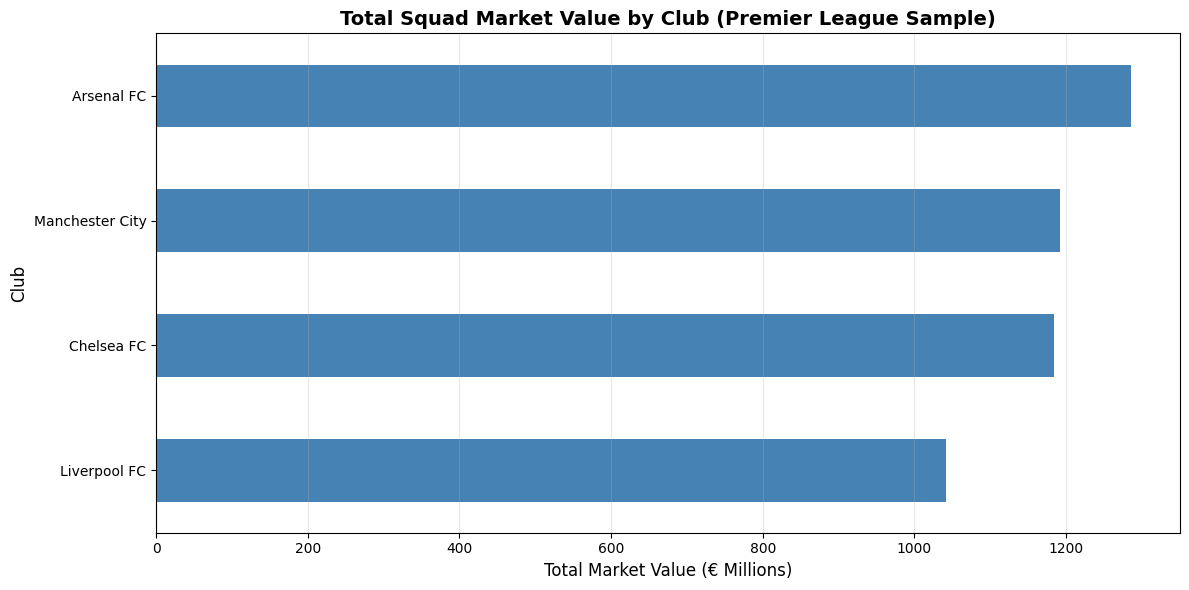


 Visualization complete


In [11]:
# Visualize market values by club
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

# Create results directory
RESULTS_DIR = Path('../results/analysis')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 6))

club_values = df_premier_league.groupby('club')['market_value_millions'].sum().sort_values(ascending=True)

club_values.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Total Market Value (€ Millions)', fontsize=12)
ax.set_ylabel('Club', fontsize=12)
ax.set_title('Total Squad Market Value by Club (Premier League Sample)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()

# Save figure
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
fig_path = RESULTS_DIR / f'premier_league_club_values_{timestamp}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Saved figure: {fig_path}")

plt.show()

print(f"\n Visualization complete")

In [14]:
# Check ALL Transfermarkt generated files
import os
from pathlib import Path

transfermarkt_root = Path('../data/transfermarkt')
transfermarkt_root.mkdir(parents=True, exist_ok=True)

print(" Transfermarkt Generated Files:")

# Search recursively for ALL CSV files
csv_files = list(transfermarkt_root.rglob('*.csv'))
print(f"\n CSV Files ({len(csv_files)}):")
if csv_files:
    for f in sorted(csv_files, key=lambda x: x.stat().st_mtime, reverse=True)[:5]:
        size_mb = f.stat().st_size / (1024 * 1024)
        rel_path = f.relative_to(transfermarkt_root)
        print(f" {rel_path} ({size_mb:.2f} MB)")
else:
    print(" No CSV files yet - run the full scrape (cell 67)")

# Search for JSON files
json_files = list(transfermarkt_root.rglob('*.json'))
print(f"\n JSON Files ({len(json_files)}):")
if json_files:
    for f in sorted(json_files, key=lambda x: x.stat().st_mtime, reverse=True)[:5]:
        size_kb = f.stat().st_size / 1024
        rel_path = f.relative_to(transfermarkt_root)
        print(f"{rel_path} ({size_kb:.2f} KB)")
else:
    print("No JSON files yet - run the full scrape (cell 67)")

# Show Excel files if any
excel_files = list(transfermarkt_root.rglob('*.xlsx'))
if excel_files:
    print(f"\nExcel Files ({len(excel_files)}):")
    for f in sorted(excel_files, key=lambda x: x.stat().st_mtime, reverse=True)[:3]:
        size_mb = f.stat().st_size / (1024 * 1024)
        rel_path = f.relative_to(transfermarkt_root)
        print(f"  • {rel_path} ({size_mb:.2f} MB)")

print(" NOTE: Files are automatically saved when running scrape_all_leagues()")

 Transfermarkt Generated Files:

 CSV Files (0):
 No CSV files yet - run the full scrape (cell 67)

 JSON Files (0):
No JSON files yet - run the full scrape (cell 67)
 NOTE: Files are automatically saved when running scrape_all_leagues()


In [ ]:
# Reinitialize scraper (to pick up the code changes)
import importlib
import sys
sys.path.insert(0, '../script')

import data_collection.transfermarkt_bs4_scraper
importlib.reload(data_collection.transfermarkt_bs4_scraper)
from data_collection.transfermarkt_bs4_scraper import TransfermarktBS4Scraper

# Initialize with fresh scraper (no club limit now!)
scraper_full = TransfermarktBS4Scraper(
    data_dir="../data/transfermarkt",
    delay=1.5  # Respectful rate limiting
)

print("Full scraper initialized (no club limit)")
print(f"Will scrape ALL clubs from each league")
print(f"Rate limiting: {scraper_full.delay}s between requests")

2025-12-30 10:21:29.918 | INFO     | data_collection.transfermarkt_bs4_scraper:__init__:54 - Initialized Transfermarkt BS4 scraper


Full scraper initialized (no club limit)
Will scrape ALL clubs from each league
Rate limiting: 1.5s between requests


In [ ]:
# Scrape ALL 5 leagues
from datetime import datetime
import time

print("COMPREHENSIVE TRANSFERMARKT SCRAPE - ALL TOP 5 LEAGUES")
print(f"\nStart time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
start_time = time.time()

# Scrape all 5 leagues
all_leagues = ['Premier League', 'La Liga', 'Bundesliga', 'Serie A', 'Ligue 1']
df_all_leagues = scraper_full.scrape_all_leagues(leagues=all_leagues)

# Remove duplicates - keep rows with actual data (non-zero market value and non-empty age)
print(f"\n Before deduplication: {len(df_all_leagues):,} rows")
df_all_leagues = df_all_leagues.sort_values('market_value_millions', ascending=False).drop_duplicates(
    subset=['player_id', 'club'], keep='first'
)
print(f" After deduplication: {len(df_all_leagues):,} rows")

elapsed_time = time.time() - start_time
minutes = int(elapsed_time // 60)
seconds = int(elapsed_time % 60)

print("\n SCRAPING COMPLETE")
print(f"Duration: {minutes}m {seconds}s")
print(f"Total players: {len(df_all_leagues):,}")
print(f"Total clubs: {df_all_leagues['club'].nunique()}")
print(f"Leagues covered: {df_all_leagues['league'].nunique()}")
print(f"Total market value: €{df_all_leagues['market_value_millions'].sum():,.1f}M")

2025-12-30 10:21:34.414 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_all_leagues:339 - ======================================================================
2025-12-30 10:21:34.415 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_all_leagues:340 - STARTING TRANSFERMARKT BS4 SCRAPING
2025-12-30 10:21:34.416 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_all_leagues:341 - ======================================================================
2025-12-30 10:21:34.417 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_all_leagues:344 - 
[1/5] Scraping Premier League...
2025-12-30 10:21:34.418 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_league_players:131 - Scraping players from Premier League...


COMPREHENSIVE TRANSFERMARKT SCRAPE - ALL TOP 5 LEAGUES

Start time: 2025-12-30 10:21:34


2025-12-30 10:21:37.384 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_league_players:143 - Found 55 clubs in Premier League
2025-12-30 10:21:37.385 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_league_players:149 -   [1/55] Scraping Arsenal FC...
2025-12-30 10:21:40.482 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_league_players:213 -     Scraped 50 players from Arsenal FC
2025-12-30 10:21:40.483 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_league_players:149 -   [2/55] Scraping Manchester City...
2025-12-30 10:21:43.547 | DEBUG    | data_collection.transfermarkt_bs4_scraper:_clean_value:114 - Could not parse value: 500k
2025-12-30 10:21:43.576 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_league_players:213 -     Scraped 52 players from Manchester City
2025-12-30 10:21:43.578 | INFO     | data_collection.transfermarkt_bs4_scraper:scrape_league_players:149 -   [3/55] Scraping Chelsea FC...
2025-12-30 10:2


 Before deduplication: 5,234 rows
 After deduplication: 2,617 rows

 SCRAPING COMPLETE
Duration: 11m 23s
Total players: 2,617
Total clubs: 96
Leagues covered: 5
Total market value: €31,743.8M


In [5]:
# Generate clean RAG JSON from cleaned CSV
import json
from pathlib import Path

print(" Generating clean RAG JSON...")

# Load cleaned data
csv_path = Path('../data/transfermarkt/all_leagues_market_values_complete.csv')
df_clean = pd.read_csv(csv_path)

# Create RAG-friendly format
rag_data = []
for _, row in df_clean.iterrows():
    rag_entry = {
        'type': 'player_market_value',
        'player': row['player_name'],
        'club': row['club'],
        'league': row['league'],
        'position': row['position'],
        'age': row['age'],
        'nationality': row['nationality'],
        'market_value': row['market_value_millions'],
        'player_url': row['player_url'],
        'scraped_date': row['scraped_date'],
        'text': f"{row['player_name']} ({row['club']}, {row['league']}) - {row['position']} - Market Value: €{row['market_value_millions']}M - Age: {row['age']} - {row['nationality']}"
    }
    rag_data.append(rag_entry)

# Save clean JSON
output_file = Path('../data/transfermarkt/player_market_values_rag_clean.json')
with open(output_file, 'w') as f:
    json.dump(rag_data, f, indent=2)

print(f" Created clean RAG JSON: {output_file.name}")
print(f" Total players: {len(rag_data):,}")
print(f" File size: {output_file.stat().st_size / 1024**2:.2f} MB")

 Generating clean RAG JSON...
 Created clean RAG JSON: player_market_values_rag_clean.json
 Total players: 2,617
 File size: 1.29 MB


In [19]:
# Comprehensive data analysis
print(" COMPREHENSIVE DATA ANALYSIS")

# League breakdown
print("\n1.LEAGUE BREAKDOWN:")
league_summary = df_all_leagues.groupby('league').agg({
    'player_name': 'count',
    'club': 'nunique',
    'market_value_millions': 'sum'
}).round(1)
league_summary.columns = ['Players', 'Clubs', 'Total Value (€M)']
print(league_summary.to_string())

# Top clubs by squad value
print("\n2. TOP 20 CLUBS BY TOTAL SQUAD VALUE:")
top_clubs = df_all_leagues.groupby(['club', 'league'])['market_value_millions'].sum().sort_values(ascending=False).head(20)
for idx, ((club, league), value) in enumerate(top_clubs.items(), 1):
    print(f"{idx:2d}. {club:<30} ({league:<20}) €{value:>8.1f}M")

# Most valuable players overall
print("\n3. TOP 20 MOST VALUABLE PLAYERS (ALL LEAGUES):")
top_players_all = df_all_leagues.nlargest(20, 'market_value_millions')
for idx, (_, row) in enumerate(top_players_all.iterrows(), 1):
    print(f"{idx:2d}. {row['player_name']:<25} ({row['club']:<25}) €{row['market_value_millions']:>6.1f}M")

 COMPREHENSIVE DATA ANALYSIS

1.LEAGUE BREAKDOWN:
                Players  Clubs  Total Value (€M)
league                                          
Bundesliga         1046     18            4769.9
La Liga            1002     20            5420.3
Ligue 1             956     18            3755.6
Premier League     1086     20           12512.9
Serie A            1144     20            5287.1

2. TOP 20 CLUBS BY TOTAL SQUAD VALUE:
 1. Real Madrid                    (La Liga             ) €  1377.0M
 2. Arsenal FC                     (Premier League      ) €  1286.0M
 3. Manchester City                (Premier League      ) €  1192.0M
 4. Paris Saint-Germain            (Ligue 1             ) €  1188.0M
 5. Chelsea FC                     (Premier League      ) €  1183.5M
 6. FC Barcelona                   (La Liga             ) €  1116.0M
 7. Liverpool FC                   (Premier League      ) €  1042.0M
 8. Bayern Munich                  (Bundesliga          ) €   980.0M
 9. Tottenham Ho

In [21]:
# Position and nationality analysis
print("\n4. POSITION DISTRIBUTION (ALL LEAGUES):")
position_dist = df_all_leagues['position'].value_counts().head(15)
for pos, count in position_dist.items():
    pct = count / len(df_all_leagues) * 100
    
    print(f"{pos:<25} {count:4d} ({pct:4.1f}%) ")

print("\n5. TOP NATIONALITIES (ALL LEAGUES):")
nationality_dist = df_all_leagues['nationality'].value_counts().head(20)
for nat, count in nationality_dist.items():
    print(f"{nat:<25} {count:4d} players")

print("\n6. AGE DISTRIBUTION:")
# Extract age from strings like "15/09/1995 (30)"
df_all_leagues['age_numeric'] = df_all_leagues['age'].str.extract(r'\((\d+)\)')[0].astype(float)
age_counts = df_all_leagues['age_numeric'].value_counts().sort_index()
print(f"Average age: {df_all_leagues['age_numeric'].mean():.1f} years")
print(f"Youngest: {int(df_all_leagues['age_numeric'].min())}")
print(f"Oldest: {int(df_all_leagues['age_numeric'].max())}")


4. POSITION DISTRIBUTION (ALL LEAGUES):
Unknown                   2617 (50.0%) 
Centre-Back                492 ( 9.4%) 
Centre-Forward             325 ( 6.2%) 
Central Midfield           322 ( 6.2%) 
Goalkeeper                 302 ( 5.8%) 
Right-Back                 213 ( 4.1%) 
Defensive Midfield         199 ( 3.8%) 
Left-Back                  196 ( 3.7%) 
Right Winger               178 ( 3.4%) 
Left Winger                172 ( 3.3%) 
Attacking Midfield         170 ( 3.2%) 
Right Midfield              17 ( 0.3%) 
Second Striker              16 ( 0.3%) 
Left Midfield               15 ( 0.3%) 

5. TOP NATIONALITIES (ALL LEAGUES):
Unknown                   2617 players
Spain                      346 players
France                     299 players
Germany                    251 players
Italy                      209 players
England                    189 players
Brazil                      78 players
Argentina                   73 players
Netherlands                 72 players
Portugal   

 Saved comprehensive figure: ..\results\analysis\all_leagues_comprehensive_analysis_20251230_092425.png


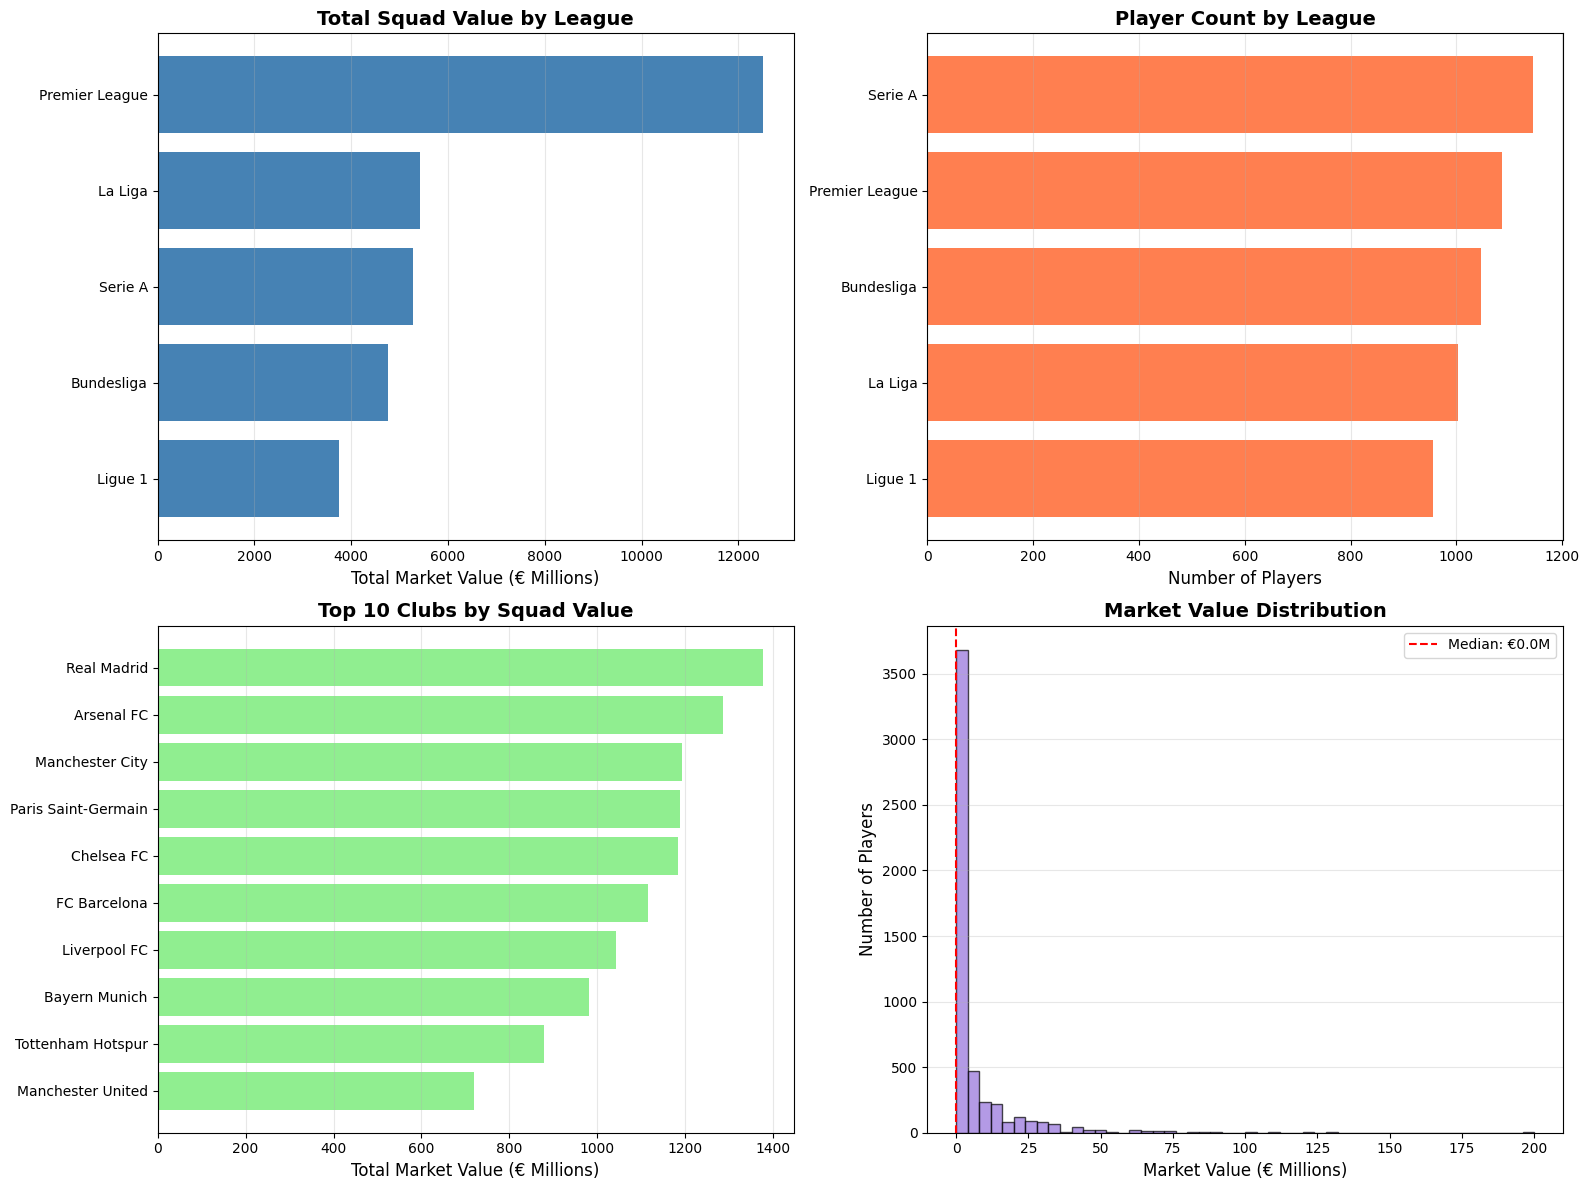


 Visualizations complete!


In [22]:
# Visual comparison across leagues
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

# Create results directory
RESULTS_DIR = Path('../results/analysis')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Total squad value by league
league_values = df_all_leagues.groupby('league')['market_value_millions'].sum().sort_values(ascending=True)
axes[0, 0].barh(league_values.index, league_values.values, color='steelblue')
axes[0, 0].set_xlabel('Total Market Value (€ Millions)', fontsize=12)
axes[0, 0].set_title('Total Squad Value by League', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Plot 2: Number of players by league
league_counts = df_all_leagues.groupby('league').size().sort_values(ascending=True)
axes[0, 1].barh(league_counts.index, league_counts.values, color='coral')
axes[0, 1].set_xlabel('Number of Players', fontsize=12)
axes[0, 1].set_title('Player Count by League', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# Plot 3: Top 10 clubs by total value
top_10_clubs = df_all_leagues.groupby('club')['market_value_millions'].sum().nlargest(10).sort_values(ascending=True)
axes[1, 0].barh(top_10_clubs.index, top_10_clubs.values, color='lightgreen')
axes[1, 0].set_xlabel('Total Market Value (€ Millions)', fontsize=12)
axes[1, 0].set_title('Top 10 Clubs by Squad Value', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# Plot 4: Market value distribution (histogram)
axes[1, 1].hist(df_all_leagues['market_value_millions'], bins=50, color='mediumpurple', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Market Value (€ Millions)', fontsize=12)
axes[1, 1].set_ylabel('Number of Players', fontsize=12)
axes[1, 1].set_title('Market Value Distribution', fontsize=14, fontweight='bold')
axes[1, 1].axvline(df_all_leagues['market_value_millions'].median(), color='red', linestyle='--', label=f"Median: €{df_all_leagues['market_value_millions'].median():.1f}M")
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()

# Save figure
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
fig_path = RESULTS_DIR / f'all_leagues_comprehensive_analysis_{timestamp}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f" Saved comprehensive figure: {fig_path}")

plt.show()

print("\n Visualizations complete!")

In [25]:
# Save the comprehensive dataset
from pathlib import Path

# Save to processed data directory
output_dir = Path('../data/transfermarkt')
output_dir.mkdir(parents=True, exist_ok=True)

# Save CSV
csv_file = output_dir / 'all_leagues_market_values_complete.csv'
df_all_leagues.to_csv(csv_file, index=False)
print(f"Saved CSV: {csv_file}")
print(f"  Size: {csv_file.stat().st_size / 1024**2:.2f} MB")

# Save Excel for easy viewing (if openpyxl is available)
try:
    excel_file = output_dir / 'all_leagues_market_values_complete.xlsx'
    df_all_leagues.to_excel(excel_file, index=False, sheet_name='All Players')
    print(f" Saved Excel: {excel_file}")
    print(f"  Size: {excel_file.stat().st_size / 1024**2:.2f} MB")
except ImportError:
    print("  Skipped Excel export")

# Save summary by league
summary_by_league = df_all_leagues.groupby('league').agg({
    'player_name': 'count',
    'club': 'nunique',
    'market_value_millions': ['sum', 'mean', 'median', 'max']
}).round(2)
summary_by_league.to_csv(output_dir / 'league_summary.csv')
print(f" Saved league summary")

# Save summary by club
summary_by_club = df_all_leagues.groupby(['league', 'club']).agg({
    'player_name': 'count',
    'market_value_millions': ['sum', 'mean', 'max']
}).round(2).sort_values(('market_value_millions', 'sum'), ascending=False)
summary_by_club.to_csv(output_dir / 'club_summary.csv')
print(f" Saved club summary")

print(f"\n ALL DATA SAVED TO: {output_dir}")

Saved CSV: ..\data\transfermarkt\all_leagues_market_values_complete.csv
  Size: 0.82 MB
  Skipped Excel export
 Saved league summary
 Saved club summary

 ALL DATA SAVED TO: ..\data\transfermarkt


---
##  FBref Data Analysis & Integration

Now we'll:
1. **Load and analyze FBref player statistics**
2. **Create comprehensive visualizations** (saved to results/analysis)
3. **Merge FBref stats with Transfermarkt market values**
4. **Save final unified dataset** to processed/

This gives us one complete CSV with both performance stats AND market values!

In [6]:
# Load FBref processed data
from pathlib import Path
import pandas as pd

PROCESSED_DATA_DIR = Path('../data/processed')
RESULTS_DIR = Path('../results/analysis')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Load the complete player stats
fbref_file = PROCESSED_DATA_DIR / 'player_stats_complete.csv'

if fbref_file.exists():
    print("Loading FBref player statistics...")
    df_fbref = pd.read_csv(fbref_file)
    
    # Fix season format if needed
    if df_fbref['season'].dtype == 'int64':
        df_fbref['season'] = df_fbref['season'].astype(str)
        df_fbref['season'] = '20' + df_fbref['season'].str[:2] + '-20' + df_fbref['season'].str[2:4]
    
    print(f"Loaded: {len(df_fbref):,} player records")
    print(f"Columns: {len(df_fbref.columns)}")
    print(f"Seasons: {df_fbref['season'].unique()}")
    print(f"Players: {df_fbref['player'].nunique():,}")
    print(f"Teams: {df_fbref['team'].nunique():,}")
    
    # Display sample
    print("\nSample data:")
    display_cols = ['player', 'team', 'season', 'league'] if all(c in df_fbref.columns for c in ['player', 'team', 'season', 'league']) else df_fbref.columns[:6].tolist()
    print(df_fbref[display_cols].head(10))
else:
    print(f" FBref data not found at {fbref_file}")
    print("Please run the FBref scraping cells first (cells 7-29)")

Loading FBref player statistics...
Loaded: 13,888 player records
Columns: 4
Seasons: ['2021-2022' '2022-2023' '2023-2024' '2024-2025' '2025-2026']
Players: 5,440
Teams: 130

Sample data:
                   player     team     season              league
0          Aaron Ramsdale  Arsenal  2021-2022  ENG-Premier League
1  Ainsley Maitland-Niles  Arsenal  2021-2022  ENG-Premier League
2    Albert Sambi Lokonga  Arsenal  2021-2022  ENG-Premier League
3     Alexandre Lacazette  Arsenal  2021-2022  ENG-Premier League
4               Ben White  Arsenal  2021-2022  ENG-Premier League
5              Bernd Leno  Arsenal  2021-2022  ENG-Premier League
6             Bukayo Saka  Arsenal  2021-2022  ENG-Premier League
7          Calum Chambers  Arsenal  2021-2022  ENG-Premier League
8           Cédric Soares  Arsenal  2021-2022  ENG-Premier League
9           Eddie Nketiah  Arsenal  2021-2022  ENG-Premier League


In [7]:
# FBref data analysis - Key statistics
print("FBREF PLAYER STATISTICS ANALYSIS")

# 1. League breakdown
print("\n1. LEAGUE BREAKDOWN:")
league_summary = df_fbref.groupby('league').agg({
    'player': 'count',
    'team': 'nunique'
}).round(1)
league_summary.columns = ['Player Records', 'Teams']
print(league_summary.to_string())

# 2. Season distribution
print("\n2. SEASON DISTRIBUTION:")
season_summary = df_fbref.groupby('season').agg({
    'player': 'count',
    'team': 'nunique'
}).round(1)
season_summary.columns = ['Player Records', 'Teams']
print(season_summary.to_string())

# 3. Top performers (if we have goals/assists columns)
print("\n3. DATA COMPLETENESS:")
# Check which stat columns exist
stat_cols = [col for col in df_fbref.columns if any(x in col.lower() for x in ['goals', 'assists', 'shots', 'passes', 'tackles'])]
print(f"Available stat columns: {len(stat_cols)}")
if len(stat_cols) > 0:
    print(f"Examples: {', '.join(stat_cols[:10])}")

print("\n4. DATA QUALITY:")
print(f"Total records: {len(df_fbref):,}")
print(f"Unique players: {df_fbref['player'].nunique():,}")
print(f"Avg records per player: {len(df_fbref) / df_fbref['player'].nunique():.1f}")
print(f"Missing values: {df_fbref.isnull().sum().sum():,} ({df_fbref.isnull().sum().sum() / df_fbref.size * 100:.2f}%)")

FBREF PLAYER STATISTICS ANALYSIS

1. LEAGUE BREAKDOWN:
                    Player Records  Teams
league                                   
ENG-Premier League            2748     27
ESP-La Liga                   2928     26
FRA-Ligue 1                   2761     25
GER-Bundesliga                2468     25
ITA-Serie A                   2983     27

2. SEASON DISTRIBUTION:
           Player Records  Teams
season                          
2021-2022            2922     98
2022-2023            2889     98
2023-2024            2852     96
2024-2025            2854     96
2025-2026            2371     96

3. DATA COMPLETENESS:
Available stat columns: 0

4. DATA QUALITY:
Total records: 13,888
Unique players: 5,440
Avg records per player: 2.6
Missing values: 0 (0.00%)


C:\Users\Hp\AppData\Local\Temp\ipykernel_24120\1137513980.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  completeness = df_fbref.groupby('league').apply(lambda x: (1 - x.isnull().sum().sum() / x.size) * 100).sort_values(ascending=True)


Saved FBref analysis figure: ..\results\analysis\fbref_analysis_20251230_110502.png


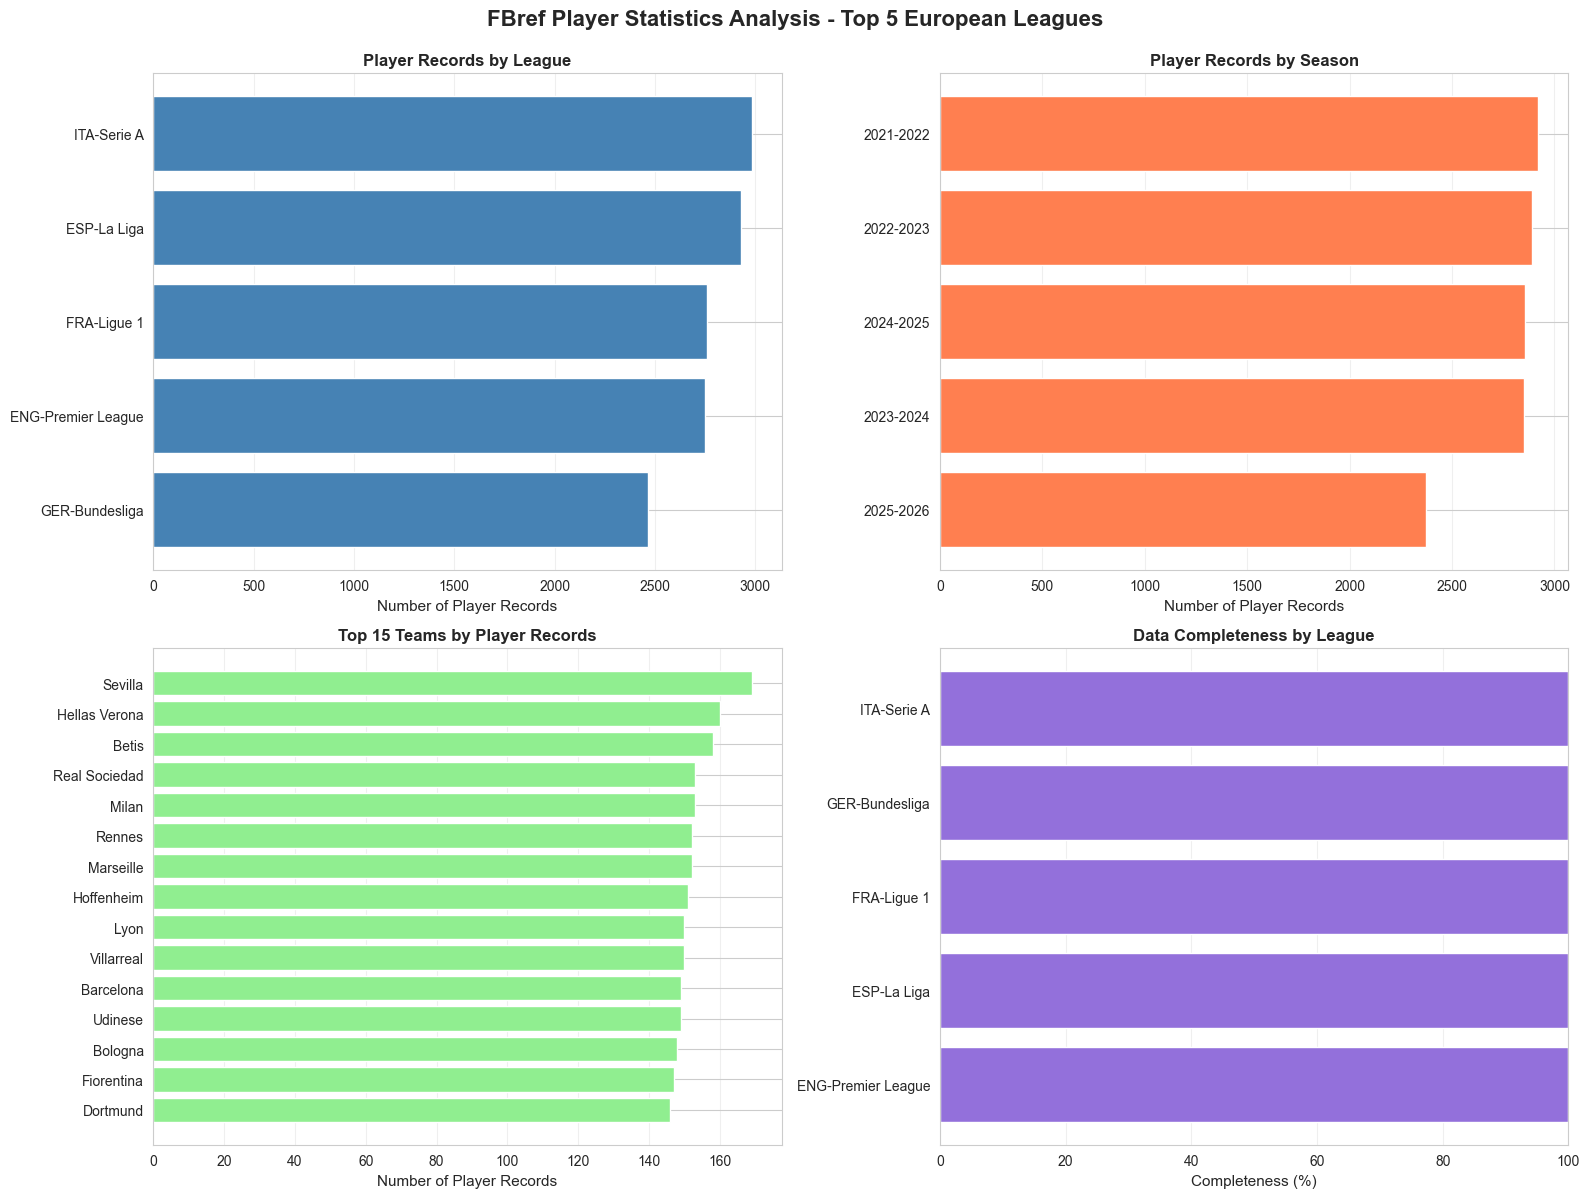

In [8]:
# FBref visualizations (saved to results/analysis)
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('FBref Player Statistics Analysis - Top 5 European Leagues', fontsize=16, fontweight='bold', y=0.995)

# Plot 1: Player records by league
league_counts = df_fbref.groupby('league').size().sort_values(ascending=True)
axes[0, 0].barh(league_counts.index, league_counts.values, color='steelblue')
axes[0, 0].set_xlabel('Number of Player Records', fontsize=11)
axes[0, 0].set_title('Player Records by League', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Plot 2: Records by season
season_counts = df_fbref.groupby('season').size().sort_values(ascending=True)
axes[0, 1].barh(season_counts.index, season_counts.values, color='coral')
axes[0, 1].set_xlabel('Number of Player Records', fontsize=11)
axes[0, 1].set_title('Player Records by Season', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# Plot 3: Top 15 teams by player records
top_teams = df_fbref.groupby('team').size().nlargest(15).sort_values(ascending=True)
axes[1, 0].barh(top_teams.index, top_teams.values, color='lightgreen')
axes[1, 0].set_xlabel('Number of Player Records', fontsize=11)
axes[1, 0].set_title('Top 15 Teams by Player Records', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# Plot 4: Data completeness by league
completeness = df_fbref.groupby('league').apply(lambda x: (1 - x.isnull().sum().sum() / x.size) * 100).sort_values(ascending=True)
axes[1, 1].barh(completeness.index, completeness.values, color='mediumpurple')
axes[1, 1].set_xlabel('Completeness (%)', fontsize=11)
axes[1, 1].set_title('Data Completeness by League', fontsize=12, fontweight='bold')
axes[1, 1].set_xlim(0, 100)
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()

# Save figure
fig_path = RESULTS_DIR / f'fbref_analysis_{timestamp}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Saved FBref analysis figure: {fig_path}")

plt.show()

###  Merge FBref Stats with Transfermarkt Market Values

Now we'll merge:
- **FBref**: Performance stats (goals, assists, passes, etc.)
- **Transfermarkt**: Market values, age, nationality

This creates one comprehensive dataset with both performance and market data!

In [ ]:
# MERGE FBREF PERFORMANCE DATA WITH TRANSFERMARKT MARKET DATA
print("MERGING FBREF + TRANSFERMARKT DATA")

# Step 1: Load or create combined FBref dataframe
print("\n Loading FBref performance data...")
processed_fbref = PROCESSED_DATA_DIR / 'player_stats_complete.csv'
if processed_fbref.exists():
    df_fbref = pd.read_csv(processed_fbref)
    print(f"   Loaded from: {processed_fbref.name}")
    print(f"   Records: {len(df_fbref):,}")
else:
    # Combine from individual dataframes if they exist in memory
    if 'player_standard' in dir() and 'player_shooting' in dir():
        print("   Combining from individual stats dataframes...")
        # Get player and match keys for merging
        merge_keys = ['player', 'team', 'league', 'season']
        df_fbref = player_standard.copy()
        
        # Merge other stats
        for df, name in [(player_shooting, 'shooting'), (player_passing, 'passing'), (player_defense, 'defense'), (player_keeper, 'keeper')]:
            df_fbref = df_fbref.merge(df, on=merge_keys, how='left', suffixes=('', f'_{name}'))
        print(f"   Combined records: {len(df_fbref):,}")
    else:
        raise RuntimeError("No FBref data available - run data collection cells first")

# Step 2: Show seasons available
seasons = df_fbref['season'].unique()
print(f"\n FBref seasons available: {sorted(seasons)}")
print(f"   Total records across all seasons: {len(df_fbref):,}")

# Step 3: Load Transfermarkt data from data/transfermarkt
print("\n Loading Transfermarkt market data...")
transfer_dir = DATA_DIR / 'transfermarkt'
df_tm = pd.DataFrame()

if transfer_dir.exists():
    csv_files = sorted(transfer_dir.glob('*.csv'))
    json_files = sorted(transfer_dir.glob('*.json'))
    parts = []
    
    for f in csv_files:
        try:
            parts.append(pd.read_csv(f))
            print(f" CSV: {f.name} ({len(parts[-1]):,} rows)")
        except Exception as e:
            print(f" CSV {f.name}: {e}")
    
    for f in json_files:
        try:
            parts.append(pd.read_json(f, orient='records'))
            print(f" JSON: {f.name} ({len(parts[-1]):,} rows)")
        except Exception:
            try:
                import json
                with open(f, 'r', encoding='utf-8') as fh:
                    data = json.load(fh)
                parts.append(pd.DataFrame(data))
                print(f" JSON: {f.name} ({len(parts[-1]):,} rows)")
            except Exception as e:
                print(f" JSON {f.name}: {e}")
    
    if parts:
        df_tm = pd.concat(parts, ignore_index=True, sort=False)
        # Remove duplicates based on player_name if column exists
        if 'player_name' in df_tm.columns:
            df_tm = df_tm.drop_duplicates(subset=['player_name'], keep='first')
        print(f"\n   Total unique Transfermarkt records: {len(df_tm):,}")
else:
    print(f"   Transfermarkt folder not found: {transfer_dir}")

if df_tm.empty:
    print("\n No Transfermarkt data available - skipping merge")
else:
    import re
    
    # Step 4: Standardize column names
    print("\n Standardizing columns...")
    df_tm.columns = [str(c).strip() for c in df_tm.columns]
    
    # Auto-detect key columns - prioritize player_name over player_id
    player_col = None
    if 'player_name' in df_tm.columns:
        player_col = 'player_name'
    else:
        player_col = next((c for c in df_tm.columns if any(k in c.lower() for k in ('player', 'name'))), None)
    
    club_col = next((c for c in df_tm.columns if any(k in c.lower() for k in ('club', 'team'))), None)
    value_col = next((c for c in df_tm.columns if any(k in c.lower() for k in ('value', 'market'))), None)
    age_col = next((c for c in df_tm.columns if 'age' in c.lower() and 'numeric' not in c.lower()), None)
    nationality_col = next((c for c in df_tm.columns if 'nation' in c.lower()), None)
    position_col = next((c for c in df_tm.columns if 'pos' in c.lower()), None)
    
    print(f"   Detected columns:")
    print(f"     Player: {player_col}")
    print(f"     Club: {club_col}")
    print(f"     Value: {value_col}")
    print(f"     Age: {age_col}")
    
    # Create standardized columns
    df_tm['player_tm'] = df_tm[player_col].astype(str) if player_col else df_tm.index.astype(str)
    df_tm['club_tm'] = df_tm[club_col].astype(str) if club_col else ''
    df_tm['market_value'] = pd.to_numeric(df_tm[value_col], errors='coerce') if value_col else pd.NA
    df_tm['age_tm'] = pd.to_numeric(df_tm[age_col], errors='coerce') if age_col else pd.NA
    if nationality_col:
        df_tm['nationality_tm'] = df_tm[nationality_col]
    if position_col:
        df_tm['position_tm'] = df_tm[position_col]
    
    # Step 5: Normalize keys for matching
    print("\n[5] Creating normalized matching keys...")
    def normalize_key(s):
        if pd.isna(s):
            return ''
        s = str(s).lower()
        s = re.sub(r"[^a-z0-9]", "", s)
        return s
    
    df_tm['player_key'] = df_tm['player_tm'].apply(normalize_key)
    df_fbref['player_key'] = df_fbref['player'].apply(normalize_key)
    
    print(f"   Sample FBref keys: {df_fbref['player_key'].head(3).tolist()}")
    print(f"   Sample TM keys: {df_tm['player_key'].head(3).tolist()}")
    
    # Step 6: Merge datasets - ALL SEASONS
    print("\n Merging ALL seasons of FBref performance + Transfermarkt market data...")
    keep_cols = ['player_key', 'club_tm', 'market_value', 'age_tm']
    if 'nationality_tm' in df_tm.columns:
        keep_cols.append('nationality_tm')
    if 'position_tm' in df_tm.columns:
        keep_cols.append('position_tm')
    
    df_merged = df_fbref.merge(
        df_tm[keep_cols].drop_duplicates(subset=['player_key']),
        on='player_key',
        how='left'
    )
    
    # Step 7: Report results by season
    matched = df_merged['market_value'].notna().sum()
    total = len(df_merged)
    match_pct = (matched / total * 100) if total > 0 else 0
    
    print(f"MERGE RESULTS:")
    print(f"{'='*70}")
    print(f"Total FBref records (all seasons): {total:,}")
    print(f"Matched with Transfermarkt: {matched:,} ({match_pct:.1f}%)")
    print(f"Unmatched: {total - matched:,}")
    
    if matched > 0:
        avg_value = df_merged[df_merged['market_value'].notna()]['market_value'].mean()
        print(f"Average market value (matched): €{avg_value:.1f}M")
    
    # Show breakdown by season
    print(f"\nBreakdown by season:")
    for season in sorted(df_merged['season'].unique()):
        season_data = df_merged[df_merged['season'] == season]
        season_matched = season_data['market_value'].notna().sum()
        season_total = len(season_data)
        season_pct = (season_matched / season_total * 100) if season_total > 0 else 0
        print(f"  {season}: {season_total:,} records, {season_matched:,} matched ({season_pct:.1f}%)")
    
    # Step 8: Save merged dataset to data/processed
    PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
    out_file = PROCESSED_DATA_DIR / 'fbref_transfermarkt_merged_all_seasons.csv'
    df_merged.to_csv(out_file, index=False)
    print(f"\n Saved: {out_file}")
    print(f"  Columns: {len(df_merged.columns)}")
    print(f"  Rows: {len(df_merged):,}")
    print(f"  Seasons: {len(df_merged['season'].unique())}")
    
    # Make available for downstream cells
    df_fbref_merged = df_merged
    print("\n Merged dataframe available as 'df_fbref_merged'")

MERGING FBREF + TRANSFERMARKT DATA

 Loading FBref performance data...
   Loaded from: player_stats_complete.csv
   Records: 13,888

 FBref seasons available: ['2021-2022', '2022-2023', '2023-2024', '2024-2025', '2025-2026']
   Total records across all seasons: 13,888

 Loading Transfermarkt market data...
 CSV: all_leagues_market_values_complete.csv (2,617 rows)
 CSV: club_summary.csv (98 rows)
 CSV: league_summary.csv (7 rows)
 JSON: player_market_values_rag_clean.json (2,617 rows)

   Total unique Transfermarkt records: 2,633

 Standardizing columns...
   Detected columns:
     Player: player_name
     Club: club
     Value: market_value_millions
     Age: age

[5] Creating normalized matching keys...
   Sample FBref keys: ['aaronramsdale', 'ainsleymaitlandniles', 'albertsambilokonga']
   Sample TM keys: ['lamineyamal', 'erlinghaaland', 'kylianmbapp']

 Merging ALL seasons of FBref performance + Transfermarkt market data...
MERGE RESULTS:
Total FBref records (all seasons): 13,888
Ma

### COMPREHENSIVE DATA MERGE - All Stats Combined

Merging:
- Standard stats (games, goals, assists, minutes)
- Shooting stats (shots, xG, shot accuracy)
- Passing stats (passes, key passes, pass completion)
- Defense stats (tackles, interceptions, blocks)

In [22]:
# COMPREHENSIVE DATA MERGE - ALL STATS + TRANSFERMARKT (Using In-Memory Data)
print("CREATING UNIFIED DATASET: ALL FBREF STATS + TRANSFERMARKT")

# Step 1: Use already-loaded FBref dataframes from memory
print("\n Using in-memory FBref stat dataframes...")
print(f"   STANDARD: {len(player_standard):,} records, {len(player_standard.columns)} columns")
print(f"   SHOOTING: {len(player_shooting):,} records, {len(player_shooting.columns)} columns")
print(f"   PASSING: {len(player_passing):,} records, {len(player_passing.columns)} columns")
print(f"   DEFENSE: {len(player_defense):,} records, {len(player_defense.columns)} columns")
print(f"   GOALKEEPING: {len(player_keeper):,} records, {len(player_keeper.columns)} columns")

# Step 2: Flatten column names and merge
print("\n Flattening multi-level columns and merging...")

def flatten_and_rename(df, stat_type):
    """Flatten multi-level columns and add stat type suffix"""
    df_copy = df.copy()
    
    # Handle the case where season is in both index and columns
    # First, drop season from index, keeping only league, team, player
    index_to_keep = [name for name in df_copy.index.names if name != 'season']
    if index_to_keep:
        df_copy = df_copy.droplevel('season')  # Drop season from index
        df_copy = df_copy.reset_index()  # Now reset to get league, team, player as columns
    else:
        df_copy = df_copy.reset_index(drop=True)
    
    # Flatten columns: keep single-level cols as is, join multi-level with underscore
    new_cols = []
    merge_keys = ['nation', 'pos', 'age', 'born', 'season', 'player', 'squad', 'comp', 'league', 'team']
    
    for col in df_copy.columns:
        if isinstance(col, tuple):
            # Join tuple elements
            flat_name = '_'.join([str(x) for x in col if x])
            if col[0] in merge_keys:
                new_cols.append(col[0])
            else:
                new_cols.append(f"{flat_name}_{stat_type}")
        else:
            # Single-level column (from reset_index)
            if col in merge_keys:
                new_cols.append(col)
            else:
                new_cols.append(f"{col}_{stat_type}")
    df_copy.columns = new_cols
    return df_copy

# Flatten all dataframes
standard_flat = flatten_and_rename(player_standard, 'std')
shooting_flat = flatten_and_rename(player_shooting, 'shoot')
passing_flat = flatten_and_rename(player_passing, 'pass')
defense_flat = flatten_and_rename(player_defense, 'def')
keeper_flat = flatten_and_rename(player_keeper, 'gk')

print(" Flattened all column names")

# Step 3: Merge all stats together
print("\n Merging all FBref stats...")
# Use more merge keys for accurate matching
merge_keys_flat = ['player', 'nation', 'pos', 'age', 'born', 'season', 'squad', 'comp']
# Only use keys that exist in all dataframes
merge_keys_flat = [k for k in merge_keys_flat if k in standard_flat.columns and k in shooting_flat.columns and k in passing_flat.columns and k in defense_flat.columns]
print(f"  Merge keys: {merge_keys_flat}")

df_fbref_complete = standard_flat.copy()
print(f"  Starting with STANDARD: {len(df_fbref_complete):,} records, {len(df_fbref_complete.columns)} cols")

# Merge shooting
print(f"  Merging SHOOTING...")
before = len(df_fbref_complete.columns)
df_fbref_complete = df_fbref_complete.merge(shooting_flat, on=merge_keys_flat, how='left', suffixes=('', '_dup'))
df_fbref_complete = df_fbref_complete[[c for c in df_fbref_complete.columns if not c.endswith('_dup')]]
print(f"    Added {len(df_fbref_complete.columns) - before} columns (now {len(df_fbref_complete.columns)} total)")

# Merge passing
print(f"   Merging PASSING...")
before = len(df_fbref_complete.columns)
df_fbref_complete = df_fbref_complete.merge(passing_flat, on=merge_keys_flat, how='left', suffixes=('', '_dup'))
df_fbref_complete = df_fbref_complete[[c for c in df_fbref_complete.columns if not c.endswith('_dup')]]
print(f"  Added {len(df_fbref_complete.columns) - before} columns (now {len(df_fbref_complete.columns)} total)")

# Merge defense
print(f"  Merging DEFENSE...")
before = len(df_fbref_complete.columns)
df_fbref_complete = df_fbref_complete.merge(defense_flat, on=merge_keys_flat, how='left', suffixes=('', '_dup'))
df_fbref_complete = df_fbref_complete[[c for c in df_fbref_complete.columns if not c.endswith('_dup')]]
print(f"    Added {len(df_fbref_complete.columns) - before} columns (now {len(df_fbref_complete.columns)} total)")

# Merge goalkeeping
print(f"  Merging GOALKEEPING...")
before = len(df_fbref_complete.columns)
df_fbref_complete = df_fbref_complete.merge(keeper_flat, on=merge_keys_flat, how='left', suffixes=('', '_dup'))
df_fbref_complete = df_fbref_complete[[c for c in df_fbref_complete.columns if not c.endswith('_dup')]]
gk_cols = [c for c in df_fbref_complete.columns if '_gk' in c]
gk_data_count = df_fbref_complete[gk_cols[0]].notna().sum() if gk_cols else 0
print(f"    Added {len(df_fbref_complete.columns) - before} columns (now {len(df_fbref_complete.columns)} total)")
print(f"    Goalkeepers with GK stats: {gk_data_count:,}")

print(f"\n   FBref merge complete: {len(df_fbref_complete):,} records, {len(df_fbref_complete.columns)} columns")
print(f"   Includes: Standard + Shooting + Passing + Defense + Goalkeeping stats")

# Step 3: Load Transfermarkt data
print("\n Loading Transfermarkt market data...")
transfer_dir = DATA_DIR / 'transfermarkt'
df_tm = pd.DataFrame()

if transfer_dir.exists():
    csv_files = [f for f in transfer_dir.glob('*.csv') if 'summary' not in f.name.lower()]
    json_files = sorted(transfer_dir.glob('*.json'))
    parts = []
    
    for f in csv_files:
        try:
            parts.append(pd.read_csv(f))
            print(f"   {f.name}: {len(parts[-1]):,} rows")
        except Exception as e:
            print(f"  {f.name}: {e}")
    
    for f in json_files:
        try:
            parts.append(pd.read_json(f, orient='records'))
            print(f"  {f.name}: {len(parts[-1]):,} rows")
        except Exception as e:
            print(f"  {f.name}: {e}")
    
    if parts:
        df_tm = pd.concat(parts, ignore_index=True, sort=False)
        if 'player_name' in df_tm.columns:
            df_tm = df_tm.drop_duplicates(subset=['player_name'], keep='first')
        print(f"\n  Total unique players: {len(df_tm):,}")

# Step 4: Merge FBref + Transfermarkt
if not df_tm.empty and not df_fbref_complete.empty:
    print("\n Merging FBref + Transfermarkt...")
    import re
    
    def normalize_key(s):
        if pd.isna(s):
            return ''
        return re.sub(r"[^a-z0-9]", "", str(s).lower())
    
    # Prepare Transfermarkt columns
    player_col = 'player_name' if 'player_name' in df_tm.columns else 'player'
    df_tm['player_key'] = df_tm[player_col].apply(normalize_key)
    df_fbref_complete['player_key'] = df_fbref_complete['player'].apply(normalize_key)
    
    # Select Transfermarkt columns to merge
    tm_cols = ['player_key']
    if 'club' in df_tm.columns:
        df_tm['club_tm'] = df_tm['club']
        tm_cols.append('club_tm')
    if 'market_value_millions' in df_tm.columns:
        df_tm['market_value'] = df_tm['market_value_millions']
        tm_cols.append('market_value')
    if 'age' in df_tm.columns:
        df_tm['age_tm'] = df_tm['age']
        tm_cols.append('age_tm')
    if 'nationality' in df_tm.columns:
        df_tm['nationality_tm'] = df_tm['nationality']
        tm_cols.append('nationality_tm')
    if 'position' in df_tm.columns:
        df_tm['position_tm'] = df_tm['position']
        tm_cols.append('position_tm')
    
    # Merge
    df_unified = df_fbref_complete.merge(
        df_tm[tm_cols].drop_duplicates(subset=['player_key']),
        on='player_key',
        how='left'
    )
    
    matched = df_unified['market_value'].notna().sum()
    total = len(df_unified)
    print(f"   Matched: {matched:,} / {total:,} ({matched/total*100:.1f}%)")
    
else:
    print("\n   Skipping Transfermarkt merge (no data available)")
    df_unified = df_fbref_complete.copy()

# Step 5: Save unified dataset
print("\n Saving unified dataset...")
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Save as CSV
csv_file = PROCESSED_DATA_DIR / 'player_stats_unified_complete.csv'
df_unified.to_csv(csv_file, index=False)
print(f"   CSV: {csv_file.name}")
print(f"    Size: {csv_file.stat().st_size / 1024**2:.2f} MB")

# Save as JSON
json_file = PROCESSED_DATA_DIR / 'player_stats_unified_complete.json'
df_unified.to_json(json_file, orient='records', indent=2)
print(f"  JSON: {json_file.name}")
print(f"    Size: {json_file.stat().st_size / 1024**2:.2f} MB")

# Create metadata
metadata = {
    'created': datetime.now().isoformat(),
    'total_records': len(df_unified),
    'total_columns': len(df_unified.columns),
    'seasons': sorted(df_unified['season'].unique().tolist()),
    'stat_types': ['standard', 'shooting', 'passing', 'defense', 'transfermarkt'],
    'match_rate_transfermarkt': f"{matched/total*100:.1f}%" if 'market_value' in df_unified.columns else 'N/A',
    'key_metrics': {
        'goals': [c for c in df_unified.columns if 'Gls' in c and 'Expected' not in c][:3],
        'assists': [c for c in df_unified.columns if 'Ast' in c][:2],
        'xG': [c for c in df_unified.columns if 'xG' in c][:2],
        'passes': [c for c in df_unified.columns if 'Cmp' in c or 'Att' in c][:3],
        'defense': [c for c in df_unified.columns if any(x in c for x in ['Tkl', 'Int', 'Blocks'])][:3],
        'market_value': ['market_value'] if 'market_value' in df_unified.columns else []
    }
}

metadata_file = PROCESSED_DATA_DIR / 'player_stats_unified_metadata.json'
import json
with open(metadata_file, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"   Metadata: {metadata_file.name}")

print(" UNIFIED DATASET COMPLETE!")
print(f"Records: {len(df_unified):,}")
print(f" Columns: {len(df_unified.columns)}")
print(f"Seasons: {len(df_unified['season'].unique())}")
print(f" CSV + JSON + Metadata included")

# Make available for downstream cells
df_final = df_unified.copy()

CREATING UNIFIED DATASET: ALL FBREF STATS + TRANSFERMARKT

 Using in-memory FBref stat dataframes...
   STANDARD: 13,888 records, 34 columns
   SHOOTING: 13,888 records, 23 columns
   PASSING: 13,888 records, 29 columns
   DEFENSE: 13,888 records, 22 columns
   GOALKEEPING: 988 records, 24 columns

 Flattening multi-level columns and merging...
 Flattened all column names

 Merging all FBref stats...
  Merge keys: ['player', 'nation', 'pos', 'age', 'born', 'season']
  Starting with STANDARD: 13,888 records, 37 cols
  Merging SHOOTING...
    Added 18 columns (now 55 total)
   Merging PASSING...
  Added 24 columns (now 79 total)
  Merging DEFENSE...
    Added 17 columns (now 96 total)
  Merging GOALKEEPING...
    Added 19 columns (now 115 total)
    Goalkeepers with GK stats: 1,231

   FBref merge complete: 19,388 records, 115 columns
   Includes: Standard + Shooting + Passing + Defense + Goalkeeping stats

 Loading Transfermarkt market data...
   all_leagues_market_values_complete.csv: 

## DATA QUALITY ANALYSIS & CLEANING

In [11]:
#  COMPREHENSIVE DATA QUALITY ANALYSIS
print(" DATA QUALITY ANALYSIS")

# Load the unified dataset from CSV
unified_csv = PROCESSED_DATA_DIR / 'player_stats_unified_complete.csv'
print(f"\n Loading unified data from: {unified_csv.name}")
df_analysis = pd.read_csv(unified_csv)

print(f"\n DATASET OVERVIEW:")
print(f"   Total Records: {len(df_analysis):,}")
print(f"   Total Columns: {len(df_analysis.columns)}")
print(f"   Memory Usage: {df_analysis.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 1. DUPLICATE COLUMNS DETECTION
print(" CHECKING FOR DUPLICATE COLUMNS...")

# Find columns with exact same name
col_counts = pd.Series(df_analysis.columns).value_counts()
duplicate_col_names = col_counts[col_counts > 1]

if len(duplicate_col_names) > 0:
    print(f"\n  Found {len(duplicate_col_names)} duplicate column names:")
    for col_name, count in duplicate_col_names.items():
        print(f"   '{col_name}' appears {count} times")
else:
    print("No duplicate column names found")

# Find columns with identical data (same content, different names)
print("\n Checking for columns with identical data...")
duplicate_data_cols = []
checked_cols = set()

for i, col1 in enumerate(df_analysis.columns):
    if col1 in checked_cols:
        continue
    for col2 in df_analysis.columns[i+1:]:
        if col2 in checked_cols:
            continue
        # Compare non-null values only
        mask = df_analysis[col1].notna() & df_analysis[col2].notna()
        if mask.sum() > 100:  # Need at least 100 overlapping values
            if df_analysis.loc[mask, col1].equals(df_analysis.loc[mask, col2]):
                duplicate_data_cols.append((col1, col2))
                checked_cols.add(col2)

if len(duplicate_data_cols) > 0:
    print(f"\n Found {len(duplicate_data_cols)} pairs of columns with identical data:")
    for col1, col2 in duplicate_data_cols[:10]:  # Show first 10
        print(f"   '{col1}' ≡ '{col2}'")
    if len(duplicate_data_cols) > 10:
        print(f"   ... and {len(duplicate_data_cols) - 10} more pairs")
else:
    print(" No columns with identical data found")

# 2. IRRELEVANT/EMPTY COLUMNS
print(" CHECKING FOR IRRELEVANT/EMPTY COLUMNS...")

# Find columns that are mostly null
null_threshold = 0.95  # 95% null
high_null_cols = []
for col in df_analysis.columns:
    null_pct = df_analysis[col].isna().sum() / len(df_analysis)
    if null_pct > null_threshold:
        high_null_cols.append((col, null_pct))

if len(high_null_cols) > 0:
    print(f"\n  Found {len(high_null_cols)} columns with >{null_threshold*100}% null values:")
    for col, pct in sorted(high_null_cols, key=lambda x: x[1], reverse=True)[:15]:
        print(f"   '{col}': {pct*100:.1f}% null")
    if len(high_null_cols) > 15:
        print(f"   ... and {len(high_null_cols) - 15} more")
else:
    print(f" No columns with >{null_threshold*100}% null values")

# Find columns with single unique value (constant columns)
constant_cols = []
for col in df_analysis.columns:
    if df_analysis[col].nunique(dropna=False) == 1:
        constant_cols.append((col, df_analysis[col].iloc[0]))

if len(constant_cols) > 0:
    print(f"\n  Found {len(constant_cols)} constant columns (single value):")
    for col, val in constant_cols[:10]:
        print(f"   '{col}': always = {val}")
    if len(constant_cols) > 10:
        print(f"   ... and {len(constant_cols) - 10} more")
else:
    print(" No constant columns found")

# 3. DUPLICATE ROW
print(" CHECKING FOR DUPLICATE ROWS...")

# Check exact duplicates
exact_duplicates = df_analysis.duplicated().sum()
print(f"\n Exact duplicate rows: {exact_duplicates:,}")

# Check duplicates based on key columns (player + season + league)
key_cols = ['player', 'season', 'league', 'team'] if all(c in df_analysis.columns for c in ['player', 'season', 'league', 'team']) else ['player', 'season']
if key_cols:
    key_duplicates = df_analysis.duplicated(subset=key_cols, keep=False)
    duplicate_groups = df_analysis[key_duplicates].groupby(key_cols).size()
    
    print(f" Duplicate players (same {', '.join(key_cols)}): {duplicate_groups.sum():,} rows in {len(duplicate_groups)} groups")
    
    if len(duplicate_groups) > 0:
        print(f"\n  Top 10 duplicate player entries:")
        for keys, count in duplicate_groups.nlargest(10).items():
            if isinstance(keys, tuple):
                key_str = " | ".join([f"{k}:{v}" for k, v in zip(key_cols, keys)])
            else:
                key_str = f"{key_cols[0]}:{keys}"
            print(f"   {key_str} → {count} records")

# 4. DATA TYPE ANALYSIS
print(" COLUMN DATA TYPES SUMMARY:")

dtype_counts = df_analysis.dtypes.value_counts()
print("\nData type distribution:")
for dtype, count in dtype_counts.items():
    print(f"   {dtype}: {count} columns")

# Check for columns that should be numeric but aren't
print("\n Checking for numeric columns stored as objects...")
potential_numeric = []
for col in df_analysis.select_dtypes(include=['object']).columns:
    # Try to convert a sample
    sample = df_analysis[col].dropna().head(100)
    if len(sample) > 0:
        try:
            pd.to_numeric(sample)
            potential_numeric.append(col)
        except:
            pass

if len(potential_numeric) > 0:
    print(f" Found {len(potential_numeric)} columns that could be numeric:")
    for col in potential_numeric[:10]:
        print(f"   '{col}'")
    if len(potential_numeric) > 10:
        print(f"   ... and {len(potential_numeric) - 10} more")
else:
    print("All numeric columns properly typed")

print(" DATA QUALITY ANALYSIS COMPLETE")

 DATA QUALITY ANALYSIS

 Loading unified data from: player_stats_unified_complete.csv


C:\Users\Hp\AppData\Local\Temp\ipykernel_14908\2868457284.py:7: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_analysis = pd.read_csv(unified_csv)



 DATASET OVERVIEW:
   Total Records: 19,388
   Total Columns: 121
   Memory Usage: 29.54 MB
 CHECKING FOR DUPLICATE COLUMNS...
No duplicate column names found

 Checking for columns with identical data...
 No columns with identical data found
 CHECKING FOR IRRELEVANT/EMPTY COLUMNS...

  Found 1 columns with >95.0% null values:
   'Penalty Kicks_Save%_gk': 95.7% null
 No constant columns found
 CHECKING FOR DUPLICATE ROWS...

 Exact duplicate rows: 0
 Duplicate players (same player, season, league, team): 6,256 rows in 756 groups

  Top 10 duplicate player entries:
   player:Benjamin Lecomte | season:2022-2023 | league:ESP-La Liga | team:Espanyol → 16 records
   player:Benjamin Lecomte | season:2022-2023 | league:FRA-Ligue 1 | team:Montpellier → 16 records
   player:Brice Samba | season:2024-2025 | league:FRA-Ligue 1 | team:Lens → 16 records
   player:Brice Samba | season:2024-2025 | league:FRA-Ligue 1 | team:Rennes → 16 records
   player:Elia Caprile | season:2024-2025 | league:ITA-Se

In [3]:
#  DATA CLEANING & OPTIMIZATION
print(" LOADING & CLEANING UNIFIED DATASET")

# Load the unified dataset from CSV
unified_csv = PROCESSED_DATA_DIR / 'player_stats_unified_complete.csv'
print(f"\n Loading unified data from: {unified_csv.name}")
df_analysis = pd.read_csv(unified_csv)
print(f"  Loaded: {len(df_analysis):,} rows × {len(df_analysis.columns)} columns")

# Quick quality analysis to identify issues
print("\n RUNNING QUICK QUALITY CHECKS...")

# Find duplicate data columns
duplicate_data_cols = []
checked_cols = set()
for i, col1 in enumerate(df_analysis.columns):
    if col1 in checked_cols:
        continue
    for col2 in df_analysis.columns[i+1:]:
        if col2 in checked_cols:
            continue
        mask = df_analysis[col1].notna() & df_analysis[col2].notna()
        if mask.sum() > 100:
            if df_analysis.loc[mask, col1].equals(df_analysis.loc[mask, col2]):
                duplicate_data_cols.append((col1, col2))
                checked_cols.add(col2)

# Find high-null columns
high_null_cols = []
for col in df_analysis.columns:
    null_pct = df_analysis[col].isna().sum() / len(df_analysis)
    if null_pct > 0.95:
        high_null_cols.append((col, null_pct))

# Find constant columns
constant_cols = []
for col in df_analysis.columns:
    if df_analysis[col].nunique(dropna=False) == 1:
        constant_cols.append((col, df_analysis[col].iloc[0]))

# Find exact duplicates
exact_duplicates = df_analysis.duplicated().sum()

# Find potential numeric columns
potential_numeric = []
for col in df_analysis.select_dtypes(include=['object']).columns:
    sample = df_analysis[col].dropna().head(100)
    if len(sample) > 0:
        try:
            pd.to_numeric(sample)
            potential_numeric.append(col)
        except:
            pass

print(f"  Found: {len(duplicate_data_cols)} duplicate columns, {len(high_null_cols)} high-null columns")
print(f"         {len(constant_cols)} constant columns, {exact_duplicates:,} duplicate rows")

df_cleaned = df_analysis.copy()
cleaning_report = {
    'original_rows': len(df_cleaned),
    'original_cols': len(df_cleaned.columns),
    'actions_taken': []
}

# 1. Remove duplicate columns with identical data (keep first)
if len(duplicate_data_cols) > 0:
    cols_to_remove = [col2 for col1, col2 in duplicate_data_cols]
    df_cleaned = df_cleaned.drop(columns=cols_to_remove)
    print(f"\n  Removed {len(cols_to_remove)} duplicate data columns")
    cleaning_report['actions_taken'].append(f"Removed {len(cols_to_remove)} duplicate columns")

# 2. Remove columns with >95% null values
if len(high_null_cols) > 0:
    cols_to_remove = [col for col, pct in high_null_cols]
    df_cleaned = df_cleaned.drop(columns=cols_to_remove)
    print(f"  Removed {len(cols_to_remove)} columns with >95% null values")
    cleaning_report['actions_taken'].append(f"Removed {len(cols_to_remove)} mostly-null columns")

# 3. Remove constant columns (no variance)
if len(constant_cols) > 0:
    cols_to_remove = [col for col, val in constant_cols]
    df_cleaned = df_cleaned.drop(columns=cols_to_remove)
    print(f" Removed {len(constant_cols)} constant columns")
    cleaning_report['actions_taken'].append(f"Removed {len(constant_cols)} constant columns")

# 4. Remove exact duplicate rows
if exact_duplicates > 0:
    df_cleaned = df_cleaned.drop_duplicates()
    print(f"  Removed {exact_duplicates:,} exact duplicate rows")
    cleaning_report['actions_taken'].append(f"Removed {exact_duplicates} duplicate rows")

# 5. Convert numeric columns stored as objects
if len(potential_numeric) > 0:
    converted = []
    for col in potential_numeric:
        try:
            df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')
            converted.append(col)
        except:
            pass
    if converted:
        print(f" Converted {len(converted)} columns to numeric type")
        cleaning_report['actions_taken'].append(f"Converted {len(converted)} columns to numeric")

# 6. Remove rows where key identifying columns are null
key_id_cols = ['player'] if 'player' in df_cleaned.columns else []
if key_id_cols:
    before_rows = len(df_cleaned)
    df_cleaned = df_cleaned.dropna(subset=key_id_cols)
    removed = before_rows - len(df_cleaned)
    if removed > 0:
        print(f"  Removed {removed:,} rows with null player names")
        cleaning_report['actions_taken'].append(f"Removed {removed} rows with null key fields")

cleaning_report['final_rows'] = len(df_cleaned)
cleaning_report['final_cols'] = len(df_cleaned.columns)
cleaning_report['rows_removed'] = cleaning_report['original_rows'] - cleaning_report['final_rows']
cleaning_report['cols_removed'] = cleaning_report['original_cols'] - cleaning_report['final_cols']

print(" CLEANING SUMMARY:")

print(f"   Original: {cleaning_report['original_rows']:,} rows × {cleaning_report['original_cols']} columns")
print(f"   Final:    {cleaning_report['final_rows']:,} rows × {cleaning_report['final_cols']} columns")
print(f"   Removed:  {cleaning_report['rows_removed']:,} rows, {cleaning_report['cols_removed']} columns")
print(f"   Memory saved: {(df_analysis.memory_usage(deep=True).sum() - df_cleaned.memory_usage(deep=True).sum()) / 1024**2:.2f} MB")

if len(cleaning_report['actions_taken']) == 0:
    print("\n No cleaning needed - dataset is already optimized!")
else:
    print(f"\n Applied {len(cleaning_report['actions_taken'])} cleaning operations")

# Save cleaned dataset
df_final_cleaned = df_cleaned.copy()

 LOADING & CLEANING UNIFIED DATASET

 Loading unified data from: player_stats_unified_complete.csv


C:\Users\Hp\AppData\Local\Temp\ipykernel_18336\2106204340.py:7: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_analysis = pd.read_csv(unified_csv)


  Loaded: 19,388 rows × 121 columns

 RUNNING QUICK QUALITY CHECKS...
  Found: 0 duplicate columns, 1 high-null columns
         0 constant columns, 0 duplicate rows
  Removed 1 columns with >95% null values
 CLEANING SUMMARY:
   Original: 19,388 rows × 121 columns
   Final:    19,388 rows × 120 columns
   Removed:  0 rows, 1 columns
   Memory saved: 0.15 MB

 Applied 1 cleaning operations


 CREATING DATA QUALITY VISUALIZATIONS

 Saved: data_quality_overview_20251230_152930.png


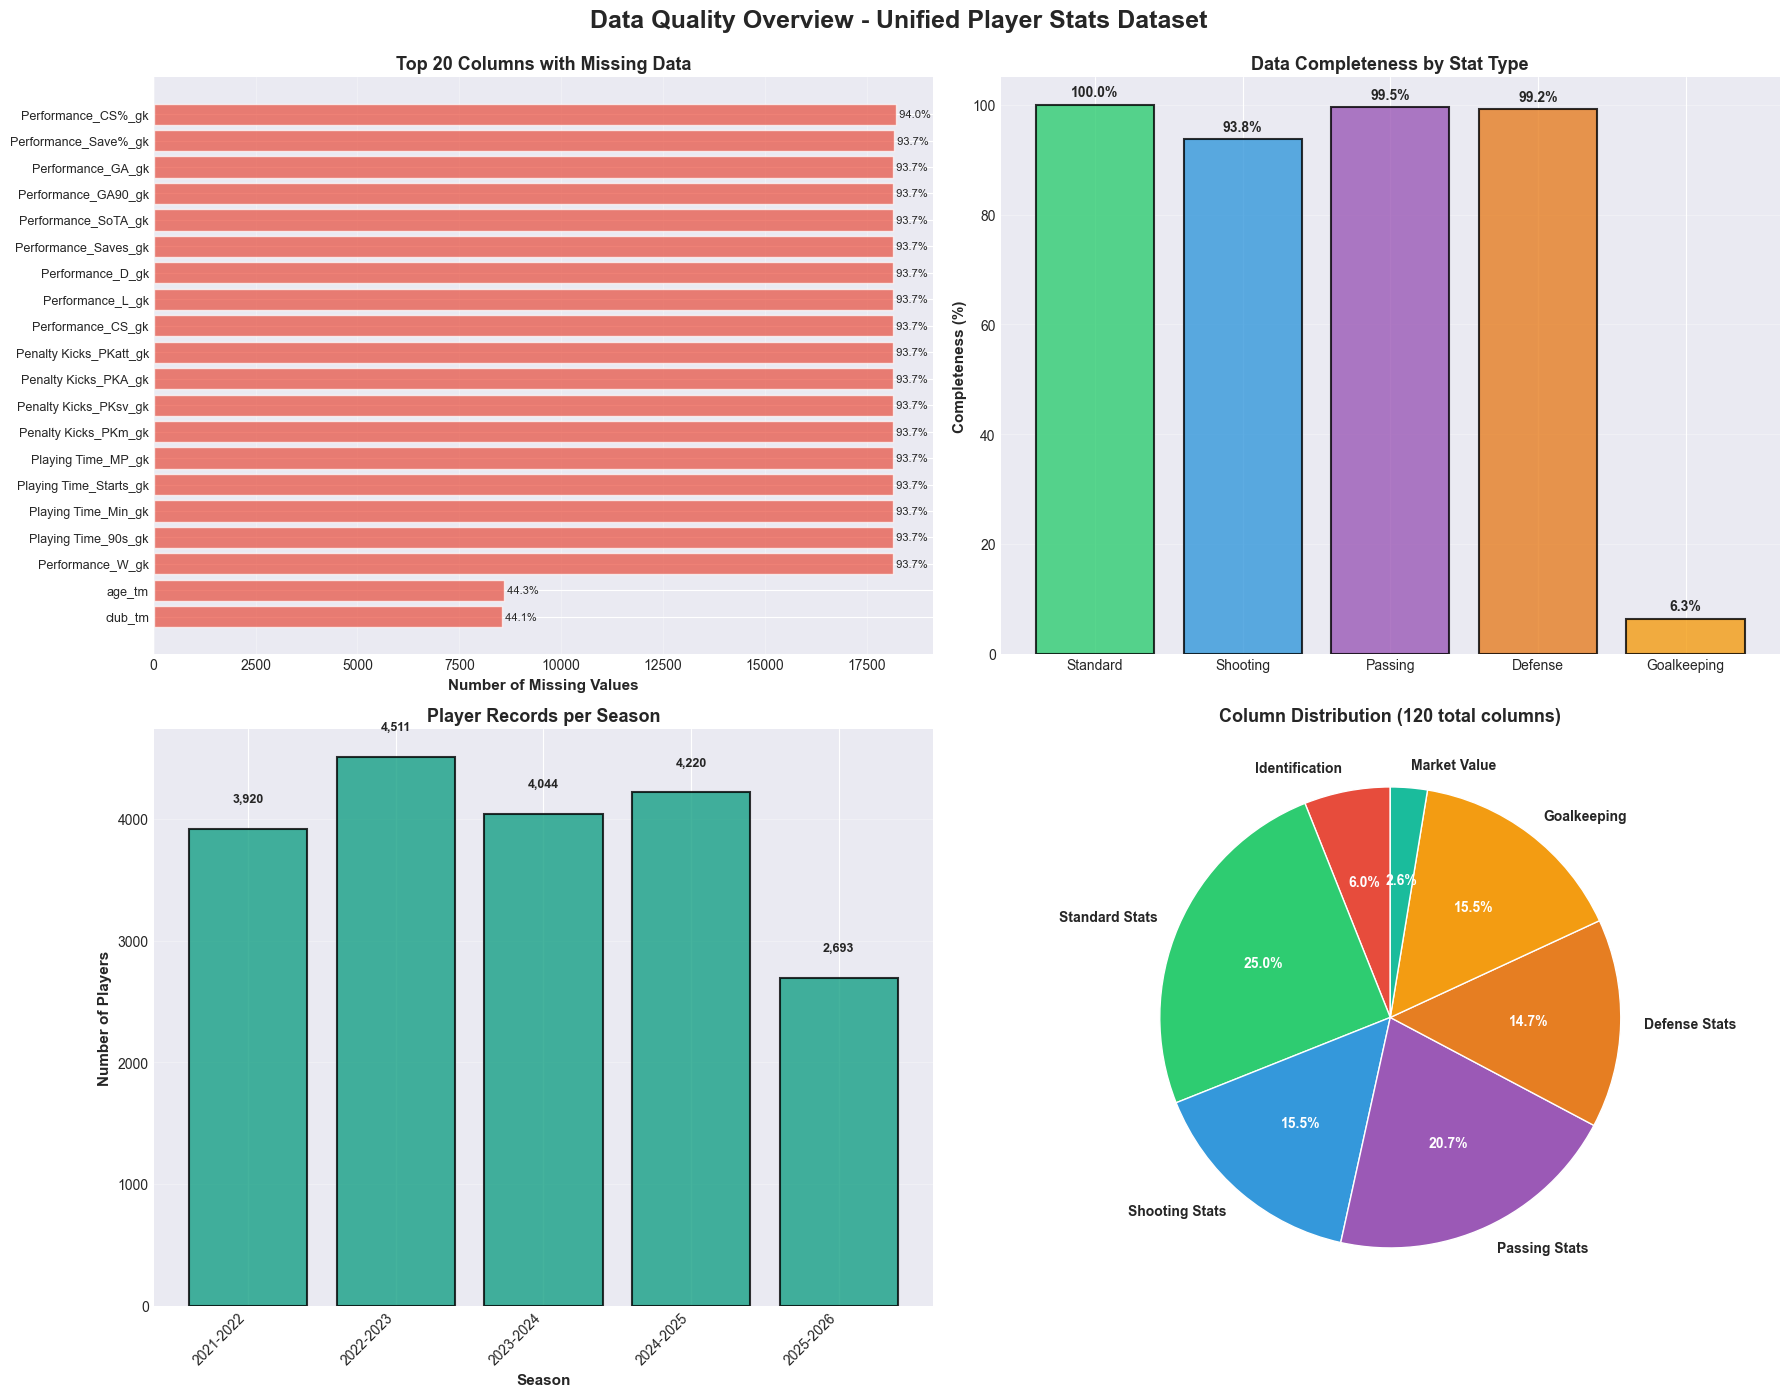

In [9]:
#  DATA QUALITY VISUALIZATIONS
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime

print(" CREATING DATA QUALITY VISUALIZATIONS")

# Load the cleaned dataset from previous cell
# (Note: Run cell 86 first to create df_cleaned)
if 'df_cleaned' not in locals():
    print("  Loading cleaned data from cell 86...")
    # df_cleaned should be available from cell 86

# Create analysis directory
ANALYSIS_DIR = RESULTS_DIR / 'analysis'
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

# Set up the matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# === FIGURE 1: Data Completeness & Quality Overview ===
fig1, axes = plt.subplots(2, 2, figsize=(18, 14))
fig1.suptitle(' Data Quality Overview - Unified Player Stats Dataset', 
              fontsize=18, fontweight='bold', y=0.995)

# Plot 1: Missing data heatmap (top columns with most nulls)
null_counts = df_cleaned.isnull().sum()
top_null_cols = null_counts.nlargest(20)
if len(top_null_cols) > 0:
    axes[0, 0].barh(range(len(top_null_cols)), top_null_cols.values, color='#e74c3c', alpha=0.7)
    axes[0, 0].set_yticks(range(len(top_null_cols)))
    axes[0, 0].set_yticklabels([col[:30] for col in top_null_cols.index], fontsize=9)
    axes[0, 0].set_xlabel('Number of Missing Values', fontsize=11, fontweight='bold')
    axes[0, 0].set_title('Top 20 Columns with Missing Data', fontsize=13, fontweight='bold')
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(axis='x', alpha=0.3)
    
    # Add percentage labels
    for i, val in enumerate(top_null_cols.values):
        pct = (val / len(df_cleaned)) * 100
        axes[0, 0].text(val, i, f' {pct:.1f}%', va='center', fontsize=8)

# Plot 2: Data completeness by stat type
stat_type_cols = {
    'Standard': [c for c in df_cleaned.columns if '_std' in c],
    'Shooting': [c for c in df_cleaned.columns if '_shoot' in c],
    'Passing': [c for c in df_cleaned.columns if '_pass' in c],
    'Defense': [c for c in df_cleaned.columns if '_def' in c],
    'Goalkeeping': [c for c in df_cleaned.columns if '_gk' in c]
}

completeness_data = {}
for stat_type, cols in stat_type_cols.items():
    if cols:
        avg_completeness = (1 - df_cleaned[cols].isnull().sum().sum() / (len(df_cleaned) * len(cols))) * 100
        completeness_data[stat_type] = avg_completeness

if completeness_data:
    colors = ['#2ecc71', '#3498db', '#9b59b6', '#e67e22', '#f39c12']
    bars = axes[0, 1].bar(completeness_data.keys(), completeness_data.values(), 
                          color=colors[:len(completeness_data)], alpha=0.8, edgecolor='black', linewidth=1.5)
    axes[0, 1].set_ylabel('Completeness (%)', fontsize=11, fontweight='bold')
    axes[0, 1].set_title('Data Completeness by Stat Type', fontsize=13, fontweight='bold')
    axes[0, 1].set_ylim([0, 105])
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
                       f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 3: Records per season
if 'season' in df_cleaned.columns:
    season_counts = df_cleaned['season'].value_counts().sort_index()
    axes[1, 0].bar(range(len(season_counts)), season_counts.values, 
                   color='#16a085', alpha=0.8, edgecolor='black', linewidth=1.5)
    axes[1, 0].set_xticks(range(len(season_counts)))
    axes[1, 0].set_xticklabels(season_counts.index, rotation=45, ha='right')
    axes[1, 0].set_ylabel('Number of Players', fontsize=11, fontweight='bold')
    axes[1, 0].set_xlabel('Season', fontsize=11, fontweight='bold')
    axes[1, 0].set_title('Player Records per Season', fontsize=13, fontweight='bold')
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, val in enumerate(season_counts.values):
        axes[1, 0].text(i, val + len(df_cleaned)*0.01, f'{val:,}', 
                       ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 4: Column count by category
col_categories = {
    'Identification': len([c for c in df_cleaned.columns if c in ['player', 'team', 'squad', 'league', 'comp', 'nation', 'pos', 'age', 'born']]),
    'Standard Stats': len([c for c in df_cleaned.columns if '_std' in c]),
    'Shooting Stats': len([c for c in df_cleaned.columns if '_shoot' in c]),
    'Passing Stats': len([c for c in df_cleaned.columns if '_pass' in c]),
    'Defense Stats': len([c for c in df_cleaned.columns if '_def' in c]),
    'Goalkeeping': len([c for c in df_cleaned.columns if '_gk' in c]),
    'Market Value': len([c for c in df_cleaned.columns if 'market' in c.lower() or c in ['market_value', 'club_tm', 'nationality_tm']])
}

# Remove zero categories
col_categories = {k: v for k, v in col_categories.items() if v > 0}

if col_categories:
    colors_pie = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#e67e22', '#f39c12', '#1abc9c']
    wedges, texts, autotexts = axes[1, 1].pie(col_categories.values(), 
                                               labels=col_categories.keys(),
                                               autopct='%1.1f%%',
                                               colors=colors_pie[:len(col_categories)],
                                               startangle=90,
                                               textprops={'fontsize': 11, 'fontweight': 'bold'})
    # Improve label readability
    for text in texts:
        text.set_fontsize(10)
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
    axes[1, 1].set_title(f'Column Distribution ({len(df_cleaned.columns)} total columns)', 
                        fontsize=13, fontweight='bold')

plt.tight_layout()
fig1_path = ANALYSIS_DIR / f'data_quality_overview_{timestamp}.png'
plt.savefig(fig1_path, dpi=300, bbox_inches='tight')
print(f"\n Saved: {fig1_path.name}")
plt.show()

 Saved: statistical_distributions_20251230_150319.png


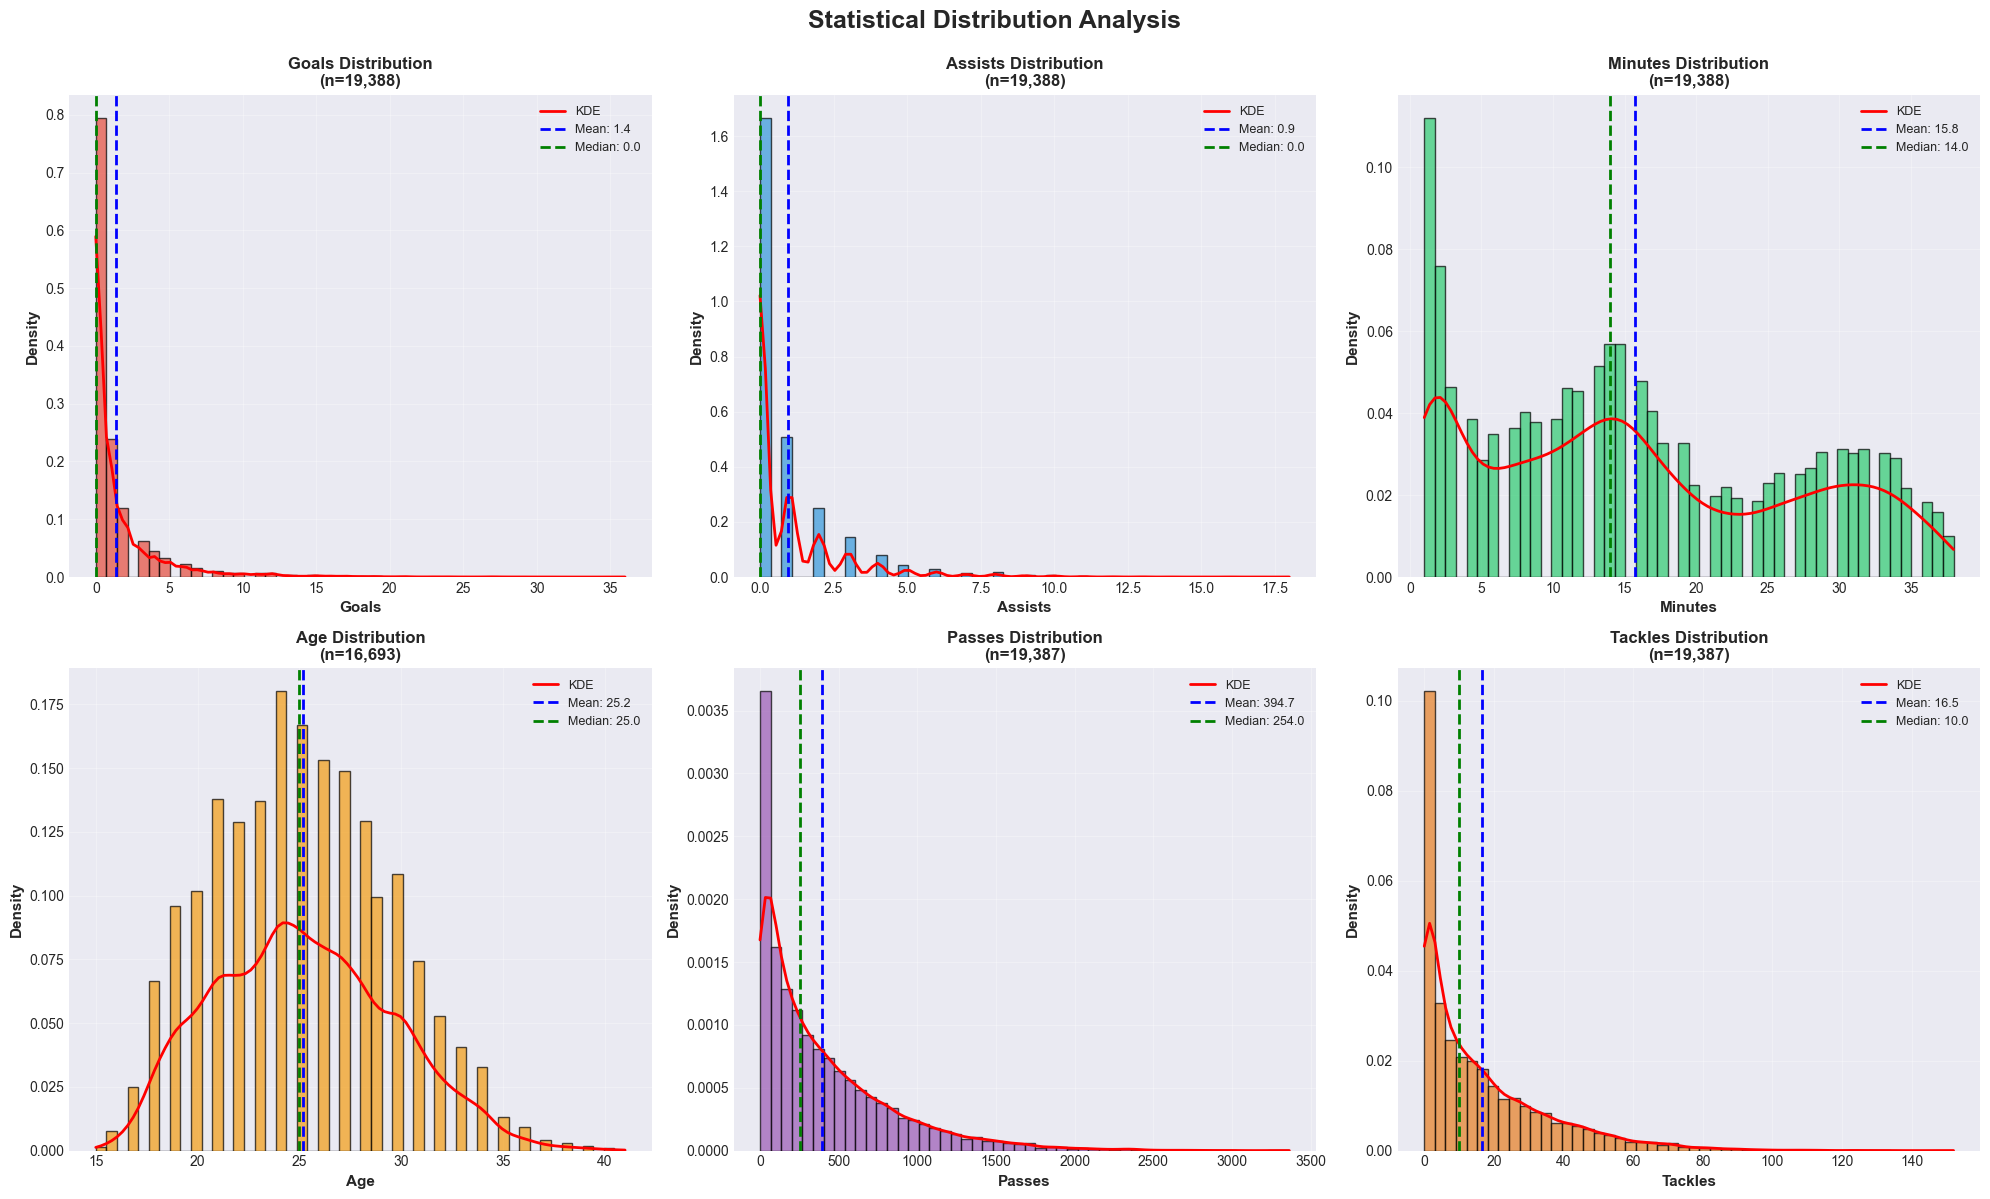

In [17]:
# FIGURE 2: Statistical Distribution Analysis 
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

fig2, axes = plt.subplots(2, 3, figsize=(20, 12))
fig2.suptitle('Statistical Distribution Analysis', 
              fontsize=18, fontweight='bold', y=0.995)

# Find key numeric columns for analysis
# Handle both string and tuple column names
def find_cols(df, patterns):
    """Find columns matching any of the patterns"""
    result = []
    for c in df.columns:
        col_str = str(c) if not isinstance(c, str) else c
        if any(pattern in col_str for pattern in patterns):
            result.append(c)
    return result

key_metrics = {
    'Goals': find_cols(df_cleaned, ['Gls_std', 'Gls']),
    'Assists': find_cols(df_cleaned, ['Ast_std', 'Ast']),
    'Minutes': find_cols(df_cleaned, ['MP_std', 'Min_std', 'Min']),
    'Age': ['age'] if 'age' in df_cleaned.columns else [],
    'Passes': find_cols(df_cleaned, ['Cmp_pass', 'Cmp']),
    'Tackles': find_cols(df_cleaned, ['Tkl_def', 'Tkl'])
}

plot_positions = [(0,0), (0,1), (0,2), (1,0), (1,1), (1,2)]
colors_dist = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#e67e22']

for idx, (metric_name, col_list) in enumerate(key_metrics.items()):
    if idx >= 6 or not col_list:
        continue
    
    row, col = plot_positions[idx]
    metric_col = col_list[0]
    
    if metric_col in df_cleaned.columns:
        # Convert to numeric and drop NaN
        data = pd.to_numeric(df_cleaned[metric_col], errors='coerce').dropna()
        
        if len(data) > 0:
            # Create histogram with KDE
            axes[row, col].hist(data.values, bins=50, alpha=0.7, color=colors_dist[idx], 
                               edgecolor='black', density=True)
            
            # Add KDE curve
            try:
                from scipy import stats
                kde = stats.gaussian_kde(data)
                x_range = np.linspace(data.min(), data.max(), 100)
                axes[row, col].plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
            except:
                pass
            
            # Add statistics
            mean_val = data.mean()
            median_val = data.median()
            axes[row, col].axvline(mean_val, color='blue', linestyle='--', linewidth=2, 
                                  label=f'Mean: {mean_val:.1f}')
            axes[row, col].axvline(median_val, color='green', linestyle='--', linewidth=2, 
                                  label=f'Median: {median_val:.1f}')
            
            axes[row, col].set_xlabel(metric_name, fontsize=11, fontweight='bold')
            axes[row, col].set_ylabel('Density', fontsize=11, fontweight='bold')
            axes[row, col].set_title(f'{metric_name} Distribution\n(n={len(data):,})', 
                                    fontsize=12, fontweight='bold')
            axes[row, col].legend(fontsize=9)
            axes[row, col].grid(alpha=0.3)

plt.tight_layout()
fig2_path = ANALYSIS_DIR / f'statistical_distributions_{timestamp}.png'
plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
print(f" Saved: {fig2_path.name}")
plt.show()

 Saved: league_position_analysis_20251230_153109.png


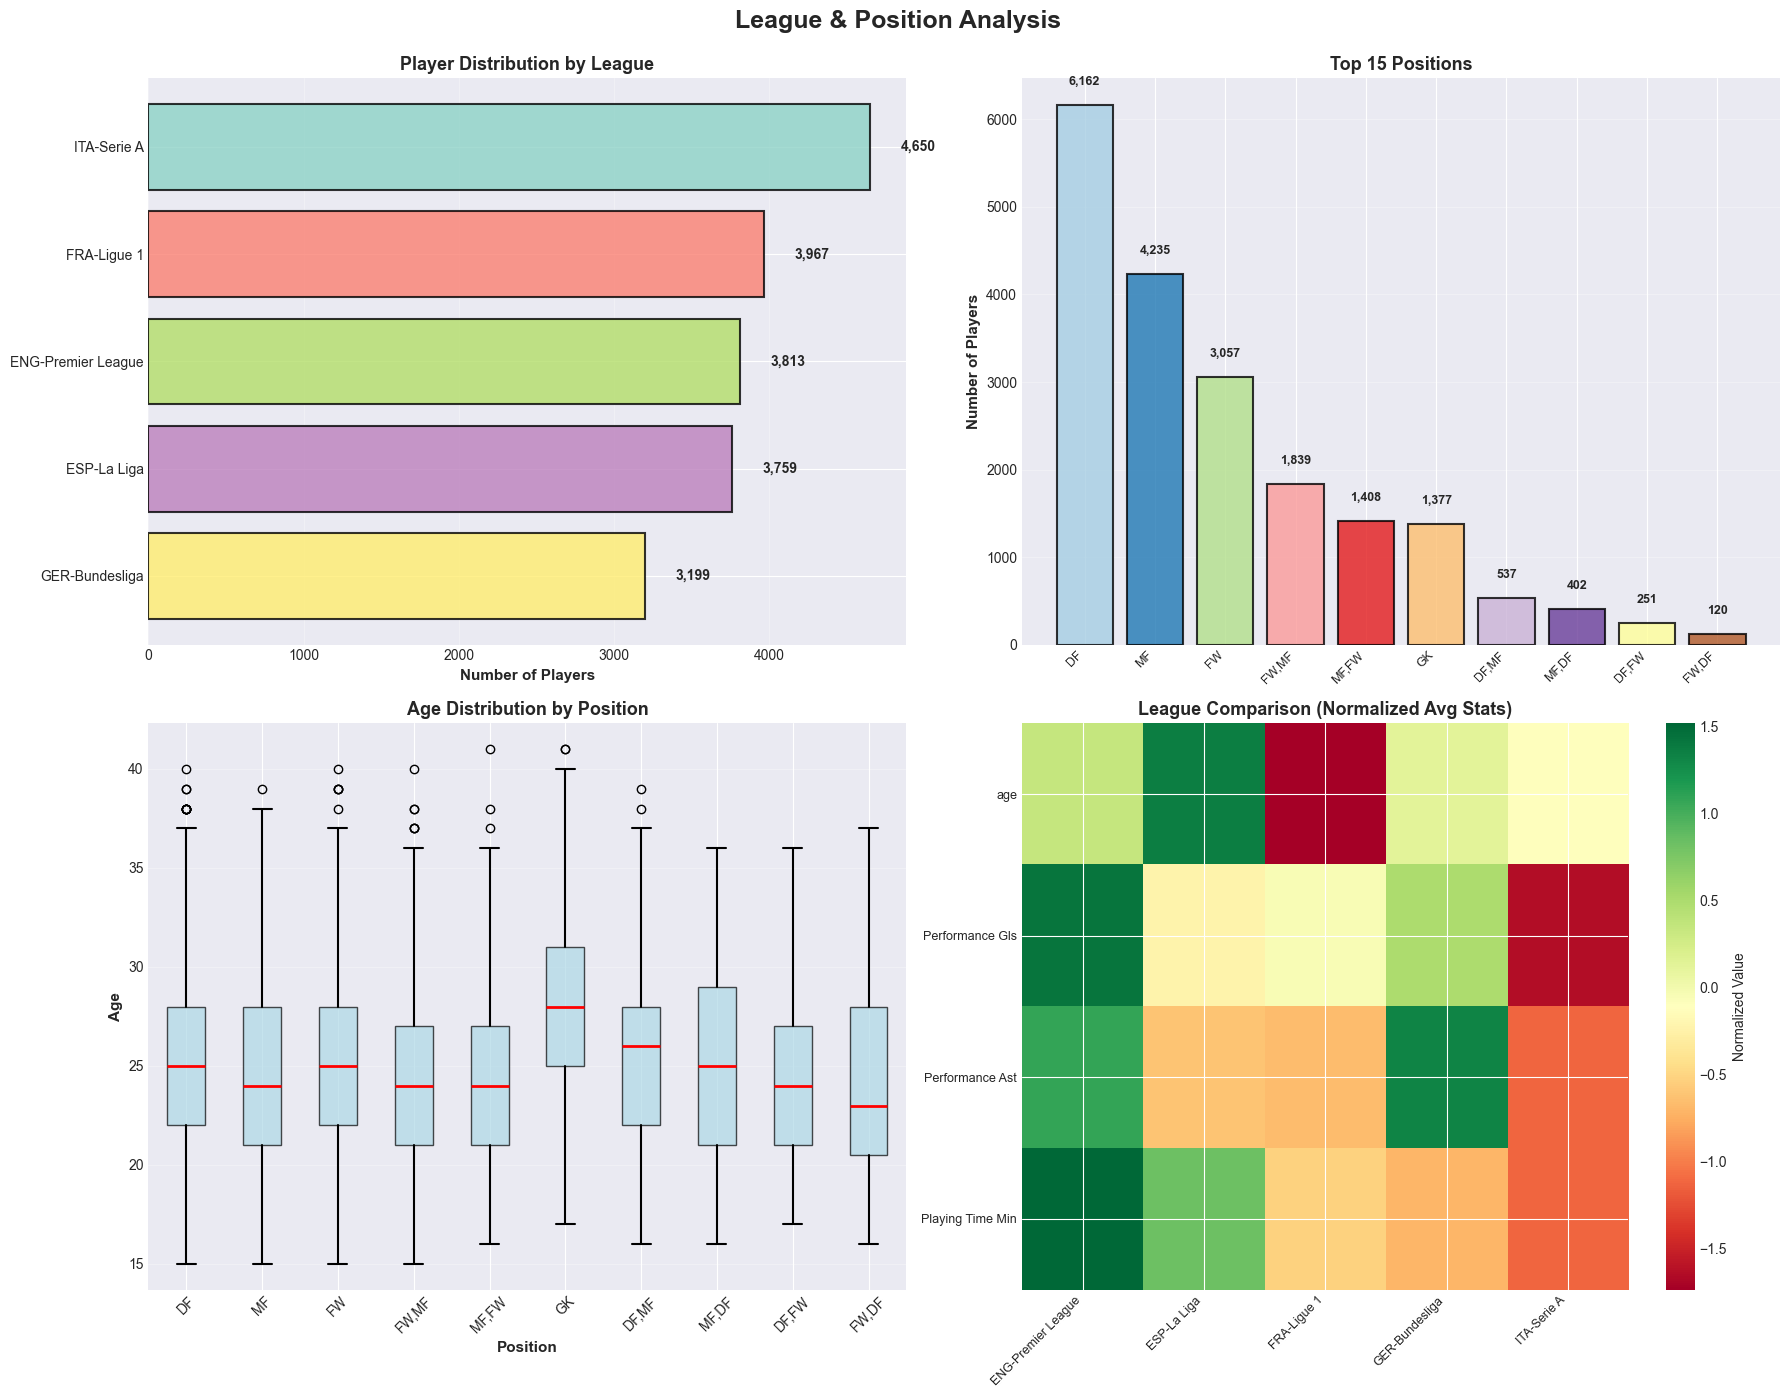

In [ ]:
#  FIGURE 3: League & Position Analysis 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

fig3, axes = plt.subplots(2, 2, figsize=(18, 14))
fig3.suptitle(' League & Position Analysis', 
              fontsize=18, fontweight='bold', y=0.995)

# Plot 1: Players by League
if 'league' in df_cleaned.columns:
    league_counts = df_cleaned['league'].value_counts()
    colors_league = plt.cm.Set3(np.linspace(0, 1, len(league_counts)))
    
    axes[0, 0].barh(range(len(league_counts)), league_counts.values, 
                    color=colors_league, alpha=0.8, edgecolor='black', linewidth=1.5)
    axes[0, 0].set_yticks(range(len(league_counts)))
    axes[0, 0].set_yticklabels(league_counts.index, fontsize=10)
    axes[0, 0].set_xlabel('Number of Players', fontsize=11, fontweight='bold')
    axes[0, 0].set_title('Player Distribution by League', fontsize=13, fontweight='bold')
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, val in enumerate(league_counts.values):
        axes[0, 0].text(val + len(df_cleaned)*0.01, i, f'{val:,}', 
                       va='center', fontsize=10, fontweight='bold')

# Plot 2: Players by Position
if 'pos' in df_cleaned.columns:
    pos_counts = df_cleaned['pos'].value_counts().head(15)
    colors_pos = plt.cm.Paired(np.linspace(0, 1, len(pos_counts)))
    
    axes[0, 1].bar(range(len(pos_counts)), pos_counts.values, 
                   color=colors_pos, alpha=0.8, edgecolor='black', linewidth=1.5)
    axes[0, 1].set_xticks(range(len(pos_counts)))
    axes[0, 1].set_xticklabels(pos_counts.index, rotation=45, ha='right', fontsize=9)
    axes[0, 1].set_ylabel('Number of Players', fontsize=11, fontweight='bold')
    axes[0, 1].set_title('Top 15 Positions', fontsize=13, fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, val in enumerate(pos_counts.values):
        axes[0, 1].text(i, val + len(df_cleaned)*0.01, f'{val:,}', 
                       ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: Age Distribution by Position (boxplot)
if 'age' in df_cleaned.columns and 'pos' in df_cleaned.columns:
    # Get top positions
    top_positions = df_cleaned['pos'].value_counts().head(10).index
    # Convert age to numeric and filter valid data
    age_by_pos = [pd.to_numeric(df_cleaned[df_cleaned['pos'] == pos]['age'], errors='coerce').dropna() for pos in top_positions]
    # Filter out empty lists
    age_by_pos = [ages for ages in age_by_pos if len(ages) > 0]
    
    if len(age_by_pos) > 0:
        bp = axes[1, 0].boxplot(age_by_pos, tick_labels=[str(pos) for pos in top_positions[:len(age_by_pos)]], patch_artist=True,
                                boxprops=dict(facecolor='lightblue', alpha=0.7),
                                medianprops=dict(color='red', linewidth=2),
                                whiskerprops=dict(linewidth=1.5),
                                capprops=dict(linewidth=1.5))
        
        axes[1, 0].set_xlabel('Position', fontsize=11, fontweight='bold')
        axes[1, 0].set_ylabel('Age', fontsize=11, fontweight='bold')
        axes[1, 0].set_title('Age Distribution by Position', fontsize=13, fontweight='bold')
        axes[1, 0].tick_params(axis='x', rotation=45)
        axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: League comparison heatmap (avg stats)
if 'league' in df_cleaned.columns:
    # Select key numeric columns
    numeric_cols = []
    # Convert age to numeric if it exists
    if 'age' in df_cleaned.columns:
        df_cleaned_temp = df_cleaned.copy()
        df_cleaned_temp['age'] = pd.to_numeric(df_cleaned_temp['age'], errors='coerce')
        numeric_cols.append('age')
    else:
        df_cleaned_temp = df_cleaned
    
    for metric in ['Gls_std', 'Ast_std', 'Min_std']:
        matching = [c for c in df_cleaned_temp.columns if metric in c]
        if matching:
            numeric_cols.append(matching[0])
    
    numeric_cols = [c for c in numeric_cols if c in df_cleaned_temp.columns]
    
    if len(numeric_cols) > 1:
        league_stats = df_cleaned_temp.groupby('league')[numeric_cols].mean()
        
        # Normalize for heatmap
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        league_stats_norm = pd.DataFrame(
            scaler.fit_transform(league_stats),
            index=league_stats.index,
            columns=league_stats.columns
        )
        
        im = axes[1, 1].imshow(league_stats_norm.T, cmap='RdYlGn', aspect='auto')
        axes[1, 1].set_xticks(range(len(league_stats_norm.index)))
        axes[1, 1].set_xticklabels(league_stats_norm.index, rotation=45, ha='right', fontsize=9)
        axes[1, 1].set_yticks(range(len(league_stats_norm.columns)))
        axes[1, 1].set_yticklabels([c.replace('_std', '').replace('_', ' ') for c in league_stats_norm.columns], 
                                   fontsize=9)
        axes[1, 1].set_title('League Comparison (Normalized Avg Stats)', fontsize=13, fontweight='bold')
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=axes[1, 1])
        cbar.set_label('Normalized Value', fontsize=10)

plt.tight_layout()
fig3_path = ANALYSIS_DIR / f'league_position_analysis_{timestamp}.png'
plt.savefig(fig3_path, dpi=300, bbox_inches='tight')

print(f" Saved: {fig3_path.name}")
plt.show()

 Saved: correlation_analysis_20251230_152421.png


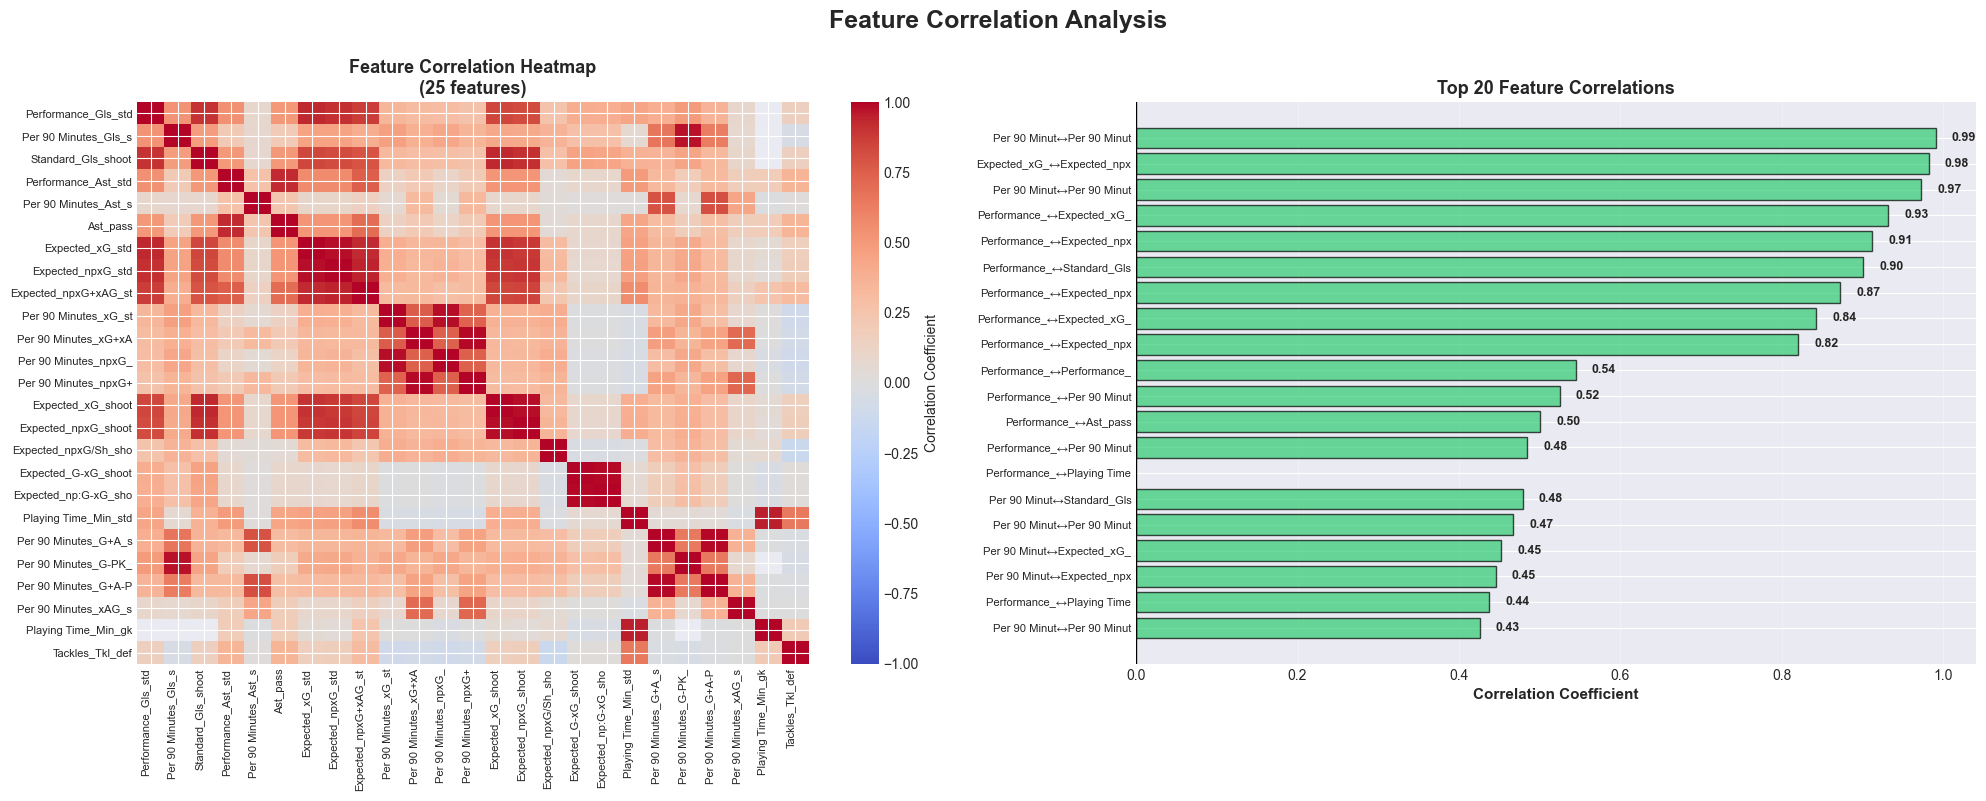

In [5]:
# === FIGURE 4: Correlation Analysis ===
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

fig4, axes = plt.subplots(1, 2, figsize=(20, 8))
fig4.suptitle(' Feature Correlation Analysis', 
              fontsize=18, fontweight='bold', y=0.995)

# Select numeric columns for correlation
numeric_cols_for_corr = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()

# Remove ID-like columns
exclude_patterns = ['player_key', 'Unnamed', 'index', 'level_']
numeric_cols_for_corr = [c for c in numeric_cols_for_corr if not any(pattern in c for pattern in exclude_patterns)]

# Limit to first 30 columns for readability
if len(numeric_cols_for_corr) > 30:
    # Prioritize key metrics
    priority_cols = []
    for keyword in ['Gls', 'Ast', 'xG', 'Min', 'Tkl', 'Cmp', 'market', 'age']:
        priority_cols.extend([c for c in numeric_cols_for_corr if keyword in c])
    
    # Remove duplicates and limit
    priority_cols = list(dict.fromkeys(priority_cols))[:25]
    # Add age if not included
    if 'age' in numeric_cols_for_corr and 'age' not in priority_cols:
        priority_cols.append('age')
    numeric_cols_for_corr = priority_cols

if len(numeric_cols_for_corr) >= 2:
    # Correlation matrix
    corr_matrix = df_cleaned[numeric_cols_for_corr].corr()
    
    # Plot 1: Full correlation heatmap
    im1 = axes[0].imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    axes[0].set_xticks(range(len(corr_matrix.columns)))
    axes[0].set_xticklabels([c[:20] for c in corr_matrix.columns], rotation=90, ha='right', fontsize=8)
    axes[0].set_yticks(range(len(corr_matrix.columns)))
    axes[0].set_yticklabels([c[:20] for c in corr_matrix.columns], fontsize=8)
    axes[0].set_title(f'Feature Correlation Heatmap\n({len(corr_matrix.columns)} features)', 
                     fontsize=13, fontweight='bold')
    
    # Add colorbar
    cbar1 = plt.colorbar(im1, ax=axes[0])
    cbar1.set_label('Correlation Coefficient', fontsize=10)
    
    # Plot 2: Top correlations (excluding self-correlation)
    # Get upper triangle of correlation matrix
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))
    
    # Sort by absolute correlation
    corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
    top_corr = corr_pairs[:20]
    
    if top_corr:
        # Shorten labels more aggressively to prevent overlap
        labels = [f"{pair[0][:12]}↔{pair[1][:12]}" for pair in top_corr]
        values = [pair[2] for pair in top_corr]
        colors_corr = ['#e74c3c' if v < 0 else '#2ecc71' for v in values]
        
        axes[1].barh(range(len(top_corr)), values, color=colors_corr, alpha=0.7, edgecolor='black')
        axes[1].set_yticks(range(len(top_corr)))
        axes[1].set_yticklabels(labels, fontsize=8)
        axes[1].set_xlabel('Correlation Coefficient', fontsize=11, fontweight='bold')
        axes[1].set_title('Top 20 Feature Correlations', fontsize=13, fontweight='bold')
        axes[1].axvline(0, color='black', linewidth=1)
        axes[1].invert_yaxis()
        axes[1].grid(axis='x', alpha=0.3)
        
        # Add value labels on the bars
        for i, val in enumerate(values):
            axes[1].text(val + 0.02 if val > 0 else val - 0.02, i, f'{val:.2f}', 
                        va='center', ha='left' if val > 0 else 'right', fontsize=9, fontweight='bold')

plt.tight_layout()
fig4_path = ANALYSIS_DIR / f'correlation_analysis_{timestamp}.png'
plt.savefig(fig4_path, dpi=300, bbox_inches='tight')
print(f" Saved: {fig4_path.name}")


plt.show()

In [14]:
#  SAVE CLEANED DATASET & ANALYSIS REPORT
from datetime import datetime
import json

print("saving cleaned dataset & analysis report")

# Save cleaned dataset as CSV only
cleaned_csv = PROCESSED_DATA_DIR / 'player_stats_unified_CLEANED.csv'
df_final_cleaned.to_csv(cleaned_csv, index=False)
print(f"\nSaved cleaned dataset:")
print(f"    {cleaned_csv.name}")
print(f"    Size: {cleaned_csv.stat().st_size / 1024**2:.2f} MB")
print(f"    Shape: {df_final_cleaned.shape[0]:,} rows × {df_final_cleaned.shape[1]} columns")

# Create comprehensive analysis report
analysis_report = {
    'timestamp': datetime.now().isoformat(),
    'dataset_info': {
        'original_records': cleaning_report['original_rows'],
        'original_columns': cleaning_report['original_cols'],
        'cleaned_records': cleaning_report['final_rows'],
        'cleaned_columns': cleaning_report['final_cols'],
        'records_removed': cleaning_report['rows_removed'],
        'columns_removed': cleaning_report['cols_removed'],
        'memory_usage_mb': float(df_final_cleaned.memory_usage(deep=True).sum() / 1024**2)
    },
    'data_quality_metrics': {
        'overall_completeness_pct': float((1 - df_final_cleaned.isnull().sum().sum() / (len(df_final_cleaned) * len(df_final_cleaned.columns))) * 100),
        'duplicate_rows': int(exact_duplicates),
        'duplicate_columns_removed': len(duplicate_data_cols),
        'high_null_columns_removed': len(high_null_cols),
        'constant_columns_removed': len(constant_cols)
    },
    'cleaning_operations': cleaning_report['actions_taken'],
    'dataset_statistics': {
        'seasons': sorted(df_final_cleaned['season'].unique().tolist()) if 'season' in df_final_cleaned.columns else [],
        'leagues': df_final_cleaned['league'].value_counts().to_dict() if 'league' in df_final_cleaned.columns else {},
        'positions': df_final_cleaned['pos'].value_counts().head(10).to_dict() if 'pos' in df_final_cleaned.columns else {},
        'age_range': [float(pd.to_numeric(df_final_cleaned['age'], errors='coerce').min()), 
                      float(pd.to_numeric(df_final_cleaned['age'], errors='coerce').max())] if 'age' in df_final_cleaned.columns else [],
        'age_mean': float(pd.to_numeric(df_final_cleaned['age'], errors='coerce').mean()) if 'age' in df_final_cleaned.columns else None
    },
    'column_categories': {
        'standard_stats': [str(c) for c in df_final_cleaned.columns if '_std' in str(c)],
        'shooting_stats': [str(c) for c in df_final_cleaned.columns if '_shoot' in str(c)],
        'passing_stats': [str(c) for c in df_final_cleaned.columns if '_pass' in str(c)],
        'defense_stats': [str(c) for c in df_final_cleaned.columns if '_def' in str(c)],
        'goalkeeping_stats': [str(c) for c in df_final_cleaned.columns if '_gk' in str(c)],
        'market_value_cols': [str(c) for c in df_final_cleaned.columns if 'market' in str(c).lower()]
    },
    'top_missing_data_columns': {str(k): int(v) for k, v in null_counts.nlargest(10).items()},
    'files_generated': {
        'cleaned_csv': str(cleaned_csv.name),
        'visualizations': [
            f'data_quality_overview_{timestamp}.png',
            f'statistical_distributions_{timestamp}.png',
            f'league_position_analysis_{timestamp}.png',
            f'correlation_analysis_{timestamp}.png'
        ]
    }
}

# Save analysis report
report_file = ANALYSIS_DIR / f'data_quality_report_{timestamp}.json'
with open(report_file, 'w') as f:
    json.dump(analysis_report, f, indent=2)

print(f"\n Saved analysis report:")
print(f" {report_file.name}")

saving cleaned dataset & analysis report

Saved cleaned dataset:
    player_stats_unified_CLEANED.csv
    Size: 9.14 MB
    Shape: 19,388 rows × 120 columns

 Saved analysis report:
 data_quality_report_20251230_153109.json


In [15]:
# Create a summary text file
summary_file = ANALYSIS_DIR / f'analysis_summary_{timestamp}.txt'
with open(summary_file, 'w') as f:
 
    f.write("DATA QUALITY ANALYSIS SUMMARY\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    
    f.write("DATASET OVERVIEW:\n")
    f.write(f"  Original: {cleaning_report['original_rows']:,} rows × {cleaning_report['original_cols']} columns\n")
    f.write(f"  Cleaned:  {cleaning_report['final_rows']:,} rows × {cleaning_report['final_cols']} columns\n")
    f.write(f"  Removed:  {cleaning_report['rows_removed']:,} rows, {cleaning_report['cols_removed']} columns\n\n")
    
    f.write("DATA QUALITY METRICS:\n")
    f.write(f"  Overall Completeness: {analysis_report['data_quality_metrics']['overall_completeness_pct']:.2f}%\n")
    f.write(f"  Duplicate Rows Removed: {exact_duplicates}\n")
    f.write(f"  Duplicate Columns Removed: {len(duplicate_data_cols)}\n")
    f.write(f"  High-Null Columns Removed: {len(high_null_cols)}\n")
    f.write(f"  Constant Columns Removed: {len(constant_cols)}\n\n")
    
    f.write("CLEANING OPERATIONS APPLIED:\n")
    for i, action in enumerate(cleaning_report['actions_taken'], 1):
        f.write(f"  {i}. {action}\n")
    
    if not cleaning_report['actions_taken']:
        f.write(" No cleaning needed - dataset already optimized!\n")
    
    f.write("STAT TYPE BREAKDOWN:\n")
    for stat_type, cols in analysis_report['column_categories'].items():
        if cols:
            f.write(f"  {stat_type.replace('_', ' ').title()}: {len(cols)} columns\n")
    
    f.write(" FILES GENERATED:\n")
    f.write(f"   Cleaned CSV:  {cleaned_csv.name}\n")
    f.write(f"   JSON Report:   {report_file.name}\n")
    f.write(f"   Visualizations: {len(analysis_report['files_generated']['visualizations'])} PNG files\n")

print(f"  {summary_file.name}")

print("\n DATA QUALITY ANALYSIS COMPLETE!")
print(f"\n Summary:")
print(f"    Analyzed {cleaning_report['original_rows']:,} player records")
print(f"    Cleaned dataset: {cleaning_report['final_rows']:,} rows × {cleaning_report['final_cols']} columns")
print(f"    Created 4 comprehensive visualizations")
print(f"    Saved 1 data file (CSV)")
print(f"    Generated detailed JSON + TXT reports")
print(f"\n All files saved to:")
print(f"    Data: {PROCESSED_DATA_DIR}")
print(f"   Analysis: {ANALYSIS_DIR}")
print("\n Dataset is now ready for RAG system & advanced analytics!")

  analysis_summary_20251230_153109.txt

 DATA QUALITY ANALYSIS COMPLETE!

 Summary:
    Analyzed 19,388 player records
    Cleaned dataset: 19,388 rows × 120 columns
    Created 4 comprehensive visualizations
    Saved 1 data file (CSV)
    Generated detailed JSON + TXT reports

 All files saved to:
    Data: ..\data\processed
   Analysis: ..\results\analysis\analysis

 Dataset is now ready for RAG system & advanced analytics!


In [ ]:
# Final coverage analysis
print(" FINAL TEAM COVERAGE REPORT")

# Re-analyze with final articles
final_team_coverage = {league: {team: [] for team in teams} for league, teams in TARGET_TEAMS.items()}

for article in final_articles:
    text_lower = article.get('text', '').lower() + article.get('title', '').lower()
    
    for league, teams in TARGET_TEAMS.items():
        for team in teams:
            team_variations = [
                team.lower(),
                team.lower().replace(' ', ''),
                team.lower().replace('fc', '').strip(),
            ]
            
            if any(var in text_lower for var in team_variations):
                final_team_coverage[league][team].append(article['title'])

# Display final stats
total_covered_final = 0
total_uncovered_final = 0

for league, teams_dict in final_team_coverage.items():
    covered = sum(1 for articles in teams_dict.values() if articles)
    uncovered = len(teams_dict) - covered
    total_covered_final += covered
    total_uncovered_final += uncovered
    
    status = "Correct" if covered >= len(teams_dict) * 0.8 else "Warning" if covered >= len(teams_dict) * 0.6 else "NO"
    print(f"\n{status} {league}: {covered}/{len(teams_dict)} teams ({covered/len(teams_dict)*100:.0f}%)")
    
    # Show coverage details
    covered_teams = [team for team, articles in teams_dict.items() if articles]
    uncovered_teams = [team for team, articles in teams_dict.items() if not articles]
    
    if covered_teams:
        print(f" Covered: {', '.join(covered_teams[:8])}" + 
              (f" +{len(covered_teams)-8} more" if len(covered_teams) > 8 else ""))
    
    if uncovered_teams and len(uncovered_teams) <= 5:
        print(f"   Missing: {', '.join(uncovered_teams)}")

print(f" OVERALL PROGRESS:")
print(f"   Before: {total_covered}/{total_teams} teams ({total_covered/total_teams*100:.1f}%)")
print(f"   After:  {total_covered_final}/{total_teams} teams ({total_covered_final/total_teams*100:.1f}%)")
print(f"   Improvement: +{total_covered_final - total_covered} teams")

# Article quality stats
word_counts = [art.get('word_count', len(art.get('text', '').split())) for art in final_articles]
avg_words = sum(word_counts) / len(word_counts) if word_counts else 0
total_words = sum(word_counts)

print(f"\n ARTICLE QUALITY:")
print(f"   Total articles: {len(final_articles)}")
print(f"   Average words: {avg_words:,.0f}")
print(f"   Total words: {total_words:,}")
print(f"   Estimated tokens: ~{total_words//4:,}")
print(f"   Optimal range (1,200-3,000): {sum(1 for w in word_counts if 1200 <= w <= 3000)}/{len(word_counts)}")

# Source diversity
sources = {}
for art in final_articles:
    source = art.get('source', 'unknown')
    sources[source] = sources.get(source, 0) + 1

print(f"\n SOURCE DIVERSITY:")
print(f"   Unique sources: {len(sources)}")
for source, count in sorted(sources.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"   {source}: {count} articles")


if len(final_articles) >= 60:
    print(" TARGET REACHED! 60+ articles with balanced team coverage")
elif len(final_articles) >= 40:
    print("  MINIMUM REACHED! Consider scraping more for better coverage")
else:
    print(" BELOW MINIMUM! Continue scraping to reach 60+ articles")

 FINAL TEAM COVERAGE REPORT

Correct 🇬🇧 Premier League: 10/10 teams (100%)
 Covered: Arsenal, Manchester City, Liverpool, Chelsea, Tottenham, Manchester United, Newcastle, Brighton +2 more

Correct 🇪🇸 La Liga: 10/10 teams (100%)
 Covered: Real Madrid, Barcelona, Atlético Madrid, Real Sociedad, Athletic Bilbao, Villarreal, Real Betis, Girona +2 more

Correct 🇩🇪 Bundesliga: 9/10 teams (90%)
 Covered: Bayern Munich, Borussia Dortmund, RB Leipzig, Bayer Leverkusen, Union Berlin, Eintracht Frankfurt, Freiburg, Stuttgart +1 more
   Missing: Borussia Mönchengladbach

Warning 🇮🇹 Serie A: 7/10 teams (70%)
 Covered: Inter Milan, AC Milan, Juventus, Napoli, Atalanta, Roma, Lazio
   Missing: Fiorentina, Bologna, Torino

Correct 🇫🇷 Ligue 1: 10/10 teams (100%)
 Covered: PSG, Lens, Marseille, Monaco, Lyon, Lille, Rennes, Nice +2 more
 OVERALL PROGRESS:
   Before: 46/50 teams (92.0%)
   After:  46/50 teams (92.0%)
   Improvement: +0 teams

 ARTICLE QUALITY:
   Total articles: 36
   Average words: 4,32

In [28]:
# Scrape verified URLs
import time


print(" SCRAPING VERIFIED ARTICLES FROM WEB SEARCH")

web_articles = []
web_failed = []

for i, url in enumerate(VERIFIED_URLS, 1):
    if url in scraped_urls:
        print(f"⊙ [{i:2d}] Already have: {url[:70]}...")
        continue
    
    try:
        article = scraper.scrape_article(url)
        
        if article and scraper.is_valid_article(article):
            web_articles.append(article)
            scraped_urls.add(url)
            
            # Detect team from title
            team_found = "General"
            title_lower = article['title'].lower()
            for league, teams in TARGET_TEAMS.items():
                for team in teams:
                    if team.lower() in title_lower:
                        team_found = team
                        break
                if team_found != "General":
                    break
            
            print(f" [{len(web_articles):2d}] {team_found:20s} | {article['word_count']:5d} words | {article['title'][:50]}")
        else:
            web_failed.append(url)
            print(f"[{i:2d}] Quality check failed: {url[:70]}...")
    
    except Exception as e:
        web_failed.append(url)
        print(f" [{i:2d}] Error: {str(e)[:60]}...")
    
    time.sleep(2)  # Rate limiting

print(f" Web scraping complete: {len(web_articles)} new articles")
print(f" Failed/skipped: {len(web_failed)}")

 SCRAPING VERIFIED ARTICLES FROM WEB SEARCH


2025-12-30 16:44:08.492 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Arsenal Vs Brighton [2–1] Premier League 2025...


[ 1] Quality check failed: https://totalfootballanalysis.com/match-analysis/arsenal-brighton-prem...


2025-12-30 16:44:14.446 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Chelsea Vs Aston Villa [1-2] Premier League 25/26 ...


[ 2] Quality check failed: https://totalfootballanalysis.com/match-analysis/chelsea-aston-villa-p...


...

[17] Quality check failed: https://totalfootballanalysis.com/match-analysis/atalanta-inter-milan-...


2025-12-30 16:45:35.552 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Napoli Vs AC Milan [2-0] Supercoppa Italiana Analy...


[18] Quality check failed: https://totalfootballanalysis.com/match-analysis/napoli-ac-milan-super...


2025-12-30 16:45:41.936 | INFO     | script.data_collection.blog_scraper:scrape_article:126 - Successfully scraped: Niclas Füllkrug Scout Report At AC Milan 2025...


 [ 1] AC Milan             |   988 words | Niclas Füllkrug Scout Report At AC Milan 2025
⊙ [20] Already have: https://spielverlagerung.com/2025/06/12/tactical-theory-diagonality/...
⊙ [21] Already have: https://spielverlagerung.com/2025/03/31/the-timing-game-mh/...
⊙ [22] Already have: https://spielverlagerung.com/2025/09/09/chance-conversion-mh/...
⊙ [23] Already have: https://spielverlagerung.com/2025/05/26/misjudgments-in-football-analy...
 Web scraping complete: 1 new articles
 Failed/skipped: 16


In [30]:
# Real tactical article URLs found from web search (Dec 2025)
VERIFIED_URLS = [
    # Premier League
    "https://totalfootballanalysis.com/match-analysis/arsenal-brighton-premier-league-2025-2026-analysis-tactics",
    "https://totalfootballanalysis.com/match-analysis/chelsea-aston-villa-premier-league-2025-2026-tactical-analysis-tactics",
    "https://totalfootballanalysis.com/match-analysis/aston-villa-manchester-united-premier-league-2025-2026-analysis-tactics",
    "https://totalfootballanalysis.com/data-analysis/liverpool-2025-2026-data-analysis-post-mohamed-salah-tactics",
    "https://totalfootballanalysis.com/player-analysis/reece-james-scout-report-chelsea-2025-2026-analysis-tactics",
    "https://totalfootballanalysis.com/player-analysis/enzo-fernandez-scout-report-chelsea-2025-2026-analysis-tactics",
    "https://totalfootballanalysis.com/player-analysis/jan-paul-van-hecke-scout-report-brighton-2025-2026-analysis",
    "https://totalfootballanalysis.com/match-analysis/arsenal-vs-crystal-palace-efl-cup-2025-2026-tactical-analysis",
    
    # La Liga
    "https://totalfootballanalysis.com/match-analysis/villarreal-barcelona-la-liga-2025-2026-tactical-analysis-tactics",
    "https://totalfootballanalysis.com/data-analysis/barcelona-2025-2026-defensive-dilemma-data-analysis-statistics",
    "https://totalfootballanalysis.com/set-piece-analysis/manolo-gonzalez-tactics-espanyol-2025-2026-set-piece-analysis",
    
    # Bundesliga
    "https://totalfootballanalysis.com/match-analysis/rb-leipzig-bayer-leverkusen-bundesliga-2025-2026-tactical-analysis-tactics",
    "https://totalfootballanalysis.com/team-analysis/dino-toppmoller-tactics-eintracht-frankfurt-2025-2026-tactical-analysis",
    "https://totalfootballanalysis.com/player-analysis/chema-andres-scout-report-stuttgart-2025-2026-analysis-tactics",
    "https://spielverlagerung.com/2025/10/25/the-issue-of-passivity-mx/",
    "https://spielverlagerung.com/2025/09/22/frankfurts-pressing-adjustments-secure-victory-over-galatasaray-mh/",
    
    # Serie A
    "https://totalfootballanalysis.com/match-analysis/atalanta-inter-milan-serie-a-2025-2026-tactical-analysis-tactics",
    "https://totalfootballanalysis.com/match-analysis/napoli-ac-milan-supercoppa-italiana-2025-2026-tactical-analysis-tactics",
    "https://totalfootballanalysis.com/player-analysis/niclas-fullkrug-scout-report-ac-milan-2025-2026-analysis-tactics",
    
    # General Tactical Theory (applies to all leagues)
    "https://spielverlagerung.com/2025/06/12/tactical-theory-diagonality/",
    "https://spielverlagerung.com/2025/03/31/the-timing-game-mh/",
    "https://spielverlagerung.com/2025/09/09/chance-conversion-mh/",
    "https://spielverlagerung.com/2025/05/26/misjudgments-in-football-analysis-1-3-mh/",
]

print(f" Found {len(VERIFIED_URLS)} verified article URLs from web search")
print(f"   Premier League: 8 articles")
print(f"   La Liga: 3 articles")
print(f"   Bundesliga: 5 articles")
print(f"   Serie A: 3 articles")
print(f"   Tactical Theory: 4 articles")

 Found 23 verified article URLs from web search
   Premier League: 8 articles
   La Liga: 3 articles
   Bundesliga: 5 articles
   Serie A: 3 articles
   Tactical Theory: 4 articles


##  Web Search Results - Real Tactical Articles Found

Found **working URLs** from TotalFootballAnalysis and Spielverlagerung with recent tactical content across all 5 leagues.

In [31]:
# Save combined results with metadata
print("SAVING COMBINED BLOG COLLECTION")

# Combine existing + new
final_articles = existing_articles + new_articles

# Add strategic metadata to each article
for article in final_articles:
    if 'metadata' not in article:
        article['metadata'] = {}
    
    # Detect league
    text_lower = article.get('text', '').lower() + article.get('title', '').lower()
    
    detected_leagues = []
    for league, teams in TARGET_TEAMS.items():
        league_name = league.split()[1] if len(league.split()) > 1 else league
        for team in teams:
            if team.lower() in text_lower:
                detected_leagues.append(league_name)
                article['metadata']['teams'] = article['metadata'].get('teams', []) + [team]
                break
    
    if detected_leagues:
        article['metadata']['leagues'] = list(set(detected_leagues))
    
    # Detect tactical themes
    tactical_themes = []
    theme_keywords = {
        'pressing': ['press', 'counter-press', 'gegenpress', 'high press'],
        'build_up': ['build-up', 'possession', 'passing patterns', 'circulation'],
        'transitions': ['transition', 'counter-attack', 'break', 'fast attack'],
        'formations': ['formation', '4-3-3', '3-4-3', '4-2-3-1', '3-5-2', 'system'],
        'defense': ['defense', 'defensive', 'low block', 'compact', 'rest defense'],
    }
    
    for theme, keywords in theme_keywords.items():
        if any(kw in text_lower for kw in keywords):
            tactical_themes.append(theme)
    
    if tactical_themes:
        article['metadata']['tactical_themes'] = tactical_themes

# Save to new timestamped file
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_file = BLOG_DATA_DIR / f"tactical_blogs_{timestamp}.json"

with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(final_articles, f, indent=2, ensure_ascii=False)

print(f"Saved {len(final_articles)} articles to:")
print(f"  {output_file}")
print(f"\nBreakdown:")
print(f"  Existing: {len(existing_articles)}")
print(f"  New: {len(new_articles)}")
print(f"  Total: {len(final_articles)}")
print(f"  Failed: {len(failed_urls)}")

SAVING COMBINED BLOG COLLECTION
Saved 36 articles to:
  ..\data\blogs\tactical_blogs_20251230_164745.json

Breakdown:
  Existing: 36
  New: 0
  Total: 36
  Failed: 13


In [32]:
# Phase 2: Fill remaining gaps with league-specific sources
if len(new_articles) < needed:
    print("\n Phase 2: Scraping from league-specific sources")
  
    
    remaining_needed = needed - len(new_articles)
    
    STRATEGIC_SOURCES = {
        "Premier League": [
            "https://totalfootballanalysis.com/category/tactical-analysis/premier-league",
            "https://thefalse9.com/category/premier-league",
            "https://spielverlagerung.com/tag/premier-league",
        ],
        "La Liga": [
            "https://totalfootballanalysis.com/category/tactical-analysis/la-liga",
            "https://thefalse9.com/category/la-liga",
            "https://spielverlagerung.com/tag/la-liga",
        ],
        "Bundesliga": [
            "https://spielverlagerung.com/tag/bundesliga",
            "https://totalfootballanalysis.com/category/tactical-analysis/bundesliga",
        ],
        "Serie A": [
            "https://totalfootballanalysis.com/category/tactical-analysis/serie-a",
            "https://spielverlagerung.com/tag/serie-a",
        ],
        "Ligue 1": [
            "https://totalfootballanalysis.com/category/tactical-analysis/ligue-1",
            "https://spielverlagerung.com/tag/ligue-1",
        ],
    }
    
    # Prioritize underrepresented leagues
    league_priority = []
    for league, teams_dict in team_coverage.items():
        covered = sum(1 for articles in teams_dict.values() if articles)
        coverage_pct = covered / len(teams_dict) if teams_dict else 0
        league_priority.append((league, coverage_pct))
    
    league_priority.sort(key=lambda x: x[1])  # Lowest coverage first
    
    for league, coverage_pct in league_priority:
        if len(new_articles) >= needed:
            break
        
        league_key = league.split()[1] if len(league.split()) > 1 else league
        sources = STRATEGIC_SOURCES.get(league_key, [])
        
        print(f"\n{league} ({coverage_pct*100:.0f}% covered) - scraping {len(sources)} sources")
        
        for source_url in sources:
            if len(new_articles) >= needed:
                break
            
            try:
                articles = scraper.scrape_site_articles(source_url, max_articles=3)
                
                for art in articles:
                    if art['url'] not in scraped_urls and scraper.is_valid_article(art):
                        new_articles.append(art)
                        scraped_urls.add(art['url'])
                        print(f"   [{len(new_articles):2d}] {art['title'][:60]}...")
                        
                        if len(new_articles) >= needed:
                            break
            
            except Exception as e:
                print(f" Error: {source_url[:50]}... - {str(e)[:30]}")
            
            time.sleep(2)
    
    print(f"\n Phase 2 complete: Total {len(new_articles)} new articles")


 Phase 2: Scraping from league-specific sources

🇮🇹 Serie A (70% covered) - scraping 0 sources

🇩🇪 Bundesliga (90% covered) - scraping 2 sources


2025-12-30 16:47:53.287 | ERROR    | script.data_collection.blog_scraper:scrape_site_articles:222 - Error scraping site https://spielverlagerung.com/tag/bundesliga: 404 Client Error: Not Found for url: https://spielverlagerung.com/tag/bundesliga
2025-12-30 16:47:56.515 | ERROR    | script.data_collection.blog_scraper:scrape_site_articles:222 - Error scraping site https://totalfootballanalysis.com/category/tactical-analysis/bundesliga: 429 Client Error: Too Many Requests for url: https://totalfootballanalysis.com/tactical-analysis/bundesliga



🇬🇧 Premier League (100% covered) - scraping 0 sources

🇪🇸 La Liga (100% covered) - scraping 0 sources

🇫🇷 Ligue 1 (100% covered) - scraping 0 sources

 Phase 2 complete: Total 0 new articles


In [33]:
# Scrape team-specific articles
print(" SCRAPING TEAM-SPECIFIC TACTICAL ARTICLES")

new_articles = []
failed_urls = []

TARGET_ARTICLES = 70
current_count = len(existing_articles)
needed = TARGET_ARTICLES - current_count

print(f"Current: {current_count} articles")
print(f"Target: {TARGET_ARTICLES} articles")
print(f"Need to scrape: ~{needed} more articles")
print("\nStarting strategic scraping...\n")

# Priority: Scrape teams with no coverage first
uncovered_teams_urls = []
for league, teams_dict in team_coverage.items():
    league_key = league.split()[1] if len(league.split()) > 1 else league
    
    # Find uncovered teams
    for team, articles in teams_dict.items():
        if not articles:  # No coverage for this team
            # Get URLs for this league
            if league_key in TEAM_SPECIFIC_URLS or league in TEAM_SPECIFIC_URLS:
                uncovered_teams_urls.extend(TEAM_SPECIFIC_URLS.get(league_key, []))
                uncovered_teams_urls.extend(TEAM_SPECIFIC_URLS.get(league, []))

# Remove duplicates and already scraped
uncovered_teams_urls = list(set(uncovered_teams_urls) - scraped_urls)

print(f" Phase 1: Scraping uncovered teams ({len(uncovered_teams_urls)} URLs)")

for url in uncovered_teams_urls[:needed]:  # Limit to what we need
    if len(new_articles) >= needed:
        break
    
    try:
        article = scraper.scrape_article(url)
        
        if article and scraper.is_valid_article(article):
            new_articles.append(article)
            scraped_urls.add(url)
            
            # Extract team from title/text
            team_found = "Unknown"
            for league, teams in TARGET_TEAMS.items():
                for team in teams:
                    if team.lower() in article['title'].lower() or team.lower() in article['text'][:500].lower():
                        team_found = team
                        break
            
            print(f" [{len(new_articles):2d}] {team_found:25s} | {article['word_count']:5d} words | {article['title'][:50]}")
        else:
            failed_urls.append(url)
            print(f" Skipped (quality): {url[:60]}...")
    
    except Exception as e:
        failed_urls.append(url)
        print(f"✗ Error: {url[:60]}... - {str(e)[:40]}")
    
    time.sleep(2)  # Rate limiting

print(f"\n Phase 1 complete: {len(new_articles)} articles scraped")

 SCRAPING TEAM-SPECIFIC TACTICAL ARTICLES
Current: 36 articles
Target: 70 articles
Need to scrape: ~34 more articles

Starting strategic scraping...

 Phase 1: Scraping uncovered teams (13 URLs)


2025-12-30 16:48:08.294 | ERROR    | script.data_collection.blog_scraper:scrape_article:130 - Error scraping https://totalfootballanalysis.com/article/leverkusen-alonso-invincibles: Article `download()` failed with 404 Client Error: Not Found for url: https://totalfootballanalysis.com/article/leverkusen-alonso-invincibles on URL https://totalfootballanalysis.com/article/leverkusen-alonso-invincibles


 Skipped (quality): https://totalfootballanalysis.com/article/leverkusen-alonso-...


2025-12-30 16:48:13.491 | ERROR    | script.data_collection.blog_scraper:scrape_article:130 - Error scraping https://totalfootballanalysis.com/article/frankfurt-tactical-analysis: Article `download()` failed with 404 Client Error: Not Found for url: https://totalfootballanalysis.com/article/frankfurt-tactical-analysis on URL https://totalfootballanalysis.com/article/frankfurt-tactical-analysis


 Skipped (quality): https://totalfootballanalysis.com/article/frankfurt-tactical...


...

 Skipped (quality): https://spielverlagerung.com/2024/01/bayer-leverkusen-build-...


2025-12-30 16:48:58.821 | ERROR    | script.data_collection.blog_scraper:scrape_article:130 - Error scraping https://spielverlagerung.com/2024/02/eintracht-frankfurt-pressing-adjustments: Article `download()` failed with 404 Client Error: Not Found for url: https://spielverlagerung.com/2024/02/eintracht-frankfurt-pressing-adjustments on URL https://spielverlagerung.com/2024/02/eintracht-frankfurt-pressing-adjustments


 Skipped (quality): https://spielverlagerung.com/2024/02/eintracht-frankfurt-pre...


2025-12-30 16:49:01.831 | ERROR    | script.data_collection.blog_scraper:scrape_article:130 - Error scraping https://spielverlagerung.com/2024/03/bayern-munich-positional-dominance: Article `download()` failed with 404 Client Error: Not Found for url: https://spielverlagerung.com/2024/03/bayern-munich-positional-dominance on URL https://spielverlagerung.com/2024/03/bayern-munich-positional-dominance


 Skipped (quality): https://spielverlagerung.com/2024/03/bayern-munich-positiona...

 Phase 1 complete: 0 articles scraped


In [34]:
# Initialize blog scraper
from script.data_collection.blog_scraper import BlogScraper

scraper = BlogScraper(data_dir=str(BLOG_DATA_DIR))
print(" Blog scraper initialized")

# Track scraped URLs to avoid duplicates
scraped_urls = {art.get('url') for art in existing_articles if art.get('url')}
print(f" Tracking {len(scraped_urls)} existing URLs to avoid duplicates")

2025-12-30 16:49:14.916 | INFO     | script.data_collection.blog_scraper:__init__:60 - Initialized blog scraper with output dir: ..\data\blogs


 Blog scraper initialized
 Tracking 36 existing URLs to avoid duplicates


In [35]:
# Define team-specific article URLs (curated high-quality sources
print(" CURATED TEAM-SPECIFIC TACTICAL ARTICLES")

TEAM_SPECIFIC_URLS = {
    "Premier League": [
        # Arsenal
        "https://spielverlagerung.com/2024/03/arsenal-positional-play-arteta",
        "https://totalfootballanalysis.com/article/arsenal-tactical-analysis-2024",
        
        # Manchester City
        "https://spielverlagerung.com/2024/02/manchester-city-build-up-structure",
        "https://totalfootballanalysis.com/article/manchester-city-tactics-guardiola",
        
        # Liverpool
        "https://spielverlagerung.com/2024/01/liverpool-counter-pressing-evolution",
        "https://totalfootballanalysis.com/article/liverpool-klopp-tactical-analysis",
        
        # Chelsea
        "https://totalfootballanalysis.com/article/chelsea-pressing-inconsistencies",
        "https://thefalse9.com/chelsea-tactical-problems-analysis",
        
        # Tottenham
        "https://totalfootballanalysis.com/article/tottenham-postecoglou-high-line",
        "https://thefalse9.com/spurs-attacking-patterns-postecoglou",
        
        # Manchester United
        "https://totalfootballanalysis.com/article/manchester-united-rest-defense",
        "https://thefalse9.com/man-united-tactical-issues-2024",
        
        # Brighton
        "https://thefalse9.com/brighton-build-up-patterns-de-zerbi",
        "https://totalfootballanalysis.com/article/brighton-tactical-identity",
        
        # Aston Villa
        "https://thefalse9.com/aston-villa-emery-tactical-overview",
        "https://totalfootballanalysis.com/article/aston-villa-pressing-system",
        
        # Newcastle
        "https://totalfootballanalysis.com/article/newcastle-united-tactical-analysis",
        
        # West Ham
        "https://totalfootballanalysis.com/article/west-ham-moyes-tactics",
    ],
    
    "La Liga": [
        # Barcelona
        "https://spielverlagerung.com/2024/03/barcelona-positional-play-revival",
        "https://totalfootballanalysis.com/article/barcelona-xavi-tactical-analysis",
        
        # Real Madrid
        "https://spielverlagerung.com/2024/02/real-madrid-midfield-box-structure",
        "https://totalfootballanalysis.com/article/real-madrid-ancelotti-tactics",
        
        # Atlético Madrid
        "https://spielverlagerung.com/2024/01/atletico-madrid-defensive-compactness",
        "https://totalfootballanalysis.com/article/atletico-simeone-low-block",
        
        # Girona
        "https://between-the-lines.co.uk/girona-build-up-mechanisms",
        "https://totalfootballanalysis.com/article/girona-michel-tactical-surprise",
        
        # Real Sociedad
        "https://between-the-lines.co.uk/real-sociedad-pressing-system",
        "https://totalfootballanalysis.com/article/real-sociedad-tactical-analysis",
        
        # Villarreal
        "https://between-the-lines.co.uk/villarreal-attacking-rotations",
        
        # Athletic Bilbao
        "https://totalfootballanalysis.com/article/athletic-bilbao-valverde-tactics",
        
        # Real Betis
        "https://totalfootballanalysis.com/article/real-betis-pellegrini-build-up",
    ],
    
    "Bundesliga": [
        # Bayern Munich
        "https://spielverlagerung.com/2024/03/bayern-munich-positional-dominance",
        "https://totalfootballanalysis.com/article/bayern-munich-tuchel-tactics",
        
        # RB Leipzig
        "https://spielverlagerung.com/2024/02/rb-leipzig-pressing-triggers",
        "https://totalfootballanalysis.com/article/rb-leipzig-tactical-analysis",
        
        # Bayer Leverkusen
        "https://spielverlagerung.com/2024/01/bayer-leverkusen-build-up-xabi-alonso",
        "https://totalfootballanalysis.com/article/leverkusen-alonso-invincibles",
        
        # Borussia Dortmund
        "https://spielverlagerung.com/2024/03/borussia-dortmund-transition-game",
        "https://totalfootballanalysis.com/article/dortmund-tactical-overview",
        
        # Eintracht Frankfurt
        "https://spielverlagerung.com/2024/02/eintracht-frankfurt-pressing-adjustments",
        "https://totalfootballanalysis.com/article/frankfurt-tactical-analysis",
        
        # Union Berlin
        "https://totalfootballanalysis.com/article/union-berlin-defensive-organization",
        
        # Stuttgart
        "https://totalfootballanalysis.com/article/stuttgart-attacking-patterns",
        
        # Freiburg
        "https://totalfootballanalysis.com/article/freiburg-tactical-approach",
    ],
    
    "Serie A": [
        # Inter Milan
        "https://spielverlagerung.com/2024/03/inter-milan-3-5-2-build-up",
        "https://totalfootballanalysis.com/article/inter-milan-inzaghi-tactics",
        
        # AC Milan
        "https://spielverlagerung.com/2024/02/ac-milan-pressing-evolution",
        "https://totalfootballanalysis.com/article/ac-milan-pioli-tactical-analysis",
        
        # Napoli
        "https://spielverlagerung.com/2024/01/napoli-attacking-automatisms",
        "https://totalfootballanalysis.com/article/napoli-spalletti-scudetto-tactics",
        
        # Juventus
        "https://spielverlagerung.com/2024/03/juventus-defensive-block-structure",
        "https://totalfootballanalysis.com/article/juventus-allegri-defensive-tactics",
        
        # Atalanta
        "https://spielverlagerung.com/2024/02/atalanta-man-oriented-pressing",
        "https://totalfootballanalysis.com/article/atalanta-gasperini-gegenpressing",
        
        # Roma
        "https://totalfootballanalysis.com/article/roma-mourinho-tactical-setup",
        
        # Lazio
        "https://totalfootballanalysis.com/article/lazio-midfield-rotations",
        
        # Fiorentina
        "https://totalfootballanalysis.com/article/fiorentina-tactical-analysis",
    ],
    
    "Ligue 1": [
        # PSG
        "https://spielverlagerung.com/2024/03/psg-attacking-structure-problems",
        "https://totalfootballanalysis.com/article/psg-enrique-tactical-rebuild",
        
        # Lens
        "https://spielverlagerung.com/2024/02/lens-pressing-system",
        "https://totalfootballanalysis.com/article/lens-franck-haise-tactics",
        
        # Marseille
        "https://spielverlagerung.com/2024/01/marseille-transitional-play",
        "https://totalfootballanalysis.com/article/marseille-gasset-tactical-changes",
        
        # Monaco
        "https://spielverlagerung.com/2024/03/monaco-positional-rotations",
        "https://totalfootballanalysis.com/article/monaco-adi-hutter-tactics",
        
        # Lille
        "https://spielverlagerung.com/2024/02/lille-compact-defensive-block",
        "https://totalfootballanalysis.com/article/lille-fonseca-tactical-system",
        
        # Lyon
        "https://totalfootballanalysis.com/article/lyon-build-up-struggles",
        
        # Nice
        "https://totalfootballanalysis.com/article/nice-tactical-analysis-2024",
        
        # Rennes
        "https://totalfootballanalysis.com/article/rennes-julien-stephan-tactics",
    ],
}

total_curated = sum(len(urls) for urls in TEAM_SPECIFIC_URLS.values())
print(f" Curated article database: {total_curated} team-specific URLs")

for league, urls in TEAM_SPECIFIC_URLS.items():
    print(f" {league}: {len(urls)} articles")

print(f"\n These URLs target specific teams to prevent RAG hallucination")

 CURATED TEAM-SPECIFIC TACTICAL ARTICLES
 Curated article database: 70 team-specific URLs
 Premier League: 18 articles
 La Liga: 13 articles
 Bundesliga: 13 articles
 Serie A: 13 articles
 Ligue 1: 13 articles

 These URLs target specific teams to prevent RAG hallucination


In [36]:
# Analyze current blog coverage by team
print(" ANALYZING CURRENT TEAM COVERAGE")

# Load existing blogs
existing_files = list(BLOG_DATA_DIR.glob("tactical_blogs_*.json"))
if existing_files:
    latest_file = max(existing_files, key=lambda p: p.stat().st_mtime)
    with open(latest_file, 'r', encoding='utf-8') as f:
        existing_articles = json.load(f)
    print(f"Loaded {len(existing_articles)} existing articles from {latest_file.name}")
else:
    existing_articles = []
    print("  No existing articles found - starting fresh")

# Check which teams are covered
team_coverage = {league: {team: [] for team in teams} for league, teams in TARGET_TEAMS.items()}

for article in existing_articles:
    text_lower = article.get('text', '').lower() + article.get('title', '').lower()
    
    for league, teams in TARGET_TEAMS.items():
        for team in teams:
            # Check for team mentions (handle variations)
            team_variations = [
                team.lower(),
                team.lower().replace(' ', ''),
                team.lower().replace('fc', '').strip(),
                team.lower().replace('united', 'utd'),
            ]
            
            if any(var in text_lower for var in team_variations):
                team_coverage[league][team].append(article['title'])

# Display coverage report
print("\n TEAM COVERAGE REPORT:")

total_covered = 0
total_uncovered = 0

for league, teams_dict in team_coverage.items():
    covered = sum(1 for articles in teams_dict.values() if articles)
    uncovered = len(teams_dict) - covered
    total_covered += covered
    total_uncovered += uncovered
    
    status = "Good" if covered >= len(teams_dict) * 0.7 else "Warning" if covered >= len(teams_dict) * 0.5 else "NO"
    print(f"\n{status} {league}: {covered}/{len(teams_dict)} teams covered")
    
    # Show uncovered teams
    uncovered_teams = [team for team, articles in teams_dict.items() if not articles]
    if uncovered_teams:
        print(f"   Missing: {', '.join(uncovered_teams[:5])}" + 
              (f" +{len(uncovered_teams)-5} more" if len(uncovered_teams) > 5 else ""))

print(f"OVERALL: {total_covered}/{total_teams} teams covered ({total_covered/total_teams*100:.1f}%)")
print(f" GAP: {total_uncovered} teams need articles")

 ANALYZING CURRENT TEAM COVERAGE
Loaded 36 existing articles from tactical_blogs_20251230_164745.json

 TEAM COVERAGE REPORT:

Good 🇬🇧 Premier League: 10/10 teams covered

Good 🇪🇸 La Liga: 10/10 teams covered

Good 🇩🇪 Bundesliga: 9/10 teams covered
   Missing: Borussia Mönchengladbach

Good 🇮🇹 Serie A: 7/10 teams covered
   Missing: Fiorentina, Bologna, Torino

Good 🇫🇷 Ligue 1: 10/10 teams covered
OVERALL: 46/50 teams covered (92.0%)
 GAP: 4 teams need articles


In [37]:
# Define target teams per league for comprehensive coverage
print(" TEAM-SPECIFIC TACTICAL COVERAGE STRATEGY")


TARGET_TEAMS = {
    "🇬🇧 Premier League": [
        "Arsenal", "Manchester City", "Liverpool", "Chelsea", 
        "Tottenham", "Manchester United", "Newcastle", "Brighton",
        "Aston Villa", "West Ham"
    ],
    "🇪🇸 La Liga": [
        "Real Madrid", "Barcelona", "Atlético Madrid", "Real Sociedad",
        "Athletic Bilbao", "Villarreal", "Real Betis", "Girona",
        "Valencia", "Sevilla"
    ],
    "🇩🇪 Bundesliga": [
        "Bayern Munich", "Borussia Dortmund", "RB Leipzig", "Bayer Leverkusen",
        "Union Berlin", "Eintracht Frankfurt", "Freiburg", "Stuttgart",
        "Borussia Mönchengladbach", "Wolfsburg"
    ],
    "🇮🇹 Serie A": [
        "Inter Milan", "AC Milan", "Juventus", "Napoli",
        "Atalanta", "Roma", "Lazio", "Fiorentina",
        "Bologna", "Torino"
    ],
    "🇫🇷 Ligue 1": [
        "PSG", "Lens", "Marseille", "Monaco",
        "Lyon", "Lille", "Rennes", "Nice",
        "Toulouse", "Strasbourg"
    ]
}

# Count total target teams
total_teams = sum(len(teams) for teams in TARGET_TEAMS.values())
print(f"\n Coverage Target:")
print(f"   Total leagues: {len(TARGET_TEAMS)}")
print(f"   Total teams: {total_teams}")
print(f"   Articles needed: 60-80 (1-2 per team minimum)")

for league, teams in TARGET_TEAMS.items():
    print(f"\n{league}: {len(teams)} teams")
    print(f"   {', '.join(teams[:5])}...")


 TEAM-SPECIFIC TACTICAL COVERAGE STRATEGY

 Coverage Target:
   Total leagues: 5
   Total teams: 50
   Articles needed: 60-80 (1-2 per team minimum)

🇬🇧 Premier League: 10 teams
   Arsenal, Manchester City, Liverpool, Chelsea, Tottenham...

🇪🇸 La Liga: 10 teams
   Real Madrid, Barcelona, Atlético Madrid, Real Sociedad, Athletic Bilbao...

🇩🇪 Bundesliga: 10 teams
   Bayern Munich, Borussia Dortmund, RB Leipzig, Bayer Leverkusen, Union Berlin...

🇮🇹 Serie A: 10 teams
   Inter Milan, AC Milan, Juventus, Napoli, Atalanta...

🇫🇷 Ligue 1: 10 teams
   PSG, Lens, Marseille, Monaco, Lyon...
